# Imports


In [1]:
import json
import os
import sys
import time
from pathlib import Path

import anndata as ad
import annsel as an
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import spatialdata
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import squidpy as sq
import torch
import torch.nn as nn
import torch.nn.functional as F
import zarr
from IPython.display import display
from scipy.sparse import csr_matrix, issparse
from scipy.stats import linregress, pearsonr, spearmanr
from spatialdata import bounding_box_query
from spatialdata.models import PointsModel
from spatialdata.transformations import get_transformation, set_transformation
from spatialdata_io import xenium
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
from tqdm.auto import tqdm


# import libraries


# Base directories for the folders containing the data for the two versions of the Xenium platform
BASE_5K = Path("C://Users//ntpar//Downloads//Xenium_Prime_Human_Lung_Cancer_FFPE_xe_outs")
BASE_V1 = Path("C://Users//ntpar//Downloads//Xenium_V1_Human_Lung_Cancer_FFPE_xe_outs")

# Ovary panels
BASE_5K_Ovary = Path("C:/Users/ntpar/Downloads/Xenium_Prime_Human_Ovary_Cancer_FF_xe_outs")
BASE_V1_Ovary = Path("C:/Users/ntpar/Downloads/Xenium_V1_Human_Ovary_Cancer_FF_xe_outs")

# Extra lung panel I
BASE_Lung1 = Path("C:/Users/ntpar/Downloads/Xenium_V1_Human_Lung_Cancer_Addon_FFPE_xe_outs")

# Extra lung panel II
BASE_Lung2 = Path("C:/Users/ntpar/Downloads/Xenium_V1_humanLung_Cancer_FFPE_xe_outs")

c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\spatialdata\_core\query\relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
c:\Users\ntpar\AppData\Local\Programs\Python\Pytho

# SpatialData loading
We load the SpatialData objects, and we only want to include the cell boundaries + tables

In [2]:
# Load all panel folders as SpatialData + AnnData tables 

PANEL_BASES = {
    "5K": BASE_5K,
    "V1": BASE_V1,
    "5K_Ovary": BASE_5K_Ovary,
    "V1_Ovary": BASE_V1_Ovary,
    "Lung1": BASE_Lung1,
    "Lung2": BASE_Lung2,
}

def _load_panel(base_path):
    sdata_obj = spatialdata_io.xenium(
        base_path,
        nucleus_labels=False,
        cell_labels=False,
        morphology_mip=False,
        transcripts=False,
        morphology_focus=False,
    )
    adata_obj = sdata_obj.tables["table"]
    return sdata_obj, adata_obj

sdatas_raw = {}
adatas_raw = {}

for panel_name, panel_path in PANEL_BASES.items():
    s_obj, a_obj = _load_panel(panel_path)
    sdatas_raw[panel_name] = s_obj
    adatas_raw[panel_name] = a_obj

# aliases used later in the notebook
sdata_5k_raw = sdatas_raw["5K"]
sdata_v1_raw = sdatas_raw["V1"]
adata_5k_raw = adatas_raw["5K"]
adata_v1_raw = adatas_raw["V1"]

# Working copies (will be updated by QC/filtering)
sdatas = dict(sdatas_raw)
adatas = dict(adatas_raw)
sdata_5k = sdatas["5K"]
sdata_v1 = sdatas["V1"]
adata_5k = adatas["5K"]
adata_v1 = adatas["V1"]

print("Loaded panels:")
for panel_name, ad in adatas_raw.items():
    print(f"  {panel_name}: {ad.shape}")

C:\Users\ntpar\AppData\Local\Temp\ipykernel_11688\1064641186.py:13: DeprecationWarning: `cell_labels` is being deprecated as an argument to `xenium.xenium` in SpatialData version 0.1, switch to `cells_labels` instead.
  sdata_obj = spatialdata_io.xenium(
C:\Users\ntpar\AppData\Local\Temp\ipykernel_11688\1064641186.py:13: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata_obj = spatialdata_io.xenium(
c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\ntpar\AppData\Local\Temp\ipykernel_11688\1064641186.py:13: DeprecationWarning: `cell_labels` is being deprecated as an argument to `xenium.xenium` in SpatialData version 0.1, switch to `cells_labels` instead.
  sdata_obj = spatialdata_io.xenium(
C:\Users\ntpar\AppData\Local\Temp\

Loaded panels:
  5K: (278328, 5001)
  V1: (278659, 289)
  5K_Ovary: (200900, 5001)
  V1_Ovary: (205082, 477)
  Lung1: (161000, 480)
  Lung2: (162254, 377)


In [3]:
# Quick preview 
sdatas["5K"]

SpatialData object
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (278328, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (278328, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (275207, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (278328, 5001)
with coordinate systems:
    ▸ 'global', with elements:
        cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)

In [4]:
# Second preview (V1) + confirm dictionaries are initialized
sdatas["V1"]

print(f"Total initialized panels: {len(sdatas_raw)}")
print("Panel keys:", sorted(sdatas_raw.keys()))

Total initialized panels: 6
Panel keys: ['5K', '5K_Ovary', 'Lung1', 'Lung2', 'V1', 'V1_Ovary']


# Quality Control: Filtering cells & transcripts

### Calculating extra rows 

sc.pp.calculate_qc_metrics calculates these variables: 
- 'n_genes_by_counts',
- 'log1p_n_genes_by_counts', 
- 'total_counts', 
- 'log1p_total_counts', 
- 'pct_counts_in_top_50_genes', 
- 'pct_counts_in_top_100_genes', 
- 'pct_counts_in_top_200_genes', 
- 'pct_counts_in_top_289_genes'

In [5]:
# Compute QC metrics for every initialized panel with one shared standard
pt = tuple((50, 100, 200, 289))

for panel_name, ad in adatas_raw.items():
    if panel_name == "5K":
        sc.pp.calculate_qc_metrics(ad, inplace=True)
    else:
        sc.pp.calculate_qc_metrics(ad, inplace=True, percent_top=pt)

# Refresh working dictionaries + backward-compatible aliases
adatas = dict(adatas_raw)
sdatas = dict(sdatas_raw)
adata_5k = adatas["5K"]
adata_v1 = adatas["V1"]
sdata_5k = sdatas["5K"]
sdata_v1 = sdatas["V1"]

print("QC metrics computed for panels:", ", ".join(sorted(adatas.keys())))
adata_5k

QC metrics computed for panels: 5K, 5K_Ovary, Lung1, Lung2, V1, V1_Ovary


AnnData object with n_obs × n_vars = 278328 × 5001
    obs: 'cell_id', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [6]:
adata_5k.var

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
A2ML1,ENSG00000166535,Gene Expression,,139,0.000507,0.000506,99.950059,141.0,4.955827
AAMP,ENSG00000127837,Gene Expression,,30965,0.137331,0.128684,88.874637,38223.0,10.551219
AAR2,ENSG00000131043,Gene Expression,,10062,0.040614,0.039811,96.384841,11304.0,9.333000
AARSD1,ENSG00000266967,Gene Expression,,15756,0.068276,0.066046,94.339053,19003.0,9.852405
ABAT,ENSG00000183044,Gene Expression,,12718,0.059509,0.057806,95.430571,16563.0,9.714987
...,...,...,...,...,...,...,...,...,...
ZSCAN26,ENSG00000197062,Gene Expression,,9236,0.035918,0.035288,96.681613,9997.0,9.210140
ZSWIM6,ENSG00000130449,Gene Expression,,7652,0.029063,0.028649,97.250726,8089.0,8.998384
ZUP1,ENSG00000153975,Gene Expression,,6539,0.024773,0.024471,97.650614,6895.0,8.838696
ZYG11B,ENSG00000162378,Gene Expression,,11645,0.045860,0.044839,95.816087,12764.0,9.454462


In [7]:
adata_5k.obs 

,cell_id,cell_area,nucleus_centroid_x,nucleus_centroid_y,nucleus_area,z_level,nucleus_count,region,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
0,aaaaadnb-1,44.659533,822.510193,5111.534668,21.223438,0.0,1.0,cell_circles,187,5.236442,226.0,5.424950,39.380531,61.504425,100.000000,100.0
1,aaaabalp-1,32.196407,842.814270,5149.195801,9.889219,0.0,1.0,cell_circles,101,4.624973,108.0,4.691348,52.777778,99.074074,100.000000,100.0
2,aaaadfei-1,47.504377,831.367126,5133.042969,25.739063,0.0,1.0,cell_circles,224,5.416100,265.0,5.583496,34.339623,53.207547,90.943396,100.0
3,aaaadjia-1,37.253908,840.766052,5159.806641,20.636407,0.0,1.0,cell_circles,256,5.549076,328.0,5.796058,37.195122,52.439024,82.926829,100.0
4,aaaafglb-1,52.155471,784.202820,5143.686523,27.274376,0.0,1.0,cell_circles,261,5.568345,337.0,5.823046,37.388724,52.225519,81.899110,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278323,oikioede-1,41.001876,7466.501465,945.195374,41.001876,7.0,1.0,cell_circles,63,4.158883,76.0,4.343805,82.894737,100.000000,100.000000,100.0
278324,oikiokmm-1,26.416407,7359.069336,1029.273926,26.416407,6.0,1.0,cell_circles,12,2.564949,12.0,2.564949,100.000000,100.000000,100.000000,100.0
278325,oikjekcf-1,37.976408,7380.614746,856.629333,27.545313,6.0,1.0,cell_circles,62,4.143135,73.0,4.304065,83.561644,100.000000,100.000000,100.0
278326,oikjghfi-1,26.326095,7347.087402,859.275513,7.857188,5.0,1.0,cell_circles,9,2.302585,9.0,2.302585,100.000000,100.000000,100.000000,100.0


### Cell filtering
- We filter the cells with less than the threshold number of transcripts
- We also filter the transcripts with a QV < 20 out
    - What's nice is that these transcripts are automatically already not included in the table for the cells, so we don't have to change anything about total_counts etc.
    - The qv column in Xeniumâ€™s transcript table is a Phred-scaled â€œQ-Scoreâ€ that represents confidence in each decoded transcript call. Conceptually, itâ€™s a rescaling of an estimated error probability: higher qv means higher probability that the transcript identity/call is correct

In [8]:
threshold = 40
genes_threshold = 10

# Apply the same cell-level filtering standards to every panel
adatas_f = {}
for panel_name, ad in adatas_raw.items():
    panel_mask = (
        (ad.obs["total_counts"] >= threshold)
        & (ad.obs["n_genes_by_counts"] > genes_threshold)
    )
    adatas_f[panel_name] = ad[panel_mask].copy()

# Update SpatialData tables to filtered tables for all panels
sdatas_f = dict(sdatas_raw)
for panel_name, s_obj in sdatas_f.items():
    s_obj.tables["table"] = adatas_f[panel_name]

# Refresh working dictionaries + backward-compatible aliases
adatas = dict(adatas_f)
sdatas = dict(sdatas_f)
adata_5k = adatas["5K"]
adata_v1 = adatas["V1"]
adata_5k_f = adatas_f["5K"]
adata_v1_f = adatas_f["V1"]
sdata_5k = sdatas["5K"]
sdata_v1 = sdatas["V1"]

In [65]:
# Report filtering impact for all panels
for panel_name in sorted(adatas_raw.keys()):
    n_before = adatas_raw[panel_name].n_obs
    n_after = adatas_f[panel_name].n_obs
    n_removed = n_before - n_after
    print(f"{panel_name}: before={n_before}, after={n_after}, removed={n_removed}")

5K: before=278328, after=262733, removed=15595
5K_Ovary: before=200900, after=199245, removed=1655
Lung1: before=161000, after=146394, removed=14606
Lung2: before=162254, after=93502, removed=68752
V1: before=278659, after=188761, removed=89898
V1_Ovary: before=205082, after=199195, removed=5887


### Look at the overlapping genes between panels

In [66]:
# Use currently active panel tables (filtered if filtering cell has been run)
panel_names = sorted(adatas.keys())
gene_sets = {name: set(adatas[name].var_names.astype(str)) for name in panel_names}

overlap_genes_all_panels = sorted(set.intersection(*(gene_sets[name] for name in panel_names)))

print("Panels included:", ", ".join(panel_names))
print(f"Number of overlapping genes across ALL panels: {len(overlap_genes_all_panels)}")

# Helpful per-panel context
for name in panel_names:
    print(f"  {name}: n_genes={adatas[name].n_vars}")

# Pairwise overlap summary
pairwise_overlap_counts = pd.DataFrame(index=panel_names, columns=panel_names, dtype=int)
for a in panel_names:
    for b in panel_names:
        pairwise_overlap_counts.loc[a, b] = len(gene_sets[a].intersection(gene_sets[b]))

print(f"\nPairwise overlap counts: {pairwise_overlap_counts}")

# Keep a list of all the overlap genes
overlap_genes = overlap_genes_all_panels

Panels included: 5K, 5K_Ovary, Lung1, Lung2, V1, V1_Ovary
Number of overlapping genes across ALL panels: 82
  5K: n_genes=5001
  5K_Ovary: n_genes=5001
  Lung1: n_genes=480
  Lung2: n_genes=377
  V1: n_genes=289
  V1_Ovary: n_genes=477

Pairwise overlap counts:               5K  5K_Ovary  Lung1  Lung2     V1  V1_Ovary
5K        5001.0    5001.0  332.0  222.0  196.0     278.0
5K_Ovary  5001.0    5001.0  332.0  222.0  196.0     278.0
Lung1      332.0     332.0  480.0  198.0  143.0     216.0
Lung2      222.0     222.0  198.0  377.0  156.0     377.0
V1         196.0     196.0  143.0  156.0  289.0     166.0
V1_Ovary   278.0     278.0  216.0  377.0  166.0     477.0


## Per-gene statistics

In [67]:
adata_5k.var

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
A2ML1,ENSG00000166535,Gene Expression,,139,0.000507,0.000506,99.950059,141.0,4.955827
AAMP,ENSG00000127837,Gene Expression,,30965,0.137331,0.128684,88.874637,38223.0,10.551219
AAR2,ENSG00000131043,Gene Expression,,10062,0.040614,0.039811,96.384841,11304.0,9.333000
AARSD1,ENSG00000266967,Gene Expression,,15756,0.068276,0.066046,94.339053,19003.0,9.852405
ABAT,ENSG00000183044,Gene Expression,,12718,0.059509,0.057806,95.430571,16563.0,9.714987
...,...,...,...,...,...,...,...,...,...
ZSCAN26,ENSG00000197062,Gene Expression,,9236,0.035918,0.035288,96.681613,9997.0,9.210140
ZSWIM6,ENSG00000130449,Gene Expression,,7652,0.029063,0.028649,97.250726,8089.0,8.998384
ZUP1,ENSG00000153975,Gene Expression,,6539,0.024773,0.024471,97.650614,6895.0,8.838696
ZYG11B,ENSG00000162378,Gene Expression,,11645,0.045860,0.044839,95.816087,12764.0,9.454462


### Genes to plot
From the `gene comparison spatialdata` we can find the biggest & smallest mean-differences in the overlap set

TO-DO: Put these genes in `genes_to_plot`

In [68]:
genes_to_plot = ['MUC1', 'EPCAM', 'CLDN5', 'ADAMTS1']
plot_genes = genes_to_plot

### What this plot shows
This plot compares the distribution of expression for selected genes between the **5K** panel and **V1** panel, one gene per row.

For each gene, two histograms are shown:
- **Left column (`all cells`)**: `log1p(raw counts)` across **all cells**, including zeros. This shows both detection frequency (how many zeros) and expression magnitude.
- **Right column (`>0 only`)**: `log1p(raw counts)` using only cells where the gene is detected (`count > 0`). This isolates expression strength among expressing cells.

Additional notes:
- The summary table printed below the plot reports per-gene:
  - `mean_first`, `mean_second`: mean raw counts in 5K and V1 across all cells.
  - `detect_pct_first`, `detect_pct_second`: percentage of cells with nonzero counts in 5K and V1.
- In this implementation, **`first = 5K`** and **`second = V1`**.

Per-gene summary (mean counts + detection %):
   gene  mean_first  mean_second  detect_pct_first  detect_pct_second
   MUC1      0.7094       6.0952           18.5485            44.2745
  EPCAM      1.4371       5.8802           24.0819            47.2010
  CLDN5      0.2131       0.0911           10.4376             6.2963
ADAMTS1      0.6847       0.5927           18.9942            18.2951


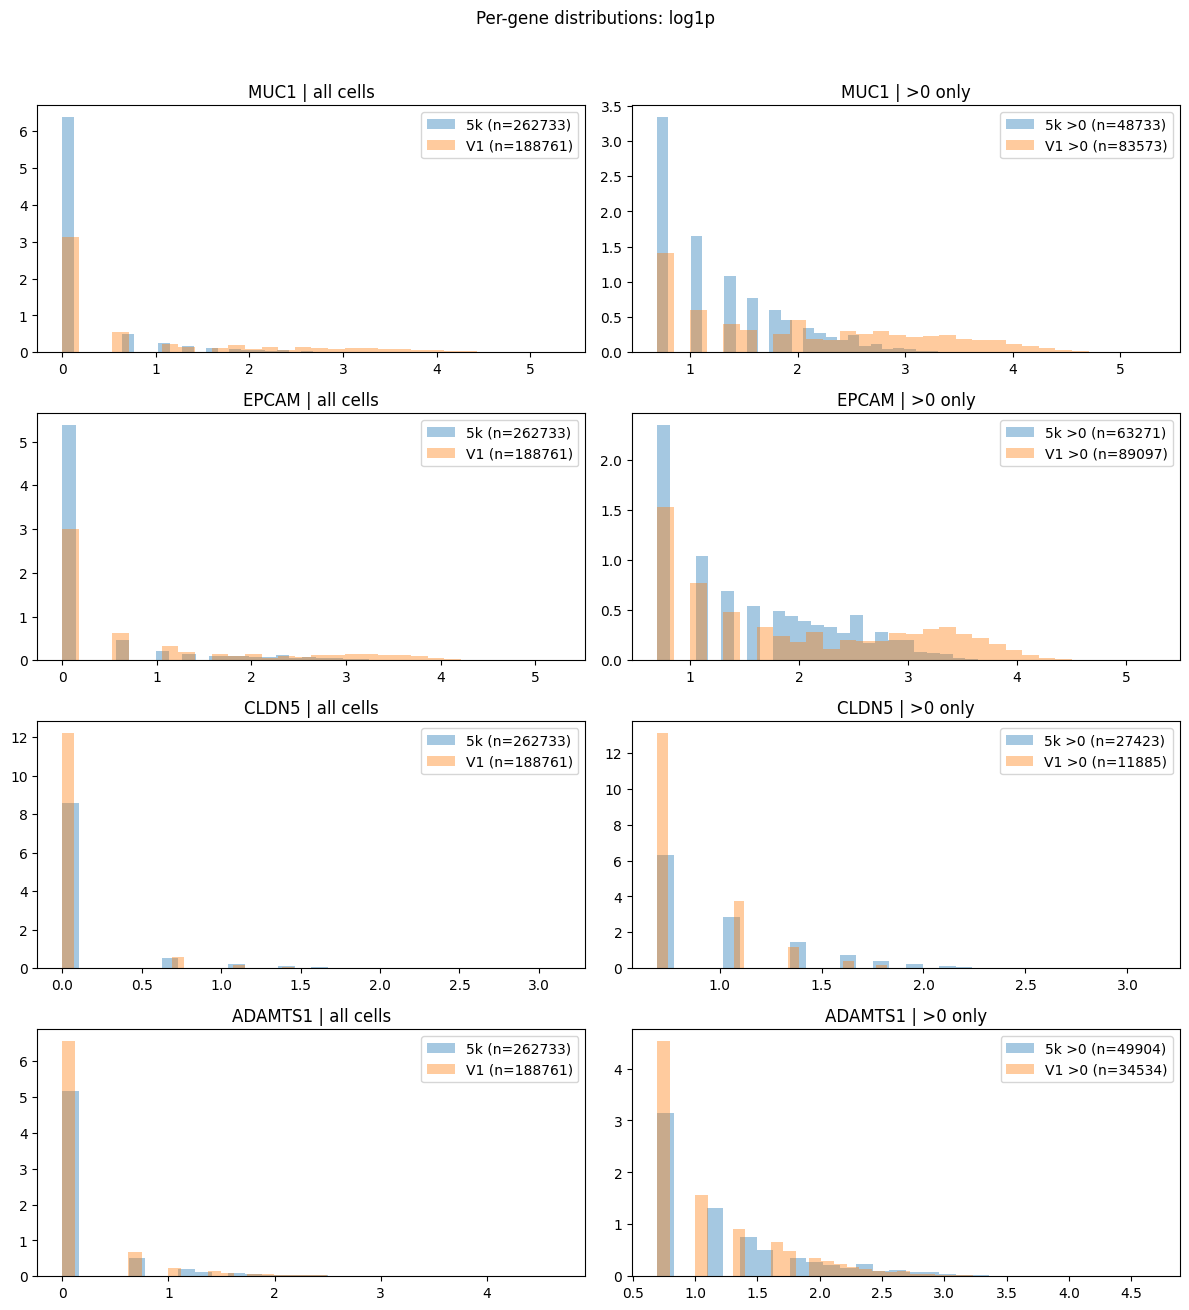

In [69]:
# This helps since we have a very sparse expression matrix, which converts it to an array
def _col_dense(X, j):
    if issparse(X):
        return X[:, j].toarray().ravel()
    return np.asarray(X)[:, j]

# Same thing but for rows
def _row_sums(X):
    if issparse(X):
        return np.ravel(X.sum(axis=1)).astype(float)
    return np.asarray(X).sum(axis=1).astype(float)

# This function will be used a lot 
def plot_gene_hist_grid(
    adata1, adata2,
    genes,
    target_sum=1e4,
    bins=30,
    seed=0,
    density=False,
    first_label="5k",
    second_label="V1",
):
    X1, X2 = adata1.X, adata2.X
    tot1, tot2 = _row_sums(X1), _row_sums(X2)

    n = len(genes)
    fig, axs = plt.subplots(n, 2, figsize=(12, 3.2 * n), squeeze=False)

    rng = np.random.default_rng(seed)
    summary_rows = []

    for i, gene in enumerate(genes):
        j1 = adata1.var_names.get_loc(gene)
        j2 = adata2.var_names.get_loc(gene)

        c1 = _col_dense(X1, j1)
        c2 = _col_dense(X2, j2)

        x1_all = np.log1p(c1)
        x2_all = np.log1p(c2)

        # >0 only
        x1_pos = x1_all[c1 > 0]
        x2_pos = x2_all[c2 > 0]

        summary_rows.append(
            {
                "gene": gene,
                "mean_first": float(np.mean(c1)),
                "mean_second": float(np.mean(c2)),
                "detect_pct_first": float(np.mean(c1 > 0) * 100),
                "detect_pct_second": float(np.mean(c2 > 0) * 100),
            }
        )

        # Left: all cells (zeros included)
        axL = axs[i, 0]
        axL.hist(x1_all, bins=bins, density=density, alpha=0.4, label=f"{first_label} (n={len(x1_all)})")
        axL.hist(x2_all, bins=bins, density=density, alpha=0.4, label=f"{second_label} (n={len(x2_all)})")
        axL.set_title(f"{gene} | all cells")
        axL.legend()

        # Right: positives only
        axR = axs[i, 1]
        axR.hist(x1_pos, bins=bins, density=density, alpha=0.4, label=f"{first_label} >0 (n={len(x1_pos)})")
        axR.hist(x2_pos, bins=bins, density=density, alpha=0.4, label=f"{second_label} >0 (n={len(x2_pos)})")
        axR.set_title(f"{gene} | >0 only")
        axR.legend()

    summary_df = pd.DataFrame(summary_rows)
    print("Per-gene summary (mean counts + detection %):")
    print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    fig.suptitle("Per-gene distributions: log1p", y=1.02)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_gene_hist_grid(
    adata_5k,
    adata_v1,
    genes_to_plot,
    bins=30,
    density=True,
    first_label="5k",
    second_label="V1",
)


### Downsampling (via binomial thinning, overlap only)
> Goal: transform the V1 counts so they are **5K-like** on the overlap genes, while only removing counts (never inventing new counts).

How `thin_v1_to_match_5k_binomial` works:
1. It assumes `adata_v1` and `adata_5k` have the same overlap genes in the same order and that `adata_v1.X` contains raw non-negative integer counts.
2. For each gene it computes a thinning probability:
   - `p_j = mean_5k(j) / mean_v1(j)`, clipped to `[0, 1]`.
3. Each non-zero count is thinned with a binomial draw:
   - `x'_{ij} ~ Binomial(x_{ij}, p_j)`.
4. **Optional extra detection drop** (`extra_detection_drop=True`): after thinning, if a gene's detection fraction still exceeds the 5K target, additional positive cells are dropped to match, either randomly (`drop_mode="random"`) or preferentially for low-count cells (`drop_mode="low_counts"`).
5. It rebuilds a sparse matrix and returns `adata_ds` (the downsampled AnnData) and the per-gene probabilities `p_gene`.

In [70]:
def thin_v1_to_match_5k_binomial(
    adata_v1,
    adata_5k,
    seed=42,
    extra_detection_drop=True,
    drop_mode="low_counts",   
):
    """
    Downsample (corrupt) V1 raw counts to look like 5K sensitivity loss on overlap genes.
    """

    # Auto-align to overlap genes when needed
    if not adata_v1.var_names.equals(adata_5k.var_names):
        overlap = adata_v1.var_names.intersection(adata_5k.var_names)
        if len(overlap) == 0:
            raise ValueError("No overlapping genes between the panels")
        adata_v1 = adata_v1[:, overlap].copy()
        adata_5k = adata_5k[:, overlap].copy()
        print(f"Auto-aligned to overlap genes: {len(overlap)}")

    rng = np.random.default_rng(seed)

    # Use a sparse CSC for efficient per-gene operations
    Xv = adata_v1.X
    Xv = Xv.tocsc() if sp.issparse(Xv) else sp.csc_matrix(Xv)

    n_cells, n_genes = Xv.shape

    # Count validity checks
    if Xv.data.size > 0:
        if np.any(Xv.data < 0):
            raise ValueError("adata_v1.X contains negative values")
        # If floats, require near-integers (common if matrix got cast)
        if np.issubdtype(Xv.data.dtype, np.floating):
            frac = np.abs(Xv.data - np.rint(Xv.data))
            if np.nanmax(frac) > 1e-6:
                raise ValueError(
                    "adata_v1.X looks non-integer (needs raw counts)"
                )

    #  Compute per-gene means from X directly (more reliable than var fields) 
    # mean = total / n_cells
    total_v1 = np.asarray(Xv.sum(axis=0)).ravel().astype(np.float64)
    mean_v1 = total_v1 / float(n_cells)

    X5 = adata_5k.X
    X5 = X5.tocsc() if sp.issparse(X5) else sp.csc_matrix(X5)
    total_5k = np.asarray(X5.sum(axis=0)).ravel().astype(np.float64)
    mean_5k = total_5k / float(adata_5k.n_obs)

    #  Detection targets from 5K: fraction of cells with > 0 
    det_tgt = np.asarray((X5 > 0).sum(axis=0)).ravel().astype(np.float64) / float(adata_5k.n_obs)
    k_tgt = np.rint(det_tgt * n_cells).astype(np.int64)

    #  Per-gene thinning probability 
    # If mean_v1 == 0 => p=0; if mean_5k > mean_v1 => p=1 (can't increase by thinning).
    with np.errstate(divide="ignore", invalid="ignore"):
        p_gene = np.where(mean_v1 > 0, mean_5k / mean_v1, 0.0)
    p_gene = np.clip(p_gene, 0.0, 1.0).astype(np.float64)

    # Binomial thinning on sparse CSC 
    new_data_chunks = []
    new_indices_chunks = []
    new_indptr = np.zeros(n_genes + 1, dtype=np.int64)
    nnz_so_far = 0

    indptr = Xv.indptr
    indices = Xv.indices
    data = np.rint(Xv.data).astype(np.int64, copy=False)  # safe after near-integer check

    for j in range(n_genes):
        start, end = indptr[j], indptr[j + 1]
        if start == end or p_gene[j] <= 0.0:
            new_indptr[j + 1] = nnz_so_far
            continue

        rows = indices[start:end]
        x = data[start:end]
        p = p_gene[j]

        # Binomial thinning
        if np.isscalar(p):
            x_new = rng.binomial(x, p).astype(np.int64, copy=False)
        else:
            x_new = rng.binomial(x, p).astype(np.int64, copy=False)

        keep = x_new > 0
        if not np.any(keep):
            new_indptr[j + 1] = nnz_so_far
            continue

        rows_k = rows[keep]
        x_k = x_new[keep]

        # If detection still higher than target, drop some positives
        if extra_detection_drop:
            nnz = rows_k.size
            tgt = int(k_tgt[j])
            if tgt < nnz:
                drop_n = nnz - tgt

                if drop_mode == "random":
                    drop_idx = rng.choice(nnz, size=drop_n, replace=False)
                elif drop_mode == "low_counts":
                    # Prefer dropping low counts (more realistic): probability ∝ 1/(count+eps)
                    w = 1.0 / (x_k.astype(np.float64) + 1e-9)
                    w = w / w.sum()
                    drop_idx = rng.choice(nnz, size=drop_n, replace=False, p=w)
                else:
                    raise ValueError("drop_mode must be 'random' or 'low_counts'.")

                mask2 = np.ones(nnz, dtype=bool)
                mask2[drop_idx] = False
                rows_k = rows_k[mask2]
                x_k = x_k[mask2]

        # Sort rows within column (CSC invariant)
        order = np.argsort(rows_k)
        rows_k = rows_k[order]
        x_k = x_k[order]

        new_indices_chunks.append(rows_k.astype(np.int32, copy=False))
        new_data_chunks.append(x_k.astype(np.int64, copy=False))

        nnz_so_far += rows_k.size
        new_indptr[j + 1] = nnz_so_far

    new_indices = np.concatenate(new_indices_chunks) if new_indices_chunks else np.array([], dtype=np.int32)
    new_data = np.concatenate(new_data_chunks) if new_data_chunks else np.array([], dtype=np.int64)

    X_new_csc = sp.csc_matrix((new_data, new_indices, new_indptr), shape=(n_cells, n_genes))
    X_new = X_new_csc.tocsr()

    adata_ds = adata_v1.copy()
    adata_ds.X = X_new
    sc.pp.calculate_qc_metrics(adata_ds, inplace=True, percent_top=None)

    return adata_ds, p_gene

Auto-aligned to overlap genes: 196
Per-gene summary (mean counts + detection %):
   gene  mean_first  mean_second  detect_pct_first  detect_pct_second
   MUC1      0.7094       0.6034           18.5485            18.5483
  EPCAM      1.4371       1.2483           24.0819            24.0818
  CLDN5      0.2131       0.0911           10.4376             6.2963
ADAMTS1      0.6847       0.5927           18.9942            18.2951


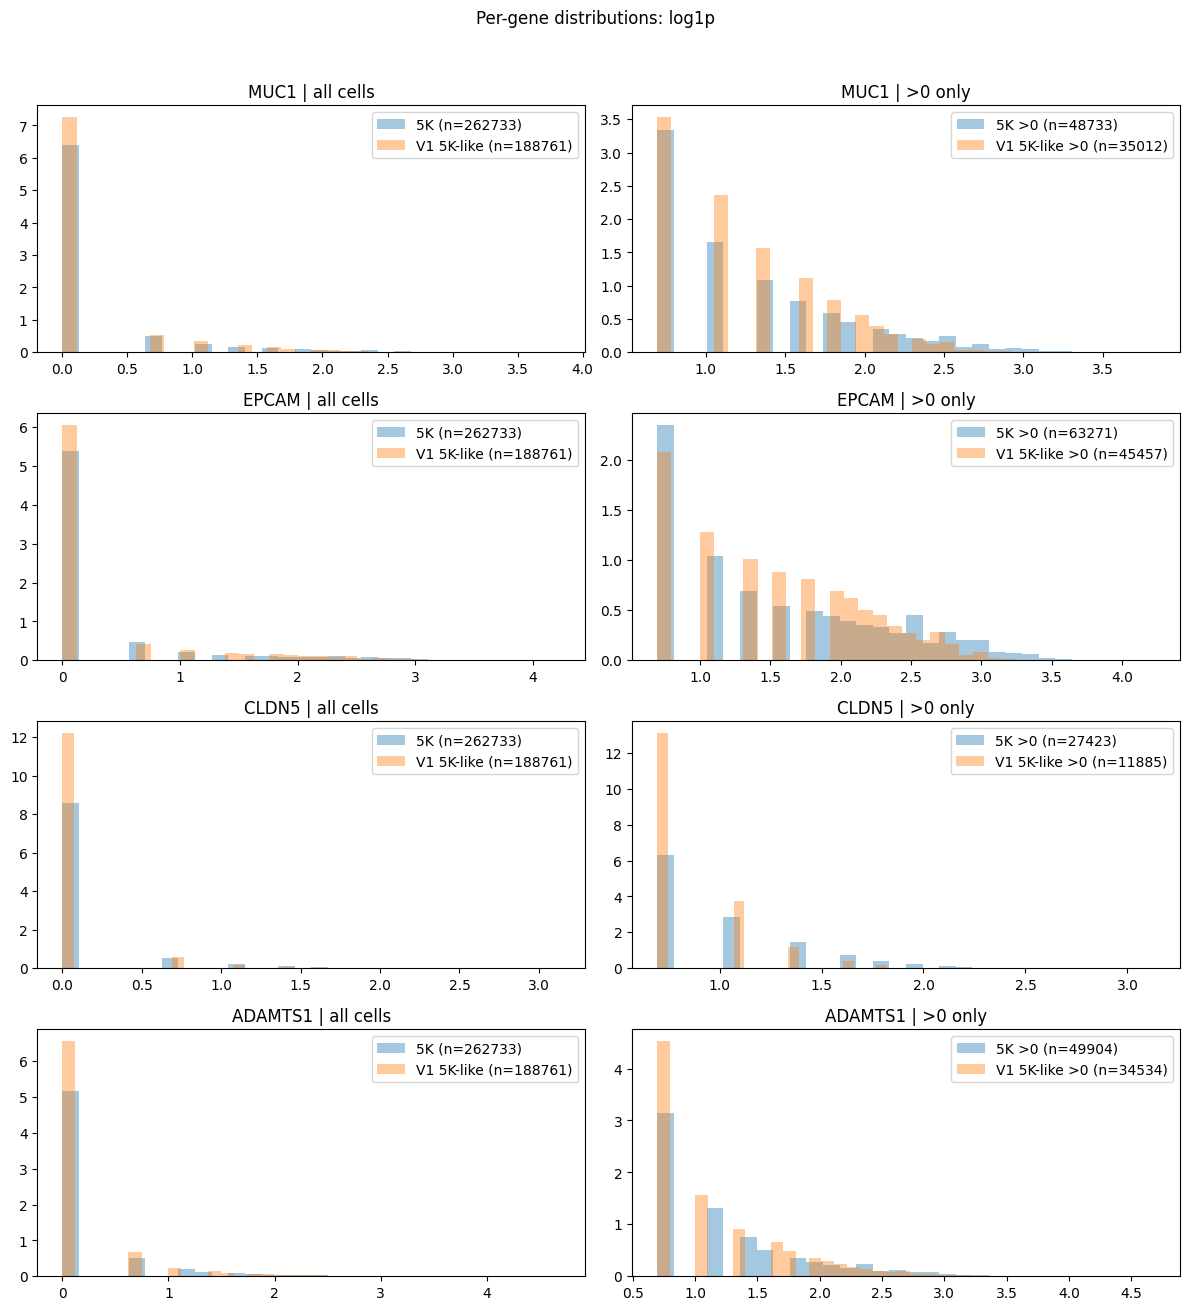

In [71]:
adata_v1_5k_like, p_gene = thin_v1_to_match_5k_binomial(
    adata_v1,
    adata_5k,
    seed=42,
    extra_detection_drop=True,
    drop_mode="low_counts",
)

# Compare original V1, 5K-like V1, and 5K on the same plots as before
plot_gene_hist_grid(
    adata_5k,
    adata_v1_5k_like,
    genes_to_plot,
    bins=30,
    density=True,
    first_label="5K",
    second_label="V1 5K-like",
)

### Downsample V1 with a fixed p 
The 5K panel is not needed for this anymore, but the value p was based on the analysis of both

In [72]:
# Use filtered cells, but keep all genes (not overlap-only)
adata_v1 = adata_v1_f.copy()
adata_5k = adata_5k_f.copy()

print("Using filtered cells with full gene sets:")
print(f"adata_v1 shape: {adata_v1.shape}")
print(f"adata_5k shape: {adata_5k.shape}")

Using filtered cells with full gene sets:
adata_v1 shape: (188761, 289)
adata_5k shape: (262733, 5001)


AnnData object with n_obs × n_vars = 188761 × 289
    obs: 'cell_id', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_289_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
Per-gene summary (mean counts + detection %):
   gene  mean_first  mean_second  detect_pct_first  detect_pct_second
   MUC1      0.7094       1.1586           18.5485            29.0478
  EPCAM      1.4371       1.1148           24.0819            29.7217
  CLDN5      0.2131       0.0173           10.4376             1.5999
ADAMTS1      0.6847       0.1129           18.9942             7.3585

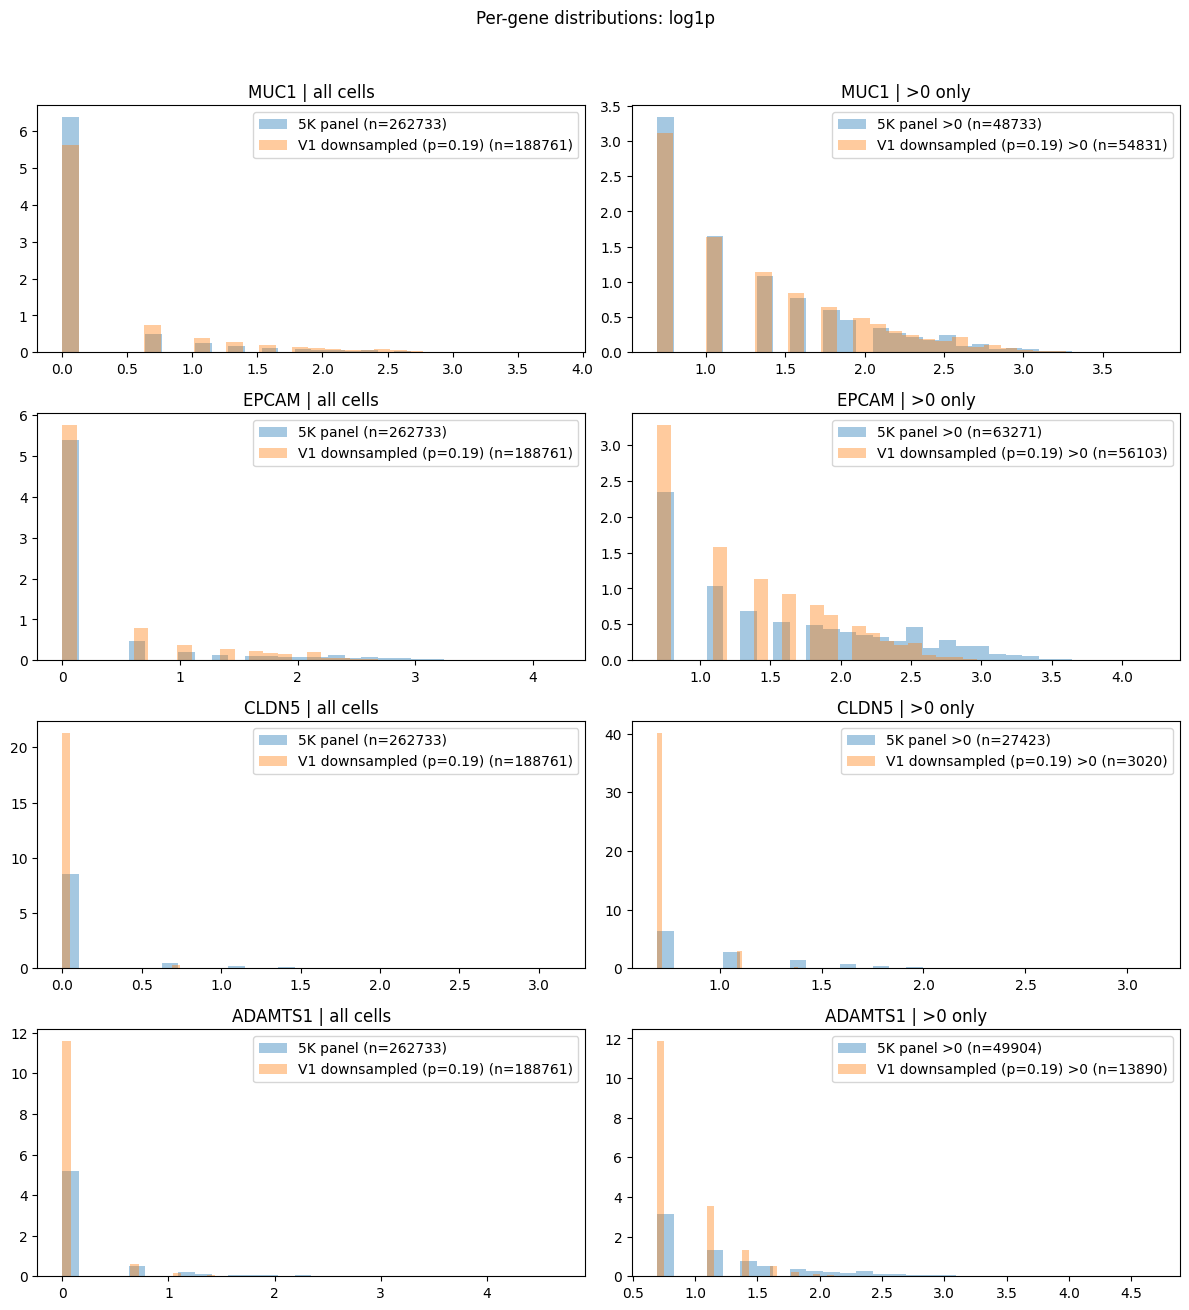

In [73]:
def downsample_v1_fixed_p_binomial(
    adata_v1,
    p=0.19,
    seed=42,
):
    """
    Downsample V1 counts with a fixed binomial probability.
    """
    p = float(p)
    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    Xv = adata_v1.X
    Xv = Xv.tocsr() if sp.issparse(Xv) else sp.csr_matrix(Xv)

    # Some sanity checks (postive & integer values)
    if Xv.data.size > 0:
        if np.any(Xv.data < 0):
            raise ValueError("adata_v1.X contains negative values")
        if np.issubdtype(Xv.data.dtype, np.floating):
            frac = np.abs(Xv.data - np.rint(Xv.data))
            if np.nanmax(frac) > 1e-6:
                raise ValueError("adata_v1.X looks non-integer (needs raw counts)")

    data_int = np.rint(Xv.data).astype(np.int64, copy=False)
    data_new = rng.binomial(data_int, p).astype(np.int64, copy=False)

    # Keep CSR structure consistent, then drop explicit zeros.
    X_new = sp.csr_matrix(
        (data_new, Xv.indices.copy(), Xv.indptr.copy()),
        shape=Xv.shape,
    )
    X_new.eliminate_zeros()

    adata_v1_ds = adata_v1.copy()
    adata_v1_ds.X = X_new
    sc.pp.calculate_qc_metrics(adata_v1_ds, inplace=True, percent_top=None)

    return adata_v1_ds


# Example usage
adata_v1_p19 = downsample_v1_fixed_p_binomial(
    adata_v1,
    p=0.19,
    seed=0,
)
print(adata_v1_p19)

plot_gene_hist_grid(
    adata_5k,
    adata_v1_p19,
    genes_to_plot,
    bins=30,
    density=True,
    first_label="5K panel",
    second_label="V1 downsampled (p=0.19)",
)


### Mixed downsampling: `downsample_v1_mixed_overlap_p`

This function applies two downsampling rules to the V1 matrix:

1. **Overlap genes (in both V1 and 5K):**
   - Uses a gene-specific probability
   - $p_j = \mathrm{clip}\left(\frac{\mu_{5K,j}}{\mu_{V1,j}}, 0, 1\right)$

2. **V1-only (non-overlap) genes:**
   - Uses a fixed probability `p_non_overlap` (default `0.19`)

For each nonzero count, thinning is binomial:
- $x'_{ij} \sim \mathrm{Binomial}(x_{ij}, p_j)$ for overlap genes
- $x'_{ij} \sim \mathrm{Binomial}(x_{ij}, p_{non\_overlap})$ for non-overlap genes


Overlap genes: 196
Non-overlap genes (fixed p=0.19): 93
Overlap median mean ratio (after/before): 0.19598126202129665
Overlap median detection ratio (after/before): 0.32195597760365413
Non-overlap median mean ratio (after/before): 0.19011852121373948
Non-overlap median detection ratio (after/before): 0.31845078000654253
Per-gene summary (mean counts + detection %):
   gene  mean_first  mean_second  detect_pct_first  detect_pct_second
   MUC1      6.0952       0.7067           44.2745            24.3138
  EPCAM      5.8802       1.4387           47.2010            32.3224
  CLDN5      0.0911       0.0911            6.2963             6.2963
ADAMTS1      0.5927       0.5927           18.2951            18.2951


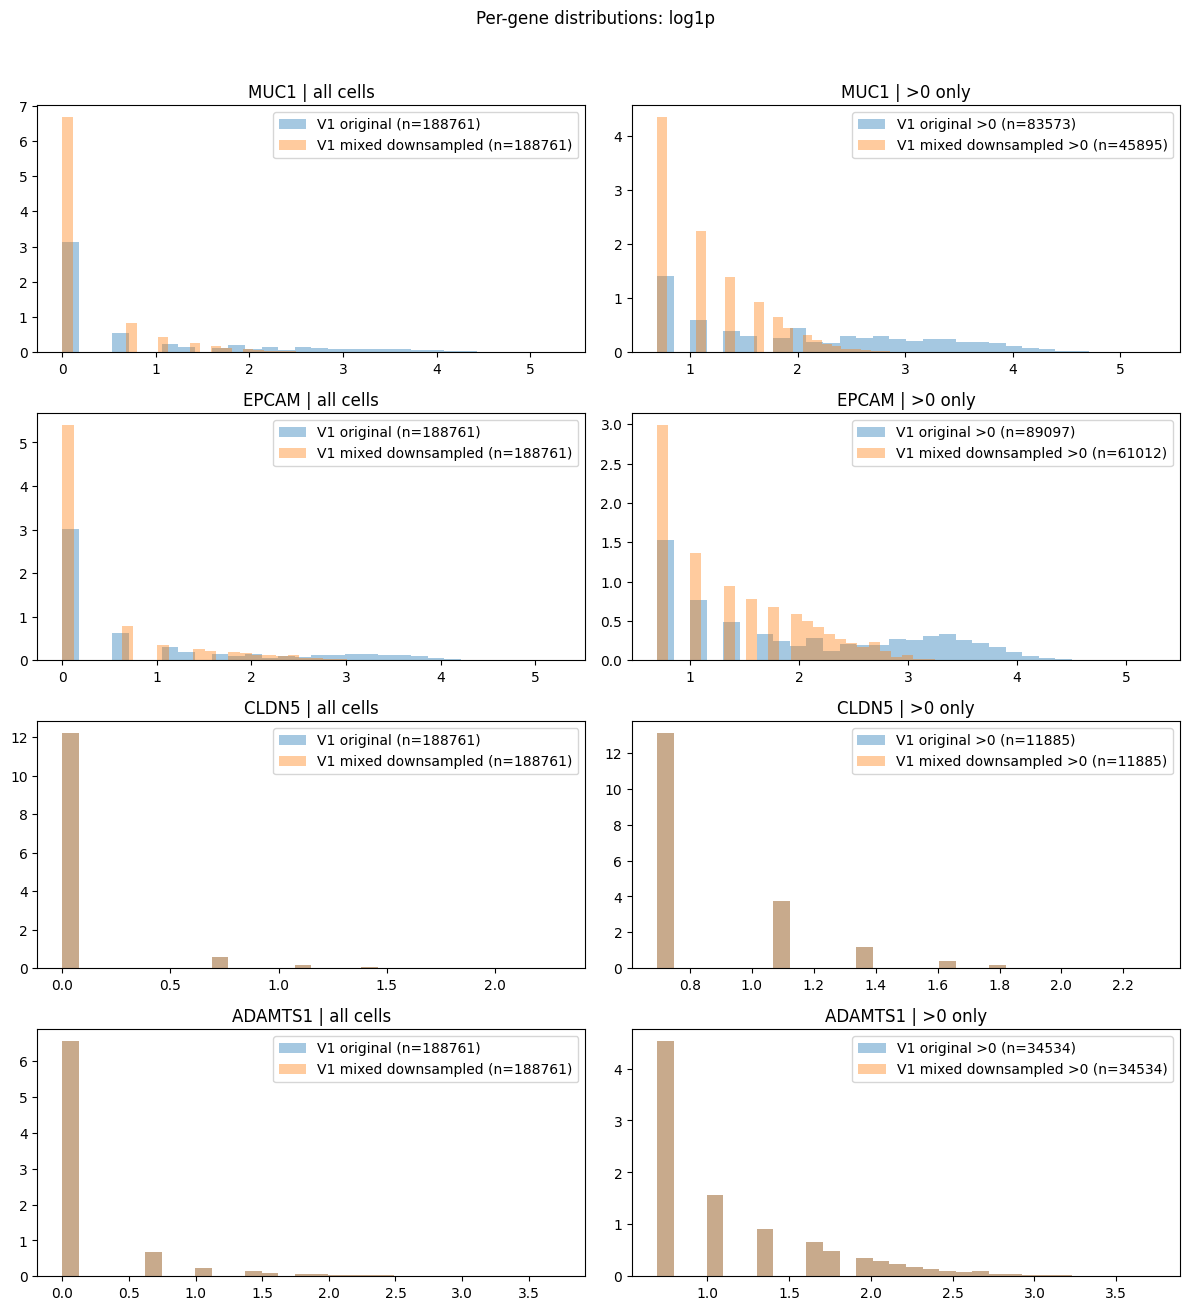

In [76]:
def downsample_v1_mixed_overlap_p(
    adata_v1,
    adata_5k,
    p_non_overlap=0.19,
    seed=42,
):
    """
    Mixed downsampling for V1:
    - Overlap genes: p_j = mean_5k / mean_v1 (clipped to [0, 1])
    - Non-overlap genes: fixed p = p_non_overlap
    """
    p_non_overlap = float(p_non_overlap)
    if not (0.0 <= p_non_overlap <= 1.0):
        raise ValueError("p_non_overlap must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    # Use sparse CSR for efficient per-entry thinning
    Xv = adata_v1.X
    Xv = Xv.tocsr() if sp.issparse(Xv) else sp.csr_matrix(Xv)

    if Xv.data.size > 0:
        if np.any(Xv.data < 0):
            raise ValueError("adata_v1.X contains negative values; expected raw counts.")
        if np.issubdtype(Xv.data.dtype, np.floating):
            frac = np.abs(Xv.data - np.rint(Xv.data))
            if np.nanmax(frac) > 1e-6:
                raise ValueError("adata_v1.X looks non-integer. Use raw counts (not normalized/log1p).")

    # Per-gene means/detection before downsampling
    n_cells_v1 = adata_v1.n_obs
    mean_before = np.asarray(Xv.sum(axis=0)).ravel().astype(np.float64) / float(n_cells_v1)
    det_before = np.asarray((Xv > 0).sum(axis=0)).ravel().astype(np.float64) / float(n_cells_v1)

    # Build p_gene: default fixed p for all genes
    p_gene = np.full(adata_v1.n_vars, p_non_overlap, dtype=np.float64)

    # Compute p_j only for overlap genes
    overlap_genes = sorted(set(adata_v1.var_names).intersection(set(adata_5k.var_names)))
    if len(overlap_genes) > 0:
        overlap_idx_v1 = adata_v1.var_names.get_indexer(overlap_genes)

        X5 = adata_5k[:, overlap_genes].X
        X5 = X5.tocsr() if sp.issparse(X5) else sp.csr_matrix(X5)
        mean_5k_overlap = np.asarray(X5.sum(axis=0)).ravel().astype(np.float64) / float(adata_5k.n_obs)

        mean_v1_overlap = mean_before[overlap_idx_v1]
        with np.errstate(divide="ignore", invalid="ignore"):
            p_overlap = np.where(mean_v1_overlap > 0, mean_5k_overlap / mean_v1_overlap, 0.0)
        p_overlap = np.clip(p_overlap, 0.0, 1.0)

        p_gene[overlap_idx_v1] = p_overlap

    # Thin each non-zero entry using its gene-specific probability
    data_int = np.rint(Xv.data).astype(np.int64, copy=False)
    p_entry = p_gene[Xv.indices]
    data_new = rng.binomial(data_int, p_entry).astype(np.int64, copy=False)

    X_new = sp.csr_matrix(
        (data_new, Xv.indices.copy(), Xv.indptr.copy()),
        shape=Xv.shape,
    )
    X_new.eliminate_zeros()

    # Per-gene means/detection after downsampling
    mean_after = np.asarray(X_new.sum(axis=0)).ravel().astype(np.float64) / float(n_cells_v1)
    det_after = np.asarray((X_new > 0).sum(axis=0)).ravel().astype(np.float64) / float(n_cells_v1)

    adata_v1_ds = adata_v1.copy()
    adata_v1_ds.X = X_new
    sc.pp.calculate_qc_metrics(adata_v1_ds, inplace=True, percent_top=None)

    overlap_mask = np.isin(adata_v1.var_names.astype(str), np.array(overlap_genes, dtype=str))
    non_overlap_mask = ~overlap_mask

    print(f"Overlap genes: {int(overlap_mask.sum())}")
    print(f"Non-overlap genes (fixed p={p_non_overlap}): {int(non_overlap_mask.sum())}")

    if overlap_mask.any():
        ratio_mean_overlap = np.median((mean_after[overlap_mask] + 1e-12) / (mean_before[overlap_mask] + 1e-12))
        ratio_det_overlap = np.median((det_after[overlap_mask] + 1e-12) / (det_before[overlap_mask] + 1e-12))
        print("Overlap median mean ratio (after/before):", ratio_mean_overlap)
        print("Overlap median detection ratio (after/before):", ratio_det_overlap)

    if non_overlap_mask.any():
        ratio_mean_non = np.median((mean_after[non_overlap_mask] + 1e-12) / (mean_before[non_overlap_mask] + 1e-12))
        ratio_det_non = np.median((det_after[non_overlap_mask] + 1e-12) / (det_before[non_overlap_mask] + 1e-12))
        print("Non-overlap median mean ratio (after/before):", ratio_mean_non)
        print("Non-overlap median detection ratio (after/before):", ratio_det_non)

    return adata_v1_ds, p_gene, overlap_genes


# Example usage
adata_v1_mixed, p_gene_mixed, overlap_genes_mixed = downsample_v1_mixed_overlap_p(
    adata_v1,
    adata_5k,
    p_non_overlap=0.19,
    seed=42,
)

# Compare original V1 vs mixed-downsampled V1 for selected genes
if len(plot_genes) > 0:
    plot_gene_hist_grid(
        adata_v1,
        adata_v1_mixed,
        plot_genes,
        bins=30,
        density=True,
        first_label="V1 original",
        second_label="V1 mixed downsampled",
    )
else:
    print("No genes from plot_genes are present in current adata_v1.")

Per-gene summary (mean counts + detection %):
   gene  mean_first  mean_second  detect_pct_first  detect_pct_second
   MUC1      6.0952       0.5565           44.2745            22.1195
  EPCAM      5.8802       1.1016           47.2010            29.5273
  CLDN5      0.0911       0.0852            6.2963             6.0007
ADAMTS1      0.5927       0.4573           18.2951            16.2173


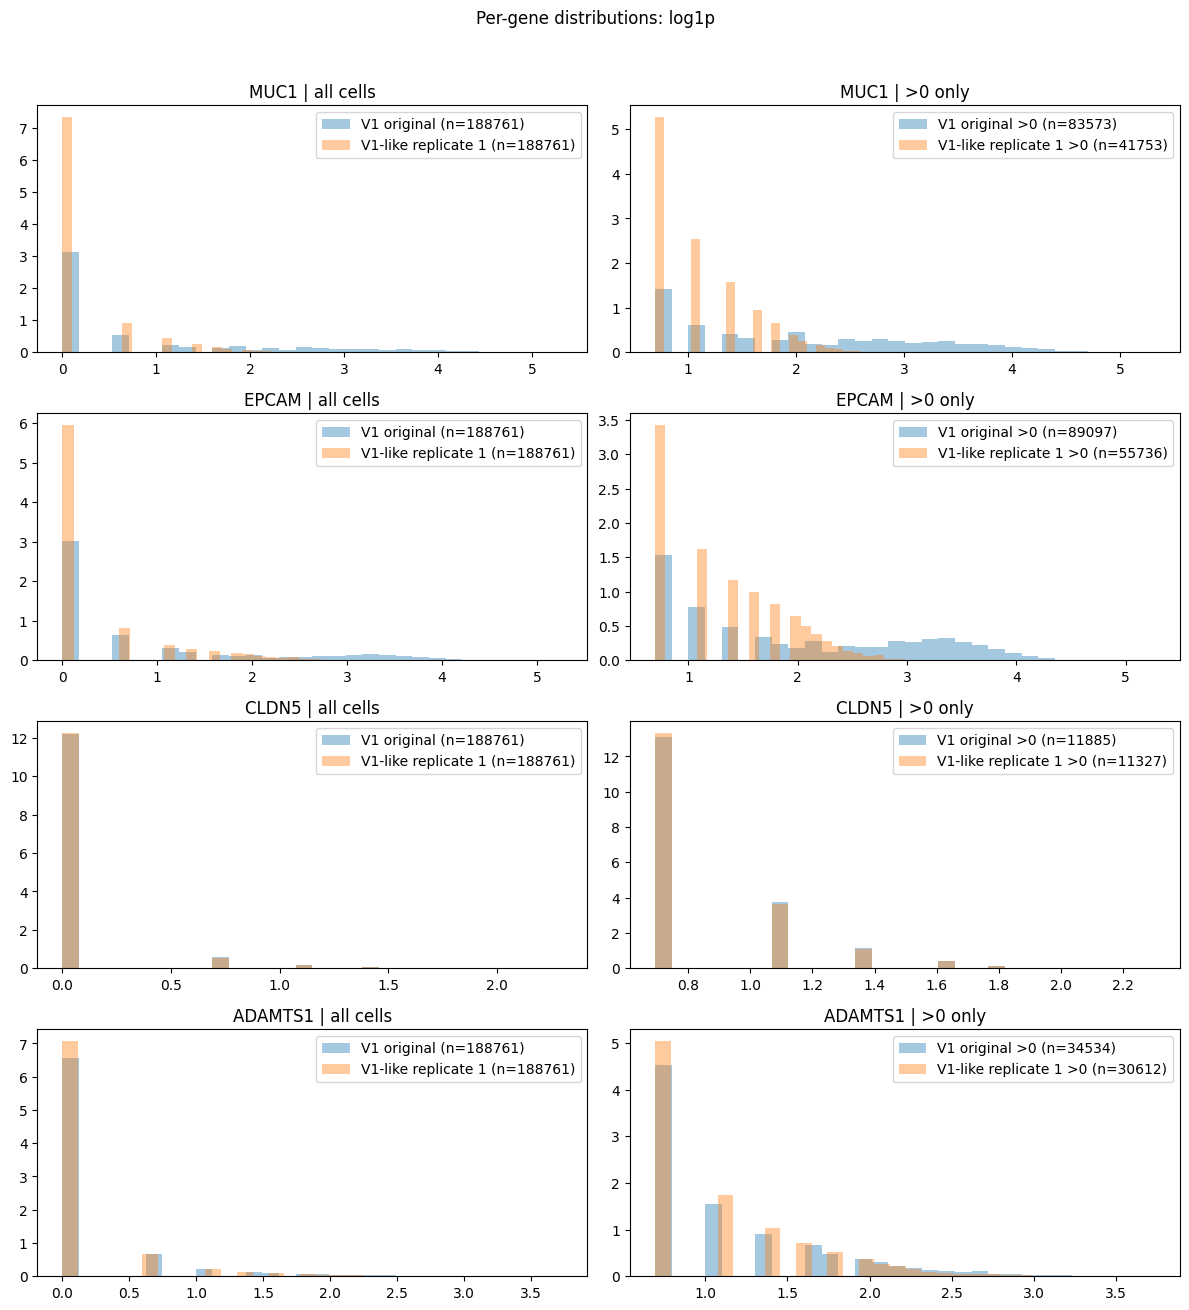

Per-gene summary (mean counts + detection %):
   gene  mean_first  mean_second  detect_pct_first  detect_pct_second
   MUC1      6.0952       0.8277           44.2745            25.9047
  EPCAM      5.8802       1.4508           47.2010            32.3790
  CLDN5      0.0911       0.0724            6.2963             5.3109
ADAMTS1      0.5927       0.5927           18.2951            18.2951


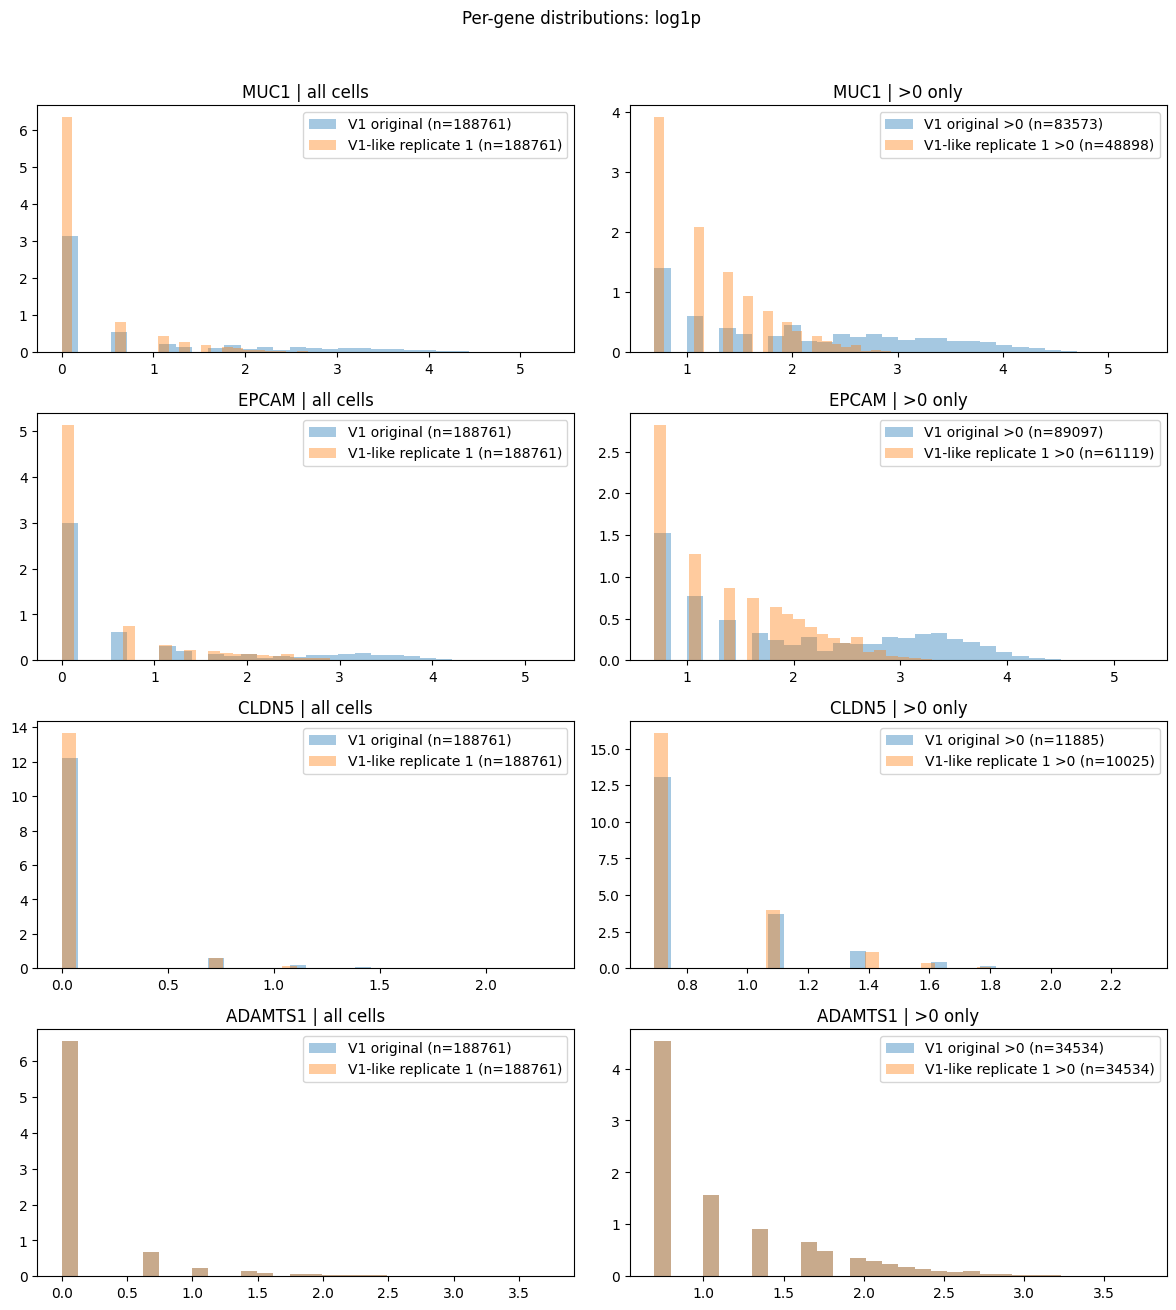

In [78]:
# Multiple 5K-like corruptions from one V1 by adding noise to thinning probabilities

def make_multiple_v1_like_corruptions(
    adata_v1,
    adata_5k,
    n_versions=2,
    p_non_overlap=0.19,
    prob_noise_sigma=0.2,
    base_seed=0,
):
    """
    Create multiple corrupted V1 versions that are "5K-like" by perturbing thinning probabilities:
    1) Build base probabilities:
       - overlap genes: p_j = clip(mean_5k / mean_v1, 0, 1)
       - non-overlap genes: p_non_overlap
    2) For each replicate r, perturb probabilities with multiplicative lognormal noise:
       p_j^(r) = clip(p_j * exp(eps_j), 0, 1), eps_j ~ N(0, prob_noise_sigma^2)
    3) Binomial thinning per nonzero entry using replicate-specific p_j^(r).
    """
    # First a few quality cehcks
    n_versions = int(n_versions)
    if n_versions < 1:
        raise ValueError("n_versions must be >= 1")

    p_non_overlap = float(p_non_overlap)
    if not (0.0 <= p_non_overlap <= 1.0):
        raise ValueError("p_non_overlap must be between 0 and 1.")

    prob_noise_sigma = float(prob_noise_sigma)
    if prob_noise_sigma < 0:
        raise ValueError("prob_noise_sigma must be >= 0.")

    Xv = adata_v1.X
    Xv = Xv.tocsr() if sp.issparse(Xv) else sp.csr_matrix(Xv)

    # Check again if counts ir positive and non-integer
    if Xv.data.size > 0:
        if np.any(Xv.data < 0):
            raise ValueError("adata_v1.X contains negative values (expected raw counts).")
        if np.issubdtype(Xv.data.dtype, np.floating):
            frac = np.abs(Xv.data - np.rint(Xv.data))
            if np.nanmax(frac) > 1e-6:
                raise ValueError("adata_v1.X looks non-integer (use raw counts)")

    n_cells_v1 = adata_v1.n_obs
    mean_v1 = np.asarray(Xv.sum(axis=0)).ravel().astype(np.float64) / float(n_cells_v1)

    # Base probabilities: fixed p for all genes first
    p_base = np.full(adata_v1.n_vars, p_non_overlap, dtype=np.float64)

    # Replace overlap genes with mean_5k / mean_v1
    overlap_genes = sorted(set(adata_v1.var_names).intersection(set(adata_5k.var_names)))
    if len(overlap_genes) > 0:
        idx_overlap = adata_v1.var_names.get_indexer(overlap_genes)
        X5_overlap = adata_5k[:, overlap_genes].X
        X5_overlap = X5_overlap.tocsr() if sp.issparse(X5_overlap) else sp.csr_matrix(X5_overlap)
        mean_5k_overlap = np.asarray(X5_overlap.sum(axis=0)).ravel().astype(np.float64) / float(adata_5k.n_obs)

        mean_v1_overlap = mean_v1[idx_overlap]
        with np.errstate(divide="ignore", invalid="ignore"):
            p_overlap = np.where(mean_v1_overlap > 0, mean_5k_overlap / mean_v1_overlap, 0.0)
        p_base[idx_overlap] = np.clip(p_overlap, 0.0, 1.0)

    data_int = np.rint(Xv.data).astype(np.int64, copy=False)

    adata_versions = []
    p_versions = []

    for rep in range(n_versions):
        rng = np.random.default_rng(base_seed + rep)

        if prob_noise_sigma > 0:
            eps = rng.normal(loc=0.0, scale=prob_noise_sigma, size=adata_v1.n_vars)
            p_rep = np.clip(p_base * np.exp(eps), 0.0, 1.0)
        else:
            p_rep = p_base.copy()

        p_entry = p_rep[Xv.indices]
        data_new = rng.binomial(data_int, p_entry).astype(np.int64, copy=False)

        X_new = sp.csr_matrix(
            (data_new, Xv.indices.copy(), Xv.indptr.copy()),
            shape=Xv.shape,
        )
        X_new.eliminate_zeros()

        adata_rep = adata_v1.copy()
        adata_rep.X = X_new
        sc.pp.calculate_qc_metrics(adata_rep, inplace=True, percent_top=None)

        adata_versions.append(adata_rep)
        p_versions.append(p_rep)

    return adata_versions, p_versions, p_base, overlap_genes


adata_v1_like_list, p_list, p_base, overlap_genes = make_multiple_v1_like_corruptions(
    adata_v1=adata_v1,
    adata_5k=adata_5k,
    n_versions=3,
    p_non_overlap=0.19,
    prob_noise_sigma=0.2,
    base_seed=42,
)


# Example: compare original vs first corrupted version for selected genes
if len(plot_genes) > 0:
    plot_gene_hist_grid(
        adata_v1,
        adata_v1_like_list[0],
        plot_genes,
        bins=30,
        density=True,
        first_label="V1 original",
        second_label="V1-like replicate 1",
    )
    plot_gene_hist_grid(
        adata_v1,
        adata_v1_like_list[1],
        plot_genes,
        bins=30,
        density=True,
        first_label="V1 original",
        second_label="V1-like replicate 1",
    )
else:
    print("No genes from plot_genes are present in current adata_v1.")

# Variational AutoEncoder 

## Helper functions & Classes for VAE

In [19]:
# Basic conditional-style VAE reconstruction (GPU-optimized)

def _to_dense_float32(X):
    if sp.issparse(X):
        return X.toarray().astype(np.float32)
    return np.asarray(X, dtype=np.float32)


def _random_split_indices(n_cells, train_frac=0.7, val_frac=0.15, seed=42):
    if train_frac <= 0 or val_frac <= 0 or (train_frac + val_frac) >= 1:
        raise ValueError("Use train_frac > 0, val_frac > 0, and train_frac + val_frac < 1.")
    rng = np.random.default_rng(seed)
    idx = np.arange(n_cells)
    rng.shuffle(idx)
    n_train = int(train_frac * n_cells)
    n_val = int(val_frac * n_cells)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return train_idx, val_idx, test_idx


def _group_split_indices(group_labels, train_frac=0.7, val_frac=0.15, seed=42):
    group_labels = np.asarray(group_labels).astype(str)
    n_cells = group_labels.size
    uniq_groups = pd.Index(group_labels).unique().to_numpy()

    rng = np.random.default_rng(seed)
    rng.shuffle(uniq_groups)

    target_train = train_frac * n_cells
    target_val = val_frac * n_cells
    counts = {"train": 0, "val": 0, "test": 0}
    assignment = {}

    for g in uniq_groups:
        g_size = int(np.sum(group_labels == g))
        train_deficit = target_train - counts["train"]
        val_deficit = target_val - counts["val"]

        if train_deficit >= val_deficit and train_deficit > 0:
            split_name = "train"
        elif val_deficit > 0:
            split_name = "val"
        else:
            split_name = "test"

        assignment[g] = split_name
        counts[split_name] += g_size

    split_per_cell = np.array([assignment[g] for g in group_labels], dtype=object)
    train_idx = np.where(split_per_cell == "train")[0]
    val_idx = np.where(split_per_cell == "val")[0]
    test_idx = np.where(split_per_cell == "test")[0]

    if min(train_idx.size, val_idx.size, test_idx.size) == 0:
        return _random_split_indices(n_cells, train_frac=train_frac, val_frac=val_frac, seed=seed), None

    return (train_idx, val_idx, test_idx), assignment


def _infer_group_labels(obs_df):
    candidate_cols = [
        "section", "sample", "sample_id", "library_id", "slide", "region",
        "fov", "batch", "donor", "replicate", "tissue", "run_id"
    ]
    n_cells = obs_df.shape[0]
    for col in candidate_cols:
        if col in obs_df.columns:
            s = obs_df[col].astype(str).fillna("NA")
            n_unique = s.nunique()
            if 3 <= n_unique <= max(20, int(0.7 * n_cells)):
                return s.to_numpy(), f"obs['{col}']"

    x_candidates = ["x_centroid", "center_x", "x", "global_x", "spatial_x"]
    y_candidates = ["y_centroid", "center_y", "y", "global_y", "spatial_y"]

    x_col = next((c for c in x_candidates if c in obs_df.columns), None)
    y_col = next((c for c in y_candidates if c in obs_df.columns), None)
    if x_col is not None and y_col is not None:
        x_vals = pd.to_numeric(obs_df[x_col], errors="coerce")
        y_vals = pd.to_numeric(obs_df[y_col], errors="coerce")
        valid = x_vals.notna() & y_vals.notna()
        if valid.sum() >= max(100, int(0.5 * n_cells)):
            n_bins = 4
            x_bins = pd.qcut(x_vals[valid], q=n_bins, duplicates="drop")
            y_bins = pd.qcut(y_vals[valid], q=n_bins, duplicates="drop")
            labels_valid = x_bins.astype(str) + "|" + y_bins.astype(str)
            labels = np.array(["missing"] * n_cells, dtype=object)
            labels[np.where(valid.to_numpy())[0]] = labels_valid.to_numpy()
            if pd.Index(labels).nunique() >= 3:
                return labels, f"spatial blocks from {x_col}/{y_col}"

    return None, "random cells"


class MultiVersionTrainDataset(Dataset):
    def __init__(self, x_versions_masked, y_target, train_idx):
        self.x_versions = x_versions_masked
        self.y_target = y_target
        self.train_idx = np.asarray(train_idx, dtype=np.int64)
        self.n_versions = len(self.x_versions)
        self.n_train = self.train_idx.size

    def __len__(self):
        return self.n_versions * self.n_train

    def __getitem__(self, idx):
        version_idx = idx // self.n_train
        within_idx = idx % self.n_train
        cell_idx = self.train_idx[within_idx]
        x = torch.from_numpy(self.x_versions[version_idx][cell_idx])
        y = torch.from_numpy(self.y_target[cell_idx])
        return x, y



# VAE with ZINB-loss

### Creating the data

In [81]:
# First we need to create the dataset it will train on 
adata_v1_train_list, p_list, p_base, overlap_genes = make_multiple_v1_like_corruptions(
    adata_v1=adata_v1,
    adata_5k=adata_5k,
    n_versions=3,
    p_non_overlap=0.19,
    prob_noise_sigma=0.2,
    base_seed=42,
)

### Preparation for training
This includes:
- Setting the hyperparameters
- Checking the training data
- Creating the train / val / test set 
- Setting up the data loaders

In [83]:
# Tunable hyperparameters 
train_frac = 0.7
val_frac = 0.15
split_seed = 42
epochs = 40
beta = 1e-3
latent_dim = 16
hidden_dim = 256
learning_rate = 1e-3
early_stop_patience = 5
theta_init = 10.0
pi_init = 0.1
batch_size_cuda = 512
batch_size_cpu = 256


# Here we just do some device setup & let it run on the  CPU
torch.set_float32_matmul_precision("high")
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
if use_cuda:
    torch.backends.cudnn.benchmark = True
print(f"Running on device: {device}")

# We can have multiple input versions, but the same target (V1)
input_versions = [ad for ad in adata_v1_train_list if ad is not None]
if len(input_versions) == 0:
    raise ValueError("`adata_v1_train_list` contains no valid AnnData objects.")
input_name = f"adata_v1_train_list ({len(input_versions)} versions)"

# Establish the clean target, also check if we have the same number of cells
adata_target_base = adata_v1
for i, ad_in in enumerate(input_versions):
    if ad_in.n_obs != adata_target_base.n_obs:
        raise ValueError(f"Input version {i} has n_obs={ad_in.n_obs}, expected {adata_target_base.n_obs}.")

# Also check if we have some shared genes
common_genes = adata_target_base.var_names.copy()
for ad_in in input_versions:
    common_genes = common_genes.intersection(ad_in.var_names)
if len(common_genes) == 0:
    raise ValueError("No shared genes across selected input versions and adata_v1 target.")

# Raw-count training space on shared genes
adata_target = adata_target_base[:, common_genes].copy()
adata_input_versions = [ad[:, common_genes].copy() for ad in input_versions]

X_tgt = _to_dense_float32(adata_target.X)
X_tgt = np.clip(X_tgt, 0.0, None)
X_inputs = [np.clip(_to_dense_float32(ad.X), 0.0, None) for ad in adata_input_versions]

# Get the shape, well need this for the model and to report how many genes/cells we have.
n_cells, n_genes = X_tgt.shape
gene_names = adata_target.var_names.astype(str).to_numpy()
print(f"Using input source: {input_name}")
print(f"Cells: {n_cells}, Genes: {n_genes}")
print("Training data mode: raw counts")

# A copy for the model to use
X_inputs_model = [x_in.copy() for x_in in X_inputs]

# We use the helper functions to split the groups
group_labels, split_basis = _infer_group_labels(adata_target.obs)
if group_labels is not None:
    split_result, group_assignment = _group_split_indices(
        group_labels, train_frac=train_frac, val_frac=val_frac, seed=split_seed
    )
    if group_assignment is None:
        train_idx, val_idx, test_idx = split_result
        split_mode = "random fallback (group split had empty subset)"
    else:
        train_idx, val_idx, test_idx = split_result
        split_mode = f"grouped split by {split_basis}"
else:
    train_idx, val_idx, test_idx = _random_split_indices(
        n_cells, train_frac=train_frac, val_frac=val_frac, seed=split_seed
    )
    split_mode = "random cell split"

print(f"Split mode: {split_mode}")
print(f"train/val/test cells: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")

X_val = X_inputs_model[0][val_idx]
Y_val = X_tgt[val_idx]
X_test = X_inputs_model[0][test_idx]
Y_test = X_tgt[test_idx]

print(f"Training examples: {len(train_idx) * len(X_inputs_model)}")
print(f"Validation examples: {X_val.shape[0]} | Test examples: {X_test.shape[0]}")

train_dataset = MultiVersionTrainDataset(X_inputs_model, X_tgt, train_idx)
x_val = torch.from_numpy(X_val)
y_val = torch.from_numpy(Y_val)
x_test = torch.from_numpy(X_test)
y_test = torch.from_numpy(Y_test)

batch_size = batch_size_cuda if use_cuda else batch_size_cpu
loader_kwargs = {
    "num_workers": 0,
    "pin_memory": use_cuda,
}
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    **loader_kwargs,
 )
val_loader = DataLoader(
    TensorDataset(x_val, y_val),
    batch_size=batch_size,
    shuffle=False,
    **loader_kwargs,
 )
test_loader = DataLoader(
    TensorDataset(x_test, y_test),
    batch_size=batch_size,
    shuffle=False,
    **loader_kwargs,
 )

Running on device: cuda
Using input source: adata_v1_train_list (3 versions)
Cells: 188761, Genes: 289
Training data mode: raw counts
Split mode: random cell split
train/val/test cells: 132132 / 28314 / 28315
Training examples: 396396
Validation examples: 28314 | Test examples: 28315


### VAE architecture and ZINB loss (plain-language overview)

This model is a variational autoencoder designed for sparse count data.

How the architecture works:
- The encoder takes a cell-by-gene count vector and maps it through two hidden layers.
- It predicts two latent outputs: `mu` and `logvar`.
- A latent vector `z` is sampled with the reparameterization trick, so gradients can still flow through sampling.
- The decoder maps `z` back to gene space and outputs logits for reconstructed gene counts.

How the reconstruction part is modeled:
- Decoder logits are passed through `softplus` to get a positive mean parameter for counts.
- Each gene also has learned global parameters:
  - `theta` (NB dispersion)
  - `pi` (zero-inflation probability)

Loss terms used during training:
- Reconstruction loss: negative log-likelihood under the ZINB model (or NB if zero inflation is disabled).
- KL term: regularizes the latent space toward a unit Gaussian.
- Total objective: `recon_loss + beta * KL`.


In [ ]:
class VAE(nn.Module):
    # Set up the encoder and decoder layers once
    def __init__(self, input_dim, latent_dim=16, hidden_dim=256):
        super().__init__()
        self.enc_fc1 = nn.Linear(input_dim, hidden_dim)
        self.enc_fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.dec_fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, input_dim)

    # Pass through two encoder layers to get mu/logvar
    def encode(self, x):
        h = F.relu(self.enc_fc1(x))
        h = F.relu(self.enc_fc2(h))
        return self.mu(h), self.logvar(h)

    # Sample a latent vector using the reparameterization trick
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    # Map latent z back to gene-space logits
    def decode(self, z):
        h = F.relu(self.dec_fc1(z))
        h = F.relu(self.dec_fc2(h))
        return self.out(h)

    # Full pass: encode, sample, then decode
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


# Here we combine ZINB reconstruction loss with KL regularization
def vae_loss(
    recon,          # Decoder output from the VAE (not yet the counts)
    target,         # Target raw counts
    mu,             # Encoders latent mean vectors 
    logvar,         # Encoders latent log-variance vectors
    beta=1e-3,      # The KL term weight 
    loss_mask=None, # Optional mask, so we only compute the loss over certain genes 
    theta_param=None, # Negative bionomial dispersion parameter 
    zi_logits=None, # Zero-inflation probabilities for each gene (logits)
    eps=1e-8,       # help with stability in log/exp calculations
 ):
    # We use the raw counts here (this works better for ZINB)
    target_counts = target.clamp_min(0.0)
    mu_counts = F.softplus(recon) + eps

    # If not provided we say its 10 for everything (usual default in scVI)
    if theta_param is None:
        theta = torch.full((recon.shape[1],), 10.0, device=recon.device, dtype=recon.dtype)
    else:
        # If it is provided we make sure its positive and its a learned parameter
        theta = F.softplus(theta_param) + eps

    theta = theta.unsqueeze(0).expand_as(mu_counts)

    # We precompute this already since it is used multiple times
    log_theta_mu = torch.log(theta + mu_counts + eps)

    # Just the log probability, so if the model does well this is higher, if it does poor its lower. 
    nb_log_prob = (
        torch.lgamma(target_counts + theta)
        - torch.lgamma(theta)
        - torch.lgamma(target_counts + 1.0)
        + theta * (torch.log(theta + eps) - log_theta_mu)
        + target_counts * (torch.log(mu_counts + eps) - log_theta_mu)
    )

    # If its given we use ZINB instead of NB (which we do)
    if zi_logits is not None:
        pi = torch.sigmoid(zi_logits).unsqueeze(0).expand_as(mu_counts)
        zero_mask = target_counts < eps

        # NB probability mass at zero
        nb_log_prob_zero = theta * (torch.log(theta + eps) - log_theta_mu)

        # For zeros: log[ pi + (1-pi)*NB(0) ]
        zero_log_prob = torch.logaddexp(
            torch.log(pi + eps),
            torch.log1p(-pi + eps) + nb_log_prob_zero,
        )
        # For non-zeros: log[(1-pi)*NB(x)]
        nonzero_log_prob = torch.log1p(-pi + eps) + nb_log_prob

        recon_nll = -torch.where(zero_mask, zero_log_prob, nonzero_log_prob)
    else:
        recon_nll = -nb_log_prob

    # Compute the loss based on the genes we want from the mask (if we use it)
    if loss_mask is not None:
        recon_loss = recon_nll[:, loss_mask].mean()
    else:
        recon_loss = recon_nll.mean()

    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss, kl

### Training the model
This is just standard training code

In [ ]:
model = VAE(input_dim=n_genes, latent_dim=latent_dim, hidden_dim=hidden_dim).to(device)

# Learn per-gene NB dispersion (theta) and per-gene zero-inflation logits (pi)
theta_unconstrained_init = float(np.log(np.expm1(theta_init)))
log_theta = nn.Parameter(
    torch.full((n_genes,), theta_unconstrained_init, device=device, dtype=torch.float32)
)

pi_logit_init = float(np.log(pi_init / (1.0 - pi_init)))
logit_pi = nn.Parameter(
    torch.full((n_genes,), pi_logit_init, device=device, dtype=torch.float32)
)

optimizer = torch.optim.Adam(list(model.parameters()) + [log_theta, logit_pi], lr=learning_rate)
scaler = torch.cuda.amp.GradScaler(enabled=use_cuda)

loss_mask_np = np.ones(n_genes, dtype=bool)
loss_mask_t = torch.from_numpy(loss_mask_np).to(device)

print(
    f"Training config | epochs={epochs}, beta={beta}, latent_dim={latent_dim}, "
    f"hidden_dim={hidden_dim}, lr={learning_rate}, recon_loss=ZINB(raw counts)"
 )

train_total_history = []
train_recon_history = []
train_kl_history = []
val_total_history = []
val_recon_history = []
val_kl_history = []

best_val_loss = np.inf
best_epoch = 0
best_state = None
epochs_without_improve = 0

overall_t0 = time.time()
epoch_pbar = tqdm(range(1, epochs + 1), desc="Epochs", unit="epoch")

for epoch in epoch_pbar:
    epoch_t0 = time.time()
    model.train()
    train_loss_sum = 0.0
    train_recon_sum = 0.0
    train_kl_sum = 0.0
    n_train_batches = 0

    train_iter = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs} [train]", unit="batch", leave=False)
    for xb, yb in train_iter:
        xb = xb.to(device, non_blocking=use_cuda)
        yb = yb.to(device, non_blocking=use_cuda)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_cuda):
            recon, mu, logvar = model(xb)
            loss, recon_loss, kl = vae_loss(
                recon,
                yb,
                mu,
                logvar,
                beta=beta,
                loss_mask=loss_mask_t,
                theta_param=log_theta,
                zi_logits=logit_pi,
            )

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(list(model.parameters()) + [log_theta, logit_pi], max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss_sum += loss.item()
        train_recon_sum += recon_loss.item()
        train_kl_sum += kl.item()
        n_train_batches += 1

        if n_train_batches % 50 == 0:
            train_iter.set_postfix({
                "loss": f"{(train_loss_sum / n_train_batches):.4f}",
                "recon": f"{(train_recon_sum / n_train_batches):.4f}",
            })

    epoch_train_total = train_loss_sum / n_train_batches
    epoch_train_recon = train_recon_sum / n_train_batches
    epoch_train_kl = train_kl_sum / n_train_batches
    train_total_history.append(epoch_train_total)
    train_recon_history.append(epoch_train_recon)
    train_kl_history.append(epoch_train_kl)

    model.eval()
    val_loss_sum = 0.0
    val_recon_sum = 0.0
    val_kl_sum = 0.0
    n_val_batches = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=use_cuda)
            yb = yb.to(device, non_blocking=use_cuda)
            with torch.cuda.amp.autocast(enabled=use_cuda):
                recon, mu, logvar = model(xb)
                val_loss, val_recon, val_kl = vae_loss(
                    recon,
                    yb,
                    mu,
                    logvar,
                    beta=beta,
                    loss_mask=loss_mask_t,
                    theta_param=log_theta,
                    zi_logits=logit_pi,
                )

            val_loss_sum += val_loss.item()
            val_recon_sum += val_recon.item()
            val_kl_sum += val_kl.item()
            n_val_batches += 1

    epoch_val_total = val_loss_sum / n_val_batches
    epoch_val_recon = val_recon_sum / n_val_batches
    epoch_val_kl = val_kl_sum / n_val_batches
    val_total_history.append(epoch_val_total)
    val_recon_history.append(epoch_val_recon)
    val_kl_history.append(epoch_val_kl)

    improved = epoch_val_total < (best_val_loss - 1e-8)
    if improved:
        best_val_loss = epoch_val_total
        best_epoch = epoch
        best_state = {
            "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            "log_theta": log_theta.detach().cpu().clone(),
            "logit_pi": logit_pi.detach().cpu().clone(),
        }
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    if epoch % 5 == 0 or epoch == 1 or improved:
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_total={epoch_train_total:.6f} | val_total={epoch_val_total:.6f} | "
            f"train_recon={epoch_train_recon:.6f} | val_recon={epoch_val_recon:.6f}"
        )

    epoch_sec = time.time() - epoch_t0
    elapsed_sec = time.time() - overall_t0
    epoch_pbar.set_postfix({
        "train": f"{epoch_train_total:.4f}",
        "val": f"{epoch_val_total:.4f}",
        "epoch_s": f"{epoch_sec:.1f}",
        "elapsed_m": f"{elapsed_sec/60:.1f}",
    })

    if epochs_without_improve >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}; best validation loss at epoch {best_epoch}.")
        break

epoch_pbar.close()

if best_state is None:
    raise RuntimeError("No validation checkpoint was saved.")

model.load_state_dict(best_state["model"])
with torch.no_grad():
    log_theta.copy_(best_state["log_theta"].to(device))
    logit_pi.copy_(best_state["logit_pi"].to(device))

theta_learned = F.softplus(log_theta).detach().cpu().numpy()
pi_learned = torch.sigmoid(logit_pi).detach().cpu().numpy()
print(f"Loaded best checkpoint from epoch {best_epoch} (val_total={best_val_loss:.6f})")
print(f"Learned ZINB theta (median): {np.median(theta_learned):.4f}")
print(f"Learned ZINB pi (median): {np.median(pi_learned):.4f}")

#### Loss-curves

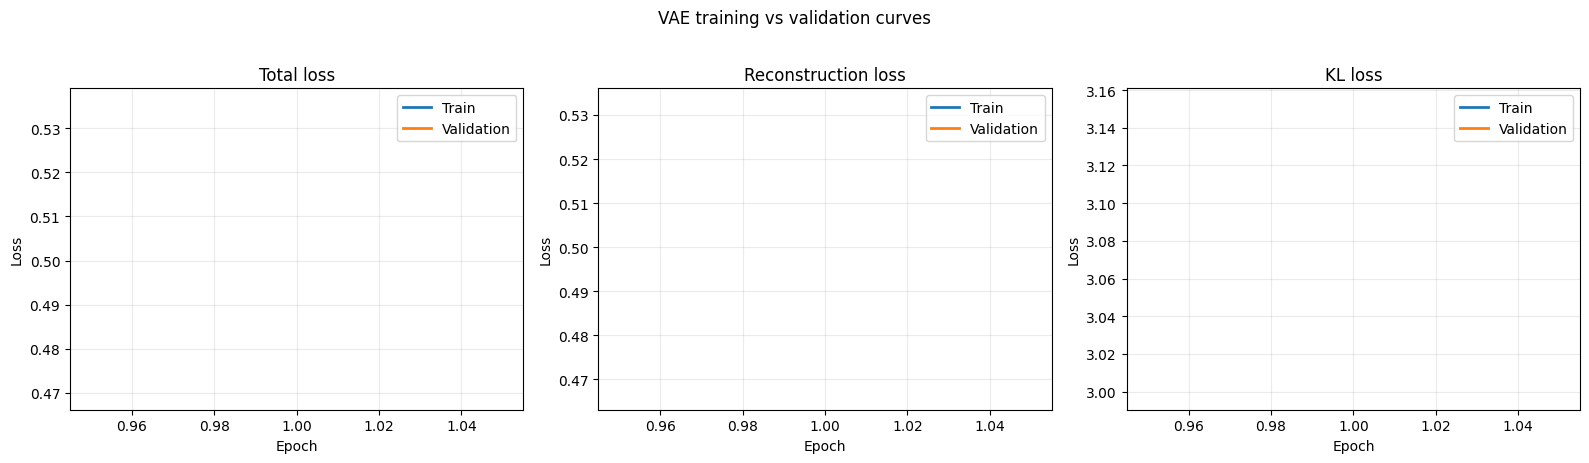

In [87]:
# Training / validation loss curves (total + recon + KL)
epochs_ran = min(
    len(train_total_history), len(val_total_history),
    len(train_recon_history), len(val_recon_history),
    len(train_kl_history), len(val_kl_history),
)
epoch_axis = np.arange(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(epoch_axis, train_total_history[:epochs_ran], label="Train", linewidth=2)
axes[0].plot(epoch_axis, val_total_history[:epochs_ran], label="Validation", linewidth=2)
axes[0].set_title("Total loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(epoch_axis, train_recon_history[:epochs_ran], label="Train", linewidth=2)
axes[1].plot(epoch_axis, val_recon_history[:epochs_ran], label="Validation", linewidth=2)
axes[1].set_title("Reconstruction loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].plot(epoch_axis, train_kl_history[:epochs_ran], label="Train", linewidth=2)
axes[2].plot(epoch_axis, val_kl_history[:epochs_ran], label="Validation", linewidth=2)
axes[2].set_title("KL loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].grid(alpha=0.25)
axes[2].legend()

fig.suptitle("VAE training vs validation curves", y=1.02)
plt.tight_layout()
plt.show()

#### Save the weights

In [26]:
# Save trained ZINB VAE weights
save_dir = Path(r"C:\Users\ntpar\OneDrive\Desktop\BEP\model_paths")
save_dir.mkdir(parents=True, exist_ok=True)
weights_path = save_dir / "VAE_ZINB_weights"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "log_theta": log_theta.detach().cpu(),
        "logit_pi": logit_pi.detach().cpu(),
        "gene_names": gene_names.tolist(),
        "best_epoch": best_epoch if "best_epoch" in globals() else None,
        "best_val_loss": float(best_val_loss) if "best_val_loss" in globals() else None,
    },
    weights_path,
)
print(f"Saved ZINB VAE weights to: {weights_path}")

Saved ZINB VAE weights to: C:\Users\ntpar\OneDrive\Desktop\BEP\model_paths\VAE_ZINB_weights


#### Load the weights

In [86]:
# Load trained ZINB VAE weights from the path saved in the cell above
if "weights_path" not in globals():
    raise ValueError("`weights_path` is not defined. Run the save-weights cell first.")
if "model" not in globals() or "log_theta" not in globals() or "logit_pi" not in globals():
    raise ValueError("Model objects are missing. Run the model definition cell first.")

ckpt = torch.load(weights_path, map_location=device)

if "model_state_dict" not in ckpt:
    raise KeyError("Checkpoint is missing `model_state_dict`.")
model.load_state_dict(ckpt["model_state_dict"])

with torch.no_grad():
    if "log_theta" in ckpt:
        log_theta.copy_(ckpt["log_theta"].to(device))
    if "logit_pi" in ckpt:
        logit_pi.copy_(ckpt["logit_pi"].to(device))

model.eval()
print(f"Loaded weights from: {weights_path}")
if "best_epoch" in ckpt and ckpt["best_epoch"] is not None:
    print(f"Checkpoint best_epoch: {ckpt['best_epoch']}")
if "best_val_loss" in ckpt and ckpt["best_val_loss"] is not None:
    print(f"Checkpoint best_val_loss: {ckpt['best_val_loss']:.6f}")

Loaded weights from: C:\Users\ntpar\OneDrive\Desktop\BEP\model_paths\VAE_ZINB_weights
Checkpoint best_epoch: 29
Checkpoint best_val_loss: 0.443404


## Evaluation for VAE

### Loss & MSE 

ZINB unified validation:   0%|          | 0/56 [00:00<?, ?batch/s]C:\Users\ntpar\AppData\Local\Temp\ipykernel_11688\4271942572.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_cuda):
ZINB unified validation: 100%|██████████| 56/56 [00:01<00:00, 29.24batch/s]


ZINB validation/test summary (raw-count pipeline):


,metric,value
0,test_total_loss_zinb,0.441945
1,test_recon_loss_zinb,0.439091
2,test_kl,2.853534
3,test_MSE_counts,1.274577
4,test_MSE_log1p,0.076169



ZINB baseline scoreboard (lower is better):


,method,mse_counts,mse_log1p
0,VAE (ZINB expected decode),1.274577,0.076169
1,Identity baseline (input passthrough),4.029248,0.130372
2,Gene-mean baseline (train),4.947361,0.238088


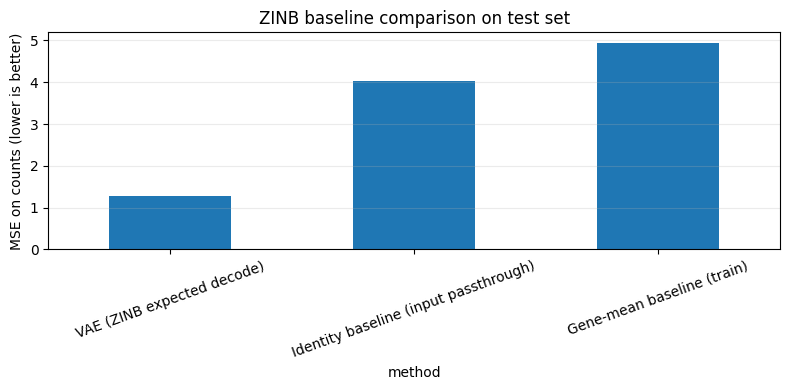

In [88]:
# ZINB-style unified validation (raw-count pipeline)

model.eval()
all_recon_expected = []
all_true_counts = []
all_input_counts = []

test_loss_sum = 0.0
test_recon_sum = 0.0
test_kl_sum = 0.0
n_test_batches = 0

# This calculates the learned zero-inflation probs for each gene, which we will use to compute the expected reconstructed counts under the ZINB model.
pi_vec = torch.sigmoid(logit_pi.detach()).cpu().numpy().astype(np.float32)

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="ZINB validation", unit="batch"):
        xb = xb.to(device, non_blocking=use_cuda)
        yb = yb.to(device, non_blocking=use_cuda)

        with torch.cuda.amp.autocast(enabled=use_cuda):
            # The model's raw decoder output (recon)
            recon, mu, logvar = model(xb)
            t_loss, t_recon, t_kl = vae_loss(
                recon,
                yb,
                mu,
                logvar,
                beta=beta,
                loss_mask=None,
                theta_param=log_theta,
                zi_logits=logit_pi,
            )

        test_loss_sum += float(t_loss.item())
        test_recon_sum += float(t_recon.item())
        test_kl_sum += float(t_kl.item())
        n_test_batches += 1

        # The expected reconstructed counts under the ZINB model is (1-pi)*mu, where mu is the NB mean (softplus of the decoder output) and pi is the zero-inflation probability. 
        # We compute this for each batch and store it for later evaluation.
        recon_mu = torch.nn.functional.softplus(recon).cpu().numpy().astype(np.float32)

        # Apply the zero-inflation adjustment to get the expected counts
        recon_expected = recon_mu * (1.0 - pi_vec[None, :])
        true_counts = yb.clamp_min(0.0).cpu().numpy().astype(np.float32)
        input_counts = xb.clamp_min(0.0).cpu().numpy().astype(np.float32)

        all_recon_expected.append(recon_expected)
        all_true_counts.append(true_counts)
        all_input_counts.append(input_counts)

if n_test_batches == 0:
    raise RuntimeError("No test batches were produced.")

X_test_recon_nb = np.concatenate(all_recon_expected, axis=0)
X_test_tgt_nb = np.concatenate(all_true_counts, axis=0)
X_test_in_nb = np.concatenate(all_input_counts, axis=0)

# Keep compatibility with downstream cells if needed
X_test_recon = np.asarray(X_test_recon_nb, dtype=np.float32)
X_test_tgt = np.asarray(X_test_tgt_nb, dtype=np.float32)

summary_table_nb = pd.DataFrame([
    {"metric": "test_total_loss_zinb", "value": test_loss_sum / n_test_batches},
    {"metric": "test_recon_loss_zinb", "value": test_recon_sum / n_test_batches},
    {"metric": "test_kl", "value": test_kl_sum / n_test_batches},
    {"metric": "test_MSE_counts", "value": float(np.mean((X_test_recon_nb - X_test_tgt_nb) ** 2))},
    {"metric": "test_MSE_log1p", "value": float(np.mean((np.log1p(X_test_recon_nb) - np.log1p(X_test_tgt_nb)) ** 2))},
])

print("ZINB validation/test summary (raw-count pipeline):")
display(summary_table_nb)

x_true = np.asarray(X_test_tgt_nb, dtype=np.float32)
x_vae = np.asarray(X_test_recon_nb, dtype=np.float32)
x_identity = np.asarray(X_test_in_nb, dtype=np.float32)
x_train_tgt = np.asarray(X_tgt[train_idx].clip(min=0.0), dtype=np.float32)

# Gene-mean baseline in count space
gene_mean_train = x_train_tgt.mean(axis=0)
x_gene_mean = np.broadcast_to(gene_mean_train, x_true.shape).astype(np.float32, copy=False)

rows = []
for method_name, pred in {
    "VAE (ZINB expected decode)": x_vae,
    "Identity baseline (input passthrough)": x_identity,
    "Gene-mean baseline (train)": x_gene_mean,
}.items():
    rows.append({
        "method": method_name,
        "mse_counts": float(np.mean((pred - x_true) ** 2)),
        "mse_log1p": float(np.mean((np.log1p(pred) - np.log1p(x_true)) ** 2)),
    })

scoreboard_nb = pd.DataFrame(rows).sort_values("mse_counts", ascending=True).reset_index(drop=True)
print("\nZINB baseline scoreboard (lower is better):")
display(scoreboard_nb)

ax = scoreboard_nb.plot(kind="bar", x="method", y="mse_counts", figsize=(8, 4), legend=False, rot=20)
ax.set_title("ZINB baseline comparison on test set")
ax.set_ylabel("MSE on counts (lower is better)")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Evaluation on reconstructed 5K
What the inference on 5K means: 
1. Take each 5K cell
2. Align it to the model gene space
3. Feed it through the trained VAE, decode it into ZINB parameters
4. Use the expected value of that ZINB distribution as the reconstructed expression profile.

#### Reconstructing the 5K 

In [106]:
# ZINB-style 5K -> V1-like reconstruction (strict model gene space, raw-count input)
# Inference-only cell: prepares reconstructed arrays and summary metrics for downstream plotting.
model.eval()

# Genes shared across model, 5K, and V1
genes_model = np.array(gene_names, dtype=object)
common_5k_model = np.intersect1d(genes_model, adata_5k.var_names.values)
common_v1_model = np.intersect1d(genes_model, adata_v1.var_names.values)
common_triplet = np.intersect1d(common_5k_model, common_v1_model)

print(f"Model genes (strict): {len(genes_model)}")
print(f"5K genes in model: {len(common_5k_model)}")
print(f"V1 genes in model: {len(common_v1_model)}")
print(f"(5K ∩ V1 ∩ model): {len(common_triplet)}")

if len(common_5k_model) == 0:
    raise ValueError("No overlap between 5K genes and model gene space.")
if len(common_v1_model) == 0:
    raise ValueError("No overlap between V1 genes and model gene space.")

# Build 5K raw-count input in strict model order
X5k_in = np.zeros((adata_5k.n_obs, len(genes_model)), dtype=np.float32)
model_pos = pd.Index(genes_model).get_indexer(common_5k_model)
g5k_pos = pd.Index(adata_5k.var_names).get_indexer(common_5k_model)
X5k_in[:, model_pos] = _to_dense_float32(adata_5k.X[:, g5k_pos])
X5k_in = np.clip(X5k_in, 0.0, None)

# Inference: expected counts under ZINB, E[X] = (1-pi) * mu
with torch.no_grad():
    xin = torch.tensor(X5k_in, dtype=torch.float32, device=device)
    raw_recon, _, _ = model(xin)
    mu_nb = torch.nn.functional.softplus(raw_recon).cpu().numpy().astype(np.float32)
    pi_vec = torch.sigmoid(logit_pi.detach()).cpu().numpy().astype(np.float32)
    X5k_recon_mu = mu_nb * (1.0 - pi_vec[None, :])

# Reconstructed AnnData
adata_5k_recon_nb = adata_5k.__class__(
    X=X5k_recon_mu,
    obs=adata_5k.obs.copy(),
    var=pd.DataFrame(index=genes_model),
)
adata_5k_recon_nb.obs_names = adata_5k.obs_names.copy()
adata_5k_recon = adata_5k_recon_nb

# Strict comparison set: model genes available in V1
strict_eval_genes = common_v1_model
idx_model_eval = pd.Index(genes_model).get_indexer(strict_eval_genes)
idx_v1_eval = pd.Index(adata_v1.var_names).get_indexer(strict_eval_genes)

X_recon_eval = X5k_recon_mu[:, idx_model_eval]
X_v1_eval = _to_dense_float32(adata_v1.X[:, idx_v1_eval])

# Stable aliases used by downstream cells
x_recon_eval = np.asarray(X_recon_eval, dtype=np.float32)
x_v1_eval = np.asarray(X_v1_eval, dtype=np.float32)
x_recon = x_recon_eval
x_v1 = x_v1_eval
model_genes = pd.Index(genes_model)

print(f"Cells -> recon from 5K: {X_recon_eval.shape[0]}, V1 reference: {X_v1_eval.shape[0]}")
print(f"Genes compared (strict): {X_recon_eval.shape[1]}")

finite_recon = np.isfinite(X_recon_eval).all()
finite_v1 = np.isfinite(X_v1_eval).all()
print(f"Finite check -> recon: {finite_recon}, v1: {finite_v1}")
if not (finite_recon and finite_v1):
    raise RuntimeError("Non-finite values detected in ZINB-style strict comparison arrays.")

# Gene-level metrics inputs
theta_vec = torch.nn.functional.softplus(log_theta.detach()).cpu().numpy().astype(np.float32)
theta_eval = theta_vec[idx_model_eval]
pi_eval = pi_vec[idx_model_eval]

mean_recon = X_recon_eval.mean(axis=0)
mean_v1 = X_v1_eval.mean(axis=0)
nb_p0 = np.power(theta_eval[None, :] / (theta_eval[None, :] + X_recon_eval + 1e-8), theta_eval[None, :])
p0 = pi_eval[None, :] + (1.0 - pi_eval[None, :]) * nb_p0
det_recon = (1.0 - p0).mean(axis=0)
det_v1 = (X_v1_eval > 0).mean(axis=0)

compare_zinb = pd.DataFrame([
    {
        "metric": "MSE_gene_mean_counts",
        "value": float(np.mean((mean_recon - mean_v1) ** 2)),
    },
    {
        "metric": "MSE_gene_mean_log1p",
        "value": float(np.mean((np.log1p(mean_recon) - np.log1p(mean_v1)) ** 2)),
    },
    {
        "metric": "MSE_gene_detection_rate_zinb_implied",
        "value": float(np.mean((det_recon - det_v1) ** 2)),
    },
])

# Compatibility alias used by plotting cells
metrics_df = compare_zinb.copy()

print("Inference complete for 5K -> V1 strict reconstruction.")
print("Prepared: adata_5k_recon, X_recon_eval, X_v1_eval, mean_recon, mean_v1, det_recon, det_v1, compare_zinb.")
display(compare_zinb)

Model genes (strict): 289
5K genes in model: 196
V1 genes in model: 289
(5K ∩ V1 ∩ model): 196
Cells -> recon from 5K: 262733, V1 reference: 188761
Genes compared (strict): 289
Finite check -> recon: True, v1: True
Inference complete for 5K -> V1 strict reconstruction.
Prepared: adata_5k_recon, X_recon_eval, X_v1_eval, mean_recon, mean_v1, det_recon, det_v1, compare_zinb.


,metric,value
0,MSE_gene_mean_counts,0.083405
1,MSE_gene_mean_log1p,0.011196
2,MSE_gene_detection_rate_zinb_implied,0.001661


#### Plot helper function

In [ ]:
# Exact-style subplot: y=x line, linear fit, n genes, Pearson r, and fit equation
def plot_exact_scatter_with_fit(
    x,
    y,
    title,
    x_label,
    y_label,
    color="#E68613",
    figsize=(7, 6),
    point_size=18,
    alpha=0.65,
    text_loc=(0.02, 0.98),
    line_pad=0.02,
    ax=None,
 ):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    n_genes = x.size
    if n_genes < 2:
        raise ValueError("Need at least 2 valid points to fit a line.")

    slope, intercept = np.polyfit(x, y, 1)
    pearson_r = float(np.corrcoef(x, y)[0, 1])

    line_max = float(max(x.max(), y.max())) * (1.0 + line_pad) if n_genes > 0 else 1.0
    line_x = np.array([0.0, line_max], dtype=np.float64)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True

    ax.scatter(x, y, s=point_size, alpha=alpha, color=color)
    ax.plot(line_x, line_x, "k--", linewidth=1.2, alpha=0.8, label="y = x")
    ax.plot(line_x, slope * line_x + intercept, color=color, linewidth=1.6, alpha=0.95, label="fit")

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")

    ax.text(
        text_loc[0], text_loc[1],
        f"genes={n_genes}\nPearson r={pearson_r:.3f}\nfit: y={slope:.3f}x+{intercept:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )

    ax.set_xlim(-0.01 * line_max, line_max)
    ax.set_ylim(-0.01 * line_max, line_max)

    if created_fig:
        plt.tight_layout()
        plt.show()

    return {
        "n_genes": int(n_genes),
        "pearson_r": pearson_r,
        "slope": float(slope),
        "intercept": float(intercept),
        "line_max": line_max,
    }

#### Standardized plotting 

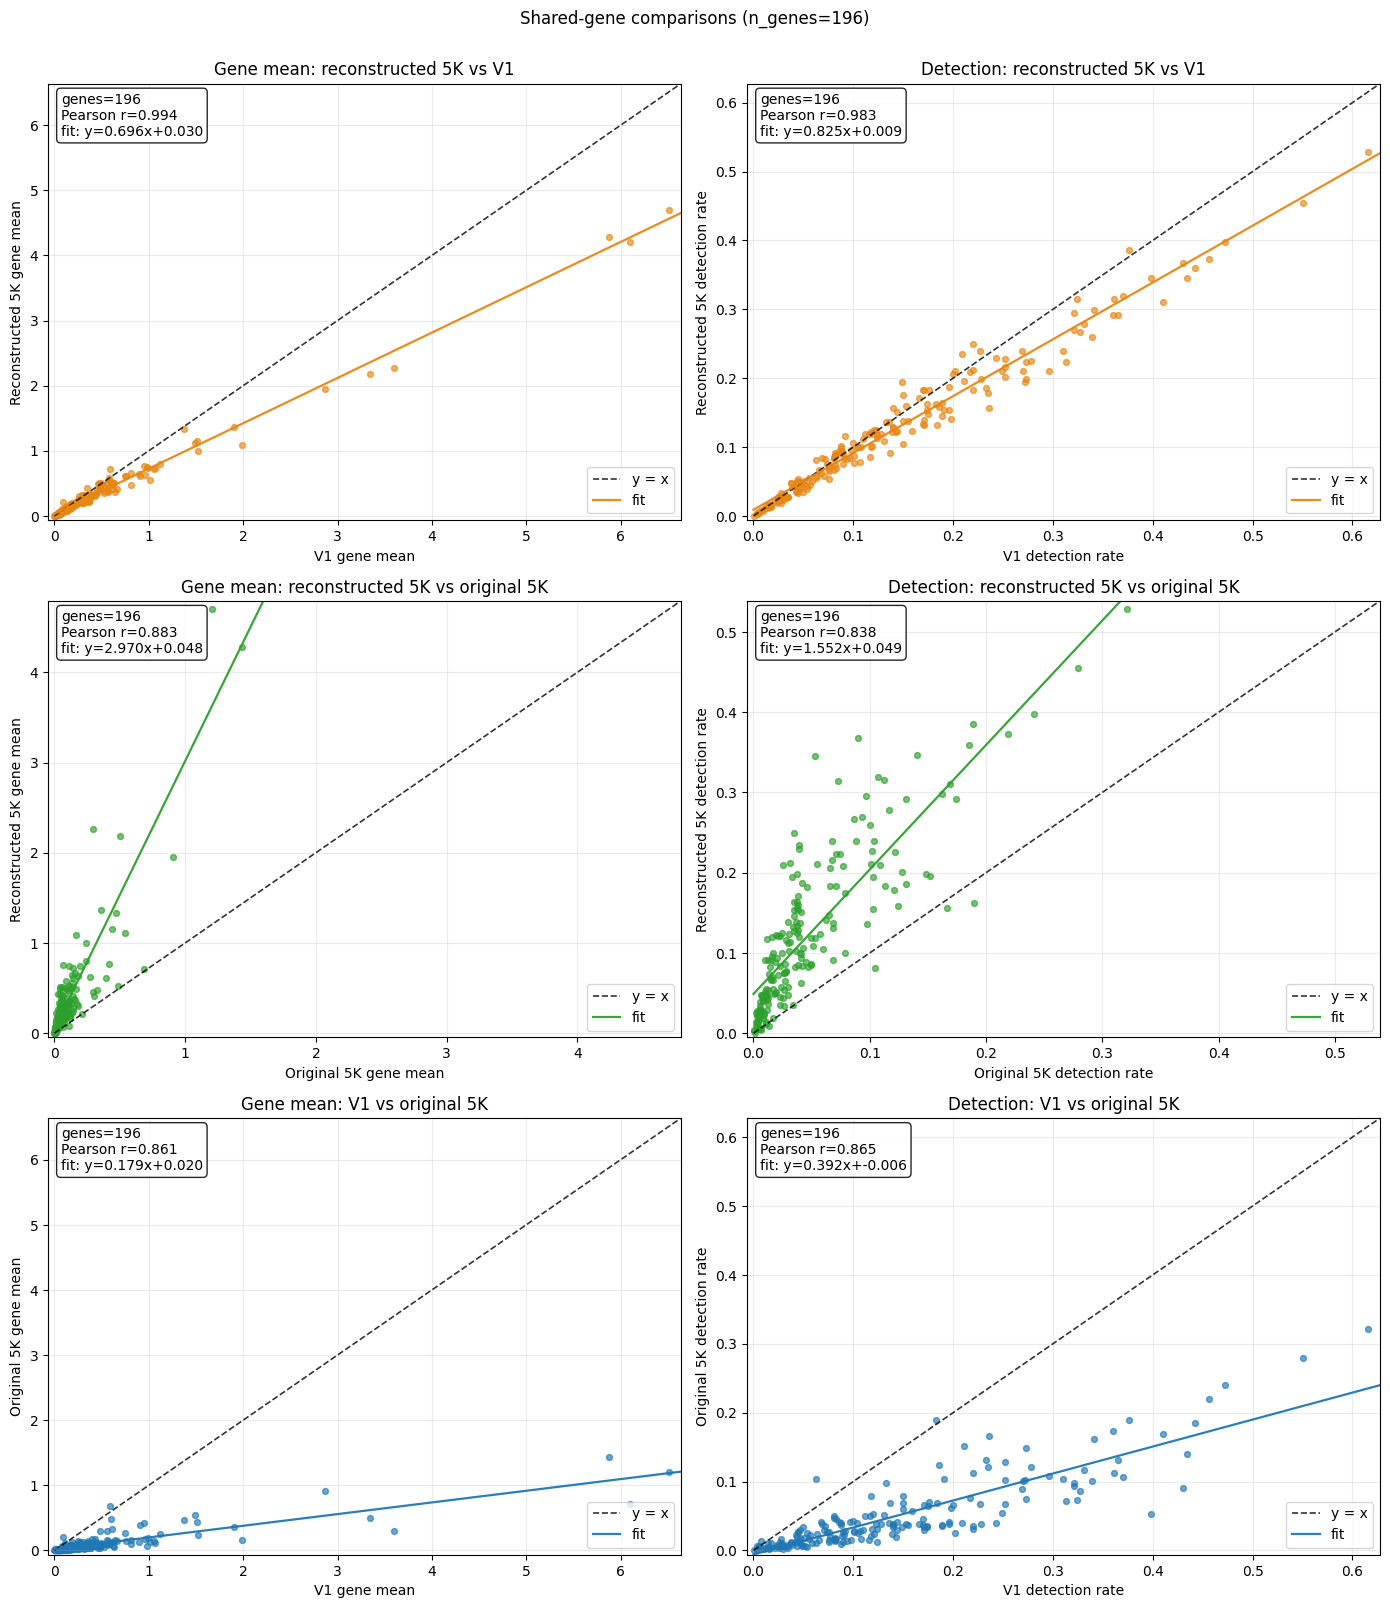

In [110]:
common_genes_all = pd.Index(adata_5k.var_names.astype(str))
common_genes_all = common_genes_all.intersection(pd.Index(adata_v1.var_names.astype(str)))
common_genes_all = common_genes_all.intersection(pd.Index(adata_5k_recon.var_names.astype(str)))
if len(common_genes_all) == 0:
    raise ValueError("No common genes across adata_5k, adata_v1, and adata_5k_recon.")

a5 = adata_5k[:, common_genes_all]
av = adata_v1[:, common_genes_all]
ar = adata_5k_recon[:, common_genes_all]

x5 = _to_dense_float32(a5.X) if "_to_dense_float32" in globals() else np.asarray(a5.X, dtype=np.float32)
xv = _to_dense_float32(av.X) if "_to_dense_float32" in globals() else np.asarray(av.X, dtype=np.float32)
xr_expected = _to_dense_float32(ar.X) if "_to_dense_float32" in globals() else np.asarray(ar.X, dtype=np.float32)

# Gene-level means
mean_5k = x5.mean(axis=0)
mean_v1 = xv.mean(axis=0)
mean_recon = xr_expected.mean(axis=0)

# Observed detection for originals
det_5k = (x5 > 0).mean(axis=0)
det_v1 = (xv > 0).mean(axis=0)

# Reconstructed detection: prefer ZINB-implied detection when parameters are available.
if "log_theta" in globals() and "logit_pi" in globals() and ("genes_model" in globals() or "gene_names" in globals()):
    model_genes_ref = np.array(globals().get("genes_model", globals().get("gene_names")), dtype=object)
    idx_model = pd.Index(model_genes_ref).get_indexer(common_genes_all)
    if np.any(idx_model < 0):
        # Fallback if alignment fails for any gene
        det_recon = (xr_expected > 0).mean(axis=0)
    else:
        theta_vec = torch.nn.functional.softplus(log_theta.detach()).cpu().numpy().astype(np.float32)
        pi_vec = torch.sigmoid(logit_pi.detach()).cpu().numpy().astype(np.float32)
        theta = np.clip(theta_vec[idx_model], 1e-8, None)
        pi = np.clip(pi_vec[idx_model], 1e-8, 1.0 - 1e-8)

        # xr_expected stores E[X] = (1-pi)*mu, recover mu for NB(0).
        mu_nb = xr_expected / (1.0 - pi[None, :] + 1e-8)
        nb_p0 = np.power(theta[None, :] / (theta[None, :] + np.clip(mu_nb, 0.0, None) + 1e-8), theta[None, :])
        p0 = pi[None, :] + (1.0 - pi[None, :]) * nb_p0
        det_recon = (1.0 - p0).mean(axis=0)
else:
    det_recon = (xr_expected > 0).mean(axis=0)

fig, axes = plt.subplots(3, 2, figsize=(14, 16))


# Reconstructed vs V1
plot_exact_scatter_with_fit(
    x=mean_v1, y=mean_recon,
    title="Gene mean: reconstructed 5K vs V1",
    x_label="V1 gene mean",
    y_label="Reconstructed 5K gene mean",
    color="#E68613",
    ax=axes[0, 0],
)
plot_exact_scatter_with_fit(
    x=det_v1, y=det_recon,
    title="Detection: reconstructed 5K vs V1",
    x_label="V1 detection rate",
    y_label="Reconstructed 5K detection rate",
    color="#E68613",
    ax=axes[0, 1],
)

# Reconstructed vs 5K 
plot_exact_scatter_with_fit(
    x=mean_5k, y=mean_recon,
    title="Gene mean: reconstructed 5K vs original 5K",
    x_label="Original 5K gene mean",
    y_label="Reconstructed 5K gene mean",
    color="#2ca02c",
    ax=axes[1, 0],
)
plot_exact_scatter_with_fit(
    x=det_5k, y=det_recon,
    title="Detection: reconstructed 5K vs original 5K",
    x_label="Original 5K detection rate",
    y_label="Reconstructed 5K detection rate",
    color="#2ca02c",
    ax=axes[1, 1],
)

# V1 vs 5k
plot_exact_scatter_with_fit(
    x=mean_v1, y=mean_5k,
    title="Gene mean: V1 vs original 5K",
    x_label="V1 gene mean",
    y_label="Original 5K gene mean",
    color="#1f77b4",
    ax=axes[2, 0],
)
plot_exact_scatter_with_fit(
    x=det_v1, y=det_5k,
    title="Detection: V1 vs original 5K",
    x_label="V1 detection rate",
    y_label="Original 5K detection rate",
    color="#1f77b4",
    ax=axes[2, 1],
)

fig.suptitle(f"Shared-gene comparisons (n_genes={len(common_genes_all)})", y=1.002)
plt.tight_layout()
plt.show()

#### Per-gene histograms
**NOTE:** These were sampled according to the ZINB distribution, unlike the rest of the code up until now, where the expected value of the ZINB distribution was used 

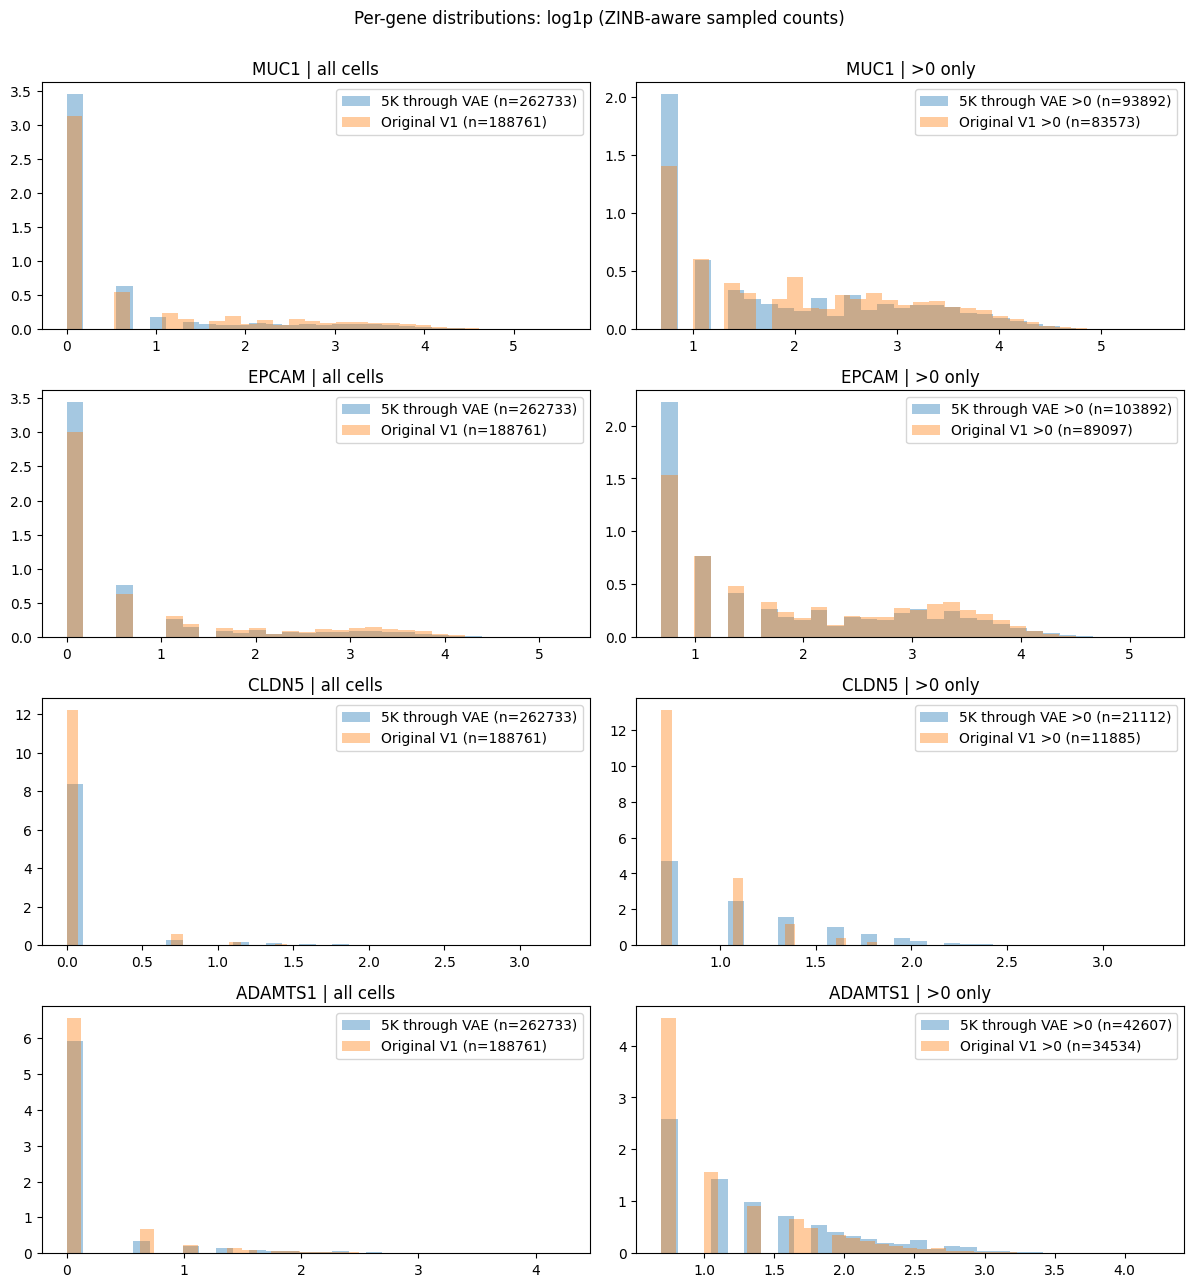

Per-gene summary (mean counts + detection %):


,gene,mean_first,mean_second,detect_pct_first_sampled,detect_pct_first_model_implied,detect_pct_second
0,MUC1,4.158674,6.095237,35.736660,35.806447,44.274506
1,EPCAM,4.243551,5.880161,39.542806,39.643481,47.200958
2,CLDN5,0.208615,0.091142,8.035534,8.067659,6.296322
3,ADAMTS1,0.710923,0.592707,16.216844,16.184409,18.295093


In [109]:
# Plotting-only cell for strict 5K->V1 reconstruction outputs

model_genes_arr = np.array(globals().get("model_genes", globals().get("genes_model", gene_names)), dtype=object)
x_v1_eval = np.asarray(globals().get("x_v1", globals().get("X_v1_eval")), dtype=np.float32)
x_recon_eval = np.asarray(globals().get("x_recon", globals().get("X_recon_eval")), dtype=np.float32)
zinb_mode = bool(globals().get("zinb_mode", True))

if x_v1_eval.shape[1] != x_recon_eval.shape[1]:
    raise ValueError(f"Gene dimension mismatch: x_v1_eval={x_v1_eval.shape}, x_recon_eval={x_recon_eval.shape}")

model_gene_pos = {g: i for i, g in enumerate(model_genes_arr)}
rng = np.random.default_rng(42)

theta_vec = torch.nn.functional.softplus(log_theta.detach()).cpu().numpy().astype(np.float32)
pi_vec = torch.sigmoid(logit_pi.detach()).cpu().numpy().astype(np.float32)

n_rows = len(plot_genes)
fig, axs = plt.subplots(n_rows, 2, figsize=(12, 3.2 * n_rows), squeeze=False)

summary_rows = []
for i, gene in enumerate(plot_genes):
    g_idx = model_gene_pos[gene]
    xv_all = x_v1_eval[:, g_idx]

    if zinb_mode:
        mu_g = x_recon_eval[:, g_idx].astype(np.float32)
        theta_g = float(theta_vec[g_idx])
        pi_g = float(pi_vec[g_idx])

        lam = rng.gamma(shape=theta_g, scale=mu_g / (theta_g + 1e-8))
        x5_nb = rng.poisson(lam).astype(np.float32)
        drop_mask = rng.random(x5_nb.shape[0]) < pi_g
        x5_all = x5_nb
        x5_all[drop_mask] = 0.0

        det_model_implied = float(
            (
                1.0
                - (
                    pi_g
                    + (1.0 - pi_g)
                    * np.power(theta_g / (theta_g + np.clip(x_recon_eval[:, g_idx], 0.0, None) + 1e-8), theta_g)
                )
            ).mean()
        )
    else:
        x5_all = x_recon_eval[:, g_idx].astype(np.float32)
        det_model_implied = float((x5_all > 0).mean())

    x5_pos = x5_all[x5_all > 0]
    xv_pos = xv_all[xv_all > 0]

    x5_plot_all = np.log1p(np.clip(x5_all, 0.0, None))
    xv_plot_all = np.log1p(np.clip(xv_all, 0.0, None))
    x5_plot_pos = np.log1p(np.clip(x5_pos, 0.0, None))
    xv_plot_pos = np.log1p(np.clip(xv_pos, 0.0, None))

    axL = axs[i, 0]
    axL.hist(x5_plot_all, bins=30, density=True, alpha=0.4, label=f"5K through VAE (n={len(x5_plot_all)})")
    axL.hist(xv_plot_all, bins=30, density=True, alpha=0.4, label=f"Original V1 (n={len(xv_plot_all)})")
    axL.set_title(f"{gene} | all cells")
    axL.legend(frameon=True)

    axR = axs[i, 1]
    if x5_plot_pos.size > 0:
        axR.hist(x5_plot_pos, bins=30, density=True, alpha=0.4, label=f"5K through VAE >0 (n={len(x5_plot_pos)})")
    if xv_plot_pos.size > 0:
        axR.hist(xv_plot_pos, bins=30, density=True, alpha=0.4, label=f"Original V1 >0 (n={len(xv_plot_pos)})")
    axR.set_title(f"{gene} | >0 only")
    axR.legend(frameon=True)

    summary_rows.append(
        {
            "gene": gene,
            "mean_first": float(np.mean(x5_all)),
            "mean_second": float(np.mean(xv_all)),
            "detect_pct_first_sampled": float(100.0 * np.mean(x5_all > 0)),
            "detect_pct_first_model_implied": float(100.0 * det_model_implied),
            "detect_pct_second": float(100.0 * np.mean(xv_all > 0)),
        }
    )

fig.suptitle("Per-gene distributions: log1p (ZINB-aware sampled counts)", y=1.002)
plt.tight_layout()
plt.show()

print("Per-gene summary (mean counts + detection %):")
display(pd.DataFrame(summary_rows))

# Tokenized multi-panel autoencoder

This section replaces fixed-position vectors with gene tokens so one model can train across panels with different gene sets.

#### Helper functions

In [120]:
# Tokenized model setup: imports + helpers + panel/tissue config
def _to_dense_float32(X):
    if sp.issparse(X):
        return X.toarray().astype(np.float32)
    return np.asarray(X, dtype=np.float32)


def build_gene_vocab(adatas_list):
    genes = pd.Index([])
    for adata in adatas_list:
        genes = genes.union(pd.Index(adata.var_names.astype(str)))
    genes = genes.sort_values()
    gene2id = {g: i for i, g in enumerate(genes)}
    id2gene = np.array(genes, dtype=object)
    return gene2id, id2gene

# Build panel-specific corrupted & clean training examples (no forced shared gene space)
def make_corruptions(adata_clean, n_reps=3, p=0.19, base_seed=42):
    out = []
    for rep in range(n_reps):
        out.append(
            downsample_v1_fixed_p_binomial(
                adata_clean,
                p=p,
                seed=base_seed + rep
            )
        )
    return out

#### Setting up the panels that will be used

In [121]:
# Panels used for tokenized training (V1-style, native genes preserved)
TRAIN_PANELS = ["V1", "Lung1", "Lung2", "V1_Ovary"]

# Adjust if your metadata convention changes
PANEL_TO_TISSUE = {
    "V1": "lung",
    "Lung1": "lung",
    "Lung2": "lung",
    "V1_Ovary": "ovary",
}

# Check if there are missing panels or missing mapppings 
missing_train_panels = [p for p in TRAIN_PANELS if p not in adatas]
if missing_train_panels:
    raise ValueError(f"Missing expected panels in adatas: {missing_train_panels}. Available: {sorted(adatas.keys())}")

for p in TRAIN_PANELS:
    if p not in PANEL_TO_TISSUE:
        raise ValueError(f"No tissue mapping defined for panel: {p}")

print("Tokenized training panels:", TRAIN_PANELS)
print("Tissue mapping:", PANEL_TO_TISSUE)

Tokenized training panels: ['V1', 'Lung1', 'Lung2', 'V1_Ovary']
Tissue mapping: {'V1': 'lung', 'Lung1': 'lung', 'Lung2': 'lung', 'V1_Ovary': 'ovary'}


#### Preparing the paired corrupted/downsampled - GT pairs

In [122]:
# Number of corrupted versions per panel 
N_REPS_PER_PANEL = 2

# Per-tissue corruption probabilities
P_BY_TISSUE = {
    "lung": 0.19,
    "ovary": 0.16,
}

panel2id = {p: i for i, p in enumerate(sorted(TRAIN_PANELS))}
tissue_names = sorted({PANEL_TO_TISSUE[p] for p in TRAIN_PANELS})
tissue2id = {t: i for i, t in enumerate(tissue_names)}

missing_tissues = sorted(set(PANEL_TO_TISSUE[p] for p in TRAIN_PANELS) - set(P_BY_TISSUE.keys()))
if missing_tissues:
    raise ValueError(f"Missing p values for tissues: {missing_tissues}")

# We make the paired lists of corrupted versions to their ground truth 
examples = []
for panel_name in TRAIN_PANELS:
    tissue_name = PANEL_TO_TISSUE[panel_name]
    p_panel = float(P_BY_TISSUE[tissue_name])

    y_clean = adatas[panel_name].copy()
    x_corrupt_list = make_corruptions(
        y_clean,
        n_reps=N_REPS_PER_PANEL,
        p=p_panel,
        base_seed=2000 + 97 * panel2id[panel_name],
    )
    for x_corrupt in x_corrupt_list:
        examples.append(
            {
                "panel_name": panel_name,
                "tissue_name": tissue_name,
                "panel_id": panel2id[panel_name],
                "tissue_id": tissue2id[tissue_name],
                "x_adata": x_corrupt,
                "y_adata": y_clean,
            }
        )

print(f"Constructed {len(examples)} panel-level paired examples.")
print("Panels:", panel2id)
print("Tissues:", tissue2id)
print("P by tissue:", P_BY_TISSUE)

Constructed 8 panel-level paired examples.
Panels: {'Lung1': 0, 'Lung2': 1, 'V1': 2, 'V1_Ovary': 3}
Tissues: {'lung': 0, 'ovary': 1}
P by tissue: {'lung': 0.19, 'ovary': 0.16}


#### Creating the GeneToken Dataset 
This class turns the panel-paired data into training datasets that PyTorch can use 

Each dataset item becomes one cell with
- gene_ids: The token IDs of the genes that are in the panel (so these are the same for each cell from the same panel)
- x_vals: The expression values of the corrupted/downsampled version
- y_vals: The GT expression values 
- shared_mask: For the genes that are shared across all training panels (just used for evaluation)
- tissue_ID: Integer ID of the tissue
- tissue_name: String name of the tissue 
- panel_ID: Integer ID of the tissue 
- panel_name: String name of the panel

In [124]:
# Token dataset + collate for variable-length gene sets
class GeneTokenDataset(Dataset):
    """
    One item = one cell from one panel-specific pair.
    Input tokens come from corrupted counts; target tokens from clean counts.
    """
    # We initialize with the list of paired examples and the gene2id mapping, and we pre-tokenize all cells into a list of dicts for fast __getitem__.
    def __init__(self, examples, gene2id, shared_genes):
        self.rows = []
        self.gene2id = gene2id
        shared_genes = set(map(str, shared_genes))

        for ex in examples:
            x_ad = ex["x_adata"]
            y_ad = ex["y_adata"]
            panel_name = ex["panel_name"]
            tissue_name = ex["tissue_name"]

            if x_ad.n_obs != y_ad.n_obs:
                raise ValueError(f"Cell mismatch for panel {panel_name}: {x_ad.n_obs} vs {y_ad.n_obs}")
            if not x_ad.var_names.equals(y_ad.var_names):
                raise ValueError(f"Gene order mismatch for panel {panel_name}")

            panel_genes = x_ad.var_names.astype(str).to_numpy()
            gene_ids = np.array([gene2id[g] for g in panel_genes], dtype=np.int64)
            shared_mask = np.array([g in shared_genes for g in panel_genes], dtype=bool)

            # Keep raw counts for both input and target.
            X = _to_dense_float32(x_ad.X)
            Y = _to_dense_float32(y_ad.X)
            X = np.clip(X, 0.0, None)
            Y = np.clip(Y, 0.0, None)

            for i in range(x_ad.n_obs):
                self.rows.append(
                    {
                        "gene_ids": gene_ids,
                        "x_vals": X[i],
                        "y_vals": Y[i],
                        "shared_mask": shared_mask,
                        "panel_id": int(ex["panel_id"]),
                        "tissue_id": int(ex["tissue_id"]),
                        "panel_name": panel_name,
                        "tissue_name": tissue_name,
                    }
                )

    def __len__(self):
        return len(self.rows)

    # Used to get one cell from the data 
    def __getitem__(self, idx):
        r = self.rows[idx]
        return {
            "gene_ids": torch.tensor(r["gene_ids"], dtype=torch.long),
            "x_vals": torch.tensor(r["x_vals"], dtype=torch.float32),
            "y_vals": torch.tensor(r["y_vals"], dtype=torch.float32),
            "shared_mask": torch.tensor(r["shared_mask"], dtype=torch.bool),
            "panel_id": torch.tensor(r["panel_id"], dtype=torch.long),
            "tissue_id": torch.tensor(r["tissue_id"], dtype=torch.long),
            "panel_name": r["panel_name"],
            "tissue_name": r["tissue_name"],
        }

# Needed to make padded tensors for the model, so we can handle a different number of genes per panel.
def collate_gene_tokens(batch):
    B = len(batch)
    lengths = [len(item["gene_ids"]) for item in batch]
    Lmax = max(lengths)

    gene_ids = torch.zeros(B, Lmax, dtype=torch.long)
    x_vals = torch.zeros(B, Lmax, dtype=torch.float32)
    y_vals = torch.zeros(B, Lmax, dtype=torch.float32)
    attn_mask = torch.zeros(B, Lmax, dtype=torch.bool)
    shared_mask = torch.zeros(B, Lmax, dtype=torch.bool)
    panel_ids = torch.zeros(B, dtype=torch.long)
    tissue_ids = torch.zeros(B, dtype=torch.long)
    panel_names = []
    tissue_names = []

    for i, item in enumerate(batch):
        L = len(item["gene_ids"])
        gene_ids[i, :L] = item["gene_ids"]
        x_vals[i, :L] = item["x_vals"]
        y_vals[i, :L] = item["y_vals"]
        attn_mask[i, :L] = True
        shared_mask[i, :L] = item["shared_mask"]
        panel_ids[i] = item["panel_id"]
        tissue_ids[i] = item["tissue_id"]
        panel_names.append(item["panel_name"])
        tissue_names.append(item["tissue_name"])

    return {
        "gene_ids": gene_ids,
        "x_vals": x_vals,
        "y_vals": y_vals,
        "attn_mask": attn_mask,
        "shared_mask": shared_mask,
        "panel_id": panel_ids,
        "tissue_id": tissue_ids,
        "panel_name": panel_names,
        "tissue_name": tissue_names,
    }


# Build global vocab from clean training panels
train_clean_adatas = [adatas[p] for p in TRAIN_PANELS]
gene2id, id2gene = build_gene_vocab(train_clean_adatas)

# Genes shared across all training panels (for shared vs panel-specific evaluation)
shared_train_genes = set(train_clean_adatas[0].var_names.astype(str))
for ad in train_clean_adatas[1:]:
    shared_train_genes &= set(ad.var_names.astype(str))

dataset_token = GeneTokenDataset(
    examples=examples,
    gene2id=gene2id,
    shared_genes=shared_train_genes,
 )

print(f"Token dataset cells: {len(dataset_token)}")
print(f"Vocabulary size: {len(gene2id)}")
print(f"Genes shared across training panels: {len(shared_train_genes)}")

Token dataset cells: 1255704
Vocabulary size: 827
Genes shared across training panels: 101


## GeneTokenAutoEncoder with ZINB loss reconstruction head

In [125]:
# ZINB tokenized autoencoder (Transformer encoder + gene-query decoder)

class GeneTokenAutoencoder(nn.Module):
    def __init__(
        self,
        n_genes_vocab,
        n_panels,
        n_tissues,
        d_model=128,
        nhead=4,
        num_layers=3,
        latent_dim=32,
        dropout=0.1,
        theta_init=10.0,
    ):
        super().__init__()
        # The embeddings are learned by the model, and are made to be d_model sized vectors
        self.gene_emb = nn.Embedding(n_genes_vocab, d_model)
        self.panel_emb = nn.Embedding(n_panels, d_model)
        self.tissue_emb = nn.Embedding(n_tissues, d_model)

        # The value MLP converts raw token values into d_model sized vectors for the encoder.
        self.value_mlp = nn.Sequential(
            nn.Linear(1, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
        )

        # Main contextual encoder 
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # The latent bottleneck (so we have an autoencoder)
        self.latent_proj = nn.Linear(d_model, latent_dim)
        self.z_proj = nn.Linear(latent_dim, d_model)

        # Feedforward decoder, it takes the latent representatino, gene embedding and panel+tissue embedding to get ZINB parameters for each gene token 
        self.decoder_trunk = nn.Sequential(
            nn.Linear(3 * d_model, 2 * d_model),
            nn.GELU(),
            nn.Linear(2 * d_model, d_model),
            nn.GELU(),
        )
        # The output heads to get the ZINB parameters mu and pi (for now in logits) for each gene token 
        self.mu_head = nn.Linear(d_model, 1)
        self.pi_head = nn.Linear(d_model, 1)

        # Gene-specific spread parameter theta, which is learned per-gene on the entire dataset;
        theta_unconstrained_init = float(np.log(np.expm1(theta_init))) # unconstraint because not yet forced to be postive)
        self.log_theta_gene = nn.Embedding(n_genes_vocab, 1)
        nn.init.constant_(self.log_theta_gene.weight, theta_unconstrained_init)

    # This runs the input tokens through the encoder to get the latent representation z 
    def encode(self, gene_ids, x_vals, attn_mask, panel_id, tissue_id):
        g = self.gene_emb(gene_ids)
        x = self.value_mlp(x_vals.unsqueeze(-1))
        p = self.panel_emb(panel_id).unsqueeze(1)
        t = self.tissue_emb(tissue_id).unsqueeze(1)

        h = g + x + p + t
        pad_mask = ~attn_mask # Transformer expects True for padding positions
        h = self.encoder(h, src_key_padding_mask=pad_mask)

        mask_f = attn_mask.unsqueeze(-1).float()
        pooled = (h * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp_min(1.0) # we take the average over the gene tokens to get a single vector 
        z = self.latent_proj(pooled) 
        return z

    # This takes the latent representation z and decodes it back into ZINB parameters for each gene token
    def decode_params(self, z, gene_ids, panel_id, tissue_id):
        B, L = gene_ids.shape
        zg = self.z_proj(z).unsqueeze(1).expand(B, L, -1)
        g = self.gene_emb(gene_ids)
        p = self.panel_emb(panel_id).unsqueeze(1).expand(B, L, -1)
        t = self.tissue_emb(tissue_id).unsqueeze(1).expand(B, L, -1)

        dec_in = torch.cat([zg, g, p + t], dim=-1)
        h = self.decoder_trunk(dec_in)
        mu_logit = self.mu_head(h).squeeze(-1)
        pi_logit = self.pi_head(h).squeeze(-1)
        theta_unconstrained = self.log_theta_gene(gene_ids).squeeze(-1)
        return mu_logit, pi_logit, theta_unconstrained

    # This runs the full forward pass to get the reconstructed counts, as well as the intermediate ZINB parameters and latent representation 
    def forward_with_params(self, gene_ids, x_vals, attn_mask, panel_id, tissue_id):
        z = self.encode(gene_ids, x_vals, attn_mask, panel_id, tissue_id)
        mu_logit, pi_logit, theta_unconstrained = self.decode_params(z, gene_ids, panel_id, tissue_id)

        # Expected reconstructed counts under ZINB.
        mu = F.softplus(mu_logit)
        pi = torch.sigmoid(pi_logit)
        recon_counts = (1.0 - pi) * mu

        return recon_counts, z, mu_logit, pi_logit, theta_unconstrained

    # This is the simplified forward used for training and evaluation, which just returns the reconstructed counts and latent representation.
    def forward(self, gene_ids, x_vals, attn_mask, panel_id, tissue_id):
        recon_counts, z, _, _, _ = self.forward_with_params(
            gene_ids=gene_ids,
            x_vals=x_vals,
            attn_mask=attn_mask,
            panel_id=panel_id,
            tissue_id=tissue_id,
        )
        return recon_counts, z

# ZINB loss very similar to the VAE ZINB loss but computed at the token level, and averaged only over the valid tokens in the batch 
def token_zinb_loss(mu_logit, pi_logit, theta_unconstrained, target_counts, attn_mask, eps=1e-8):
    target_counts = target_counts.clamp_min(0.0)

    mu = F.softplus(mu_logit) + eps
    pi = torch.sigmoid(pi_logit)
    theta = F.softplus(theta_unconstrained) + eps

    log_theta_mu = torch.log(theta + mu + eps)
    nb_log_prob = (
        torch.lgamma(target_counts + theta)
        - torch.lgamma(theta)
        - torch.lgamma(target_counts + 1.0)
        + theta * (torch.log(theta + eps) - log_theta_mu)
        + target_counts * (torch.log(mu + eps) - log_theta_mu)
    )

    zero_mask = target_counts < eps
    nb_log_prob_zero = theta * (torch.log(theta + eps) - log_theta_mu)

    zero_log_prob = torch.logaddexp(
        torch.log(pi + eps),
        torch.log1p(-pi + eps) + nb_log_prob_zero,
    )
    nonzero_log_prob = torch.log1p(-pi + eps) + nb_log_prob

    zinb_nll = -torch.where(zero_mask, zero_log_prob, nonzero_log_prob)
    return zinb_nll[attn_mask].mean()


In [ ]:
# Split + DataLoaders + training/eval helper functions
def stratified_split_indices_by_panel(dataset, train_frac=0.7, val_frac=0.15, seed=42):
    """
    Fixed panel-based split:
      - train: all corrupted versions of V1
      - val: all corrupted versions of Lung1
      - test: all corrupted versions of V1_Ovary and Lung2

    train_frac/val_frac are kept only for API compatibility.
    """
    rng = np.random.default_rng(seed)

    panel_names = np.array([str(r.get("panel_name", "")) for r in dataset.rows], dtype=object)
    if np.any(panel_names == ""):
        raise ValueError("Some dataset rows are missing 'panel_name'; cannot enforce panel-only split.")

    train_panels = {"V1"}
    val_panels = {"Lung1"}
    test_panels = {"V1_Ovary", "Lung2"}
    allowed_panels = train_panels | val_panels | test_panels

    present_panels = set(np.unique(panel_names).tolist())
    unknown_panels = sorted(present_panels - allowed_panels)
    if unknown_panels:
        raise ValueError(
            f"Found panel(s) not covered by fixed split mapping: {unknown_panels}. "
            f"Allowed panels are: {sorted(allowed_panels)}"
        )

    train_idx = np.where(np.isin(panel_names, list(train_panels)))[0]
    val_idx = np.where(np.isin(panel_names, list(val_panels)))[0]
    test_idx = np.where(np.isin(panel_names, list(test_panels)))[0]

    if min(train_idx.size, val_idx.size, test_idx.size) == 0:
        raise ValueError(
            "Empty split produced with fixed panel mapping. "
            f"train={train_idx.size}, val={val_idx.size}, test={test_idx.size}"
        )

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    print("Split mode: fixed panel-only mapping")
    print(f"train panels={sorted(train_panels)} n={train_idx.size}")
    print(f"val panels={sorted(val_panels)} n={val_idx.size}")
    print(f"test panels={sorted(test_panels)} n={test_idx.size}")

    return train_idx, val_idx, test_idx


def run_epoch_token_ae(model, loader, optimizer, device, train=True, epoch_label="", log_every=200):
    model.train() if train else model.eval()

    loss_sum = 0.0
    n_batches = 0
    stage = "train" if train else "val"
    total_batches = len(loader)
    t0 = time.time()

    print(f"{epoch_label} [{stage}] starting | batches={total_batches}")

    # Keep a simple, single-line bar to avoid nested tqdm rendering issues in VS Code.
    iter_loader = tqdm(
        loader,
        desc=f"{epoch_label} [{stage}]",
        unit="batch",
        leave=True,
        position=0,
        dynamic_ncols=True,
        mininterval=0.5,
        file=sys.stdout,
    )

    for batch in iter_loader:
        batch_t0 = time.time()
        gene_ids = batch["gene_ids"].to(device)
        x_vals = batch["x_vals"].to(device)
        y_vals = batch["y_vals"].to(device)
        attn_mask = batch["attn_mask"].to(device)
        panel_id = batch["panel_id"].to(device)
        tissue_id = batch["tissue_id"].to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            _, _, mu_logit, pi_logit, theta_unconstrained = model.forward_with_params(
                gene_ids=gene_ids,
                x_vals=x_vals,
                attn_mask=attn_mask,
                panel_id=panel_id,
                tissue_id=tissue_id,
            )
            loss = token_zinb_loss(mu_logit, pi_logit, theta_unconstrained, y_vals, attn_mask)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        loss_sum += float(loss.item())
        n_batches += 1

        if n_batches == 1:
            print(f"{epoch_label} [{stage}] first batch done in {time.time() - batch_t0:.1f}s")

        if n_batches % log_every == 0 or n_batches == total_batches:
            avg_loss = loss_sum / n_batches
            elapsed = time.time() - t0
            print(
                f"{epoch_label} [{stage}] {n_batches}/{total_batches} "
                f"avg_zinb_nll={avg_loss:.5f} elapsed={elapsed/60:.1f}m"
            )
            iter_loader.set_postfix({"zinb_nll": f"{avg_loss:.5f}"})

    return loss_sum / max(n_batches, 1)


def collect_eval_rows(model, loader, device):
    model.eval()
    rows = []

    with torch.no_grad():
        for batch in tqdm(
            loader,
            desc="Token AE eval",
            unit="batch",
            leave=True,
            position=0,
            dynamic_ncols=True,
            mininterval=0.5,
            file=sys.stdout,
        ):
            gene_ids = batch["gene_ids"].to(device)
            x_vals = batch["x_vals"].to(device)
            y_vals = batch["y_vals"].to(device)
            attn_mask = batch["attn_mask"].to(device)
            shared_mask = batch["shared_mask"].to(device)
            panel_id = batch["panel_id"].to(device)
            tissue_id = batch["tissue_id"].to(device)

            recon_counts, _, mu_logit, pi_logit, theta_unconstrained = model.forward_with_params(
                gene_ids=gene_ids,
                x_vals=x_vals,
                attn_mask=attn_mask,
                panel_id=panel_id,
                tissue_id=tissue_id,
            )

            diff2 = (recon_counts - y_vals) ** 2
            zinb_nll_tok = token_zinb_loss(mu_logit, pi_logit, theta_unconstrained, y_vals, attn_mask)

            for i in range(recon_counts.shape[0]):
                valid = attn_mask[i]
                shared = valid & shared_mask[i]
                specific = valid & (~shared_mask[i])

                row = {
                    "panel_name": batch["panel_name"][i],
                    "tissue_name": batch["tissue_name"][i],
                    "mse_all": float(diff2[i][valid].mean().item()) if valid.any() else np.nan,
                    "mse_shared": float(diff2[i][shared].mean().item()) if shared.any() else np.nan,
                    "mse_specific": float(diff2[i][specific].mean().item()) if specific.any() else np.nan,
                    "zinb_nll_batch": float(zinb_nll_tok.item()),
                    "n_tokens": int(valid.sum().item()),
                    "n_shared_tokens": int(shared.sum().item()),
                    "n_specific_tokens": int(specific.sum().item()),
                }
                rows.append(row)

    return pd.DataFrame(rows)

Token model device: cuda
Split mode: fixed panel-only mapping
train panels=['V1'] n=377522
val panels=['Lung1'] n=292788
test panels=['Lung2', 'V1_Ovary'] n=585394
train/val/test cells: 377522 / 292788 / 585394
train/val/test batches: 5899 / 4575 / 9147
Starting token AE training with ZINB loss...
Token AE epochs:   0%|          | 0/10 [00:00<?, ?epoch/s]
=== Epoch 01/10 ===
Epoch 01/10 [train] starting | batches=5899
Epoch 01/10 [train]:  10%|▉         | 563/5899 [00:44<06:46, 13.14batch/s, zinb_nll=0.61111]

Token model device: cuda
Split mode: fixed panel-only mapping
train panels=['V1'] n=377522
val panels=['Lung1'] n=292788
test panels=['Lung2', 'V1_Ovary'] n=585394
train/val/test cells: 377522 / 292788 / 585394
train/val/test batches: 5899 / 4575 / 9147
Starting token AE training with ZINB loss...
Token AE epochs:   0%|          | 0/10 [00:00<?, ?epoch/s]
=== Epoch 01/10 ===
Epoch 01/10 [train] starting | batches=5899
Epoch 01/10 [train]: 100%|██████████| 5899/5899 [06:20<00:00, 15.52batch/s, zinb_nll=0.47270]
Epoch 01/10 [val] starting | batches=4575
Epoch 01/10 [val]:   0%|          | 0/4575 [00:00<?, ?batch/s]

c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Token model device: cuda
Split mode: fixed panel-only mapping
train panels=['V1'] n=377522
val panels=['Lung1'] n=292788
test panels=['Lung2', 'V1_Ovary'] n=585394
train/val/test cells: 377522 / 292788 / 585394
train/val/test batches: 5899 / 4575 / 9147
Starting token AE training with ZINB loss...
Token AE epochs:   0%|          | 0/10 [00:00<?, ?epoch/s]
=== Epoch 01/10 ===
Epoch 01/10 [train] starting | batches=5899
Epoch 01/10 [train]: 100%|██████████| 5899/5899 [06:20<00:00, 15.52batch/s, zinb_nll=0.47270]
Epoch 01/10 [val] starting | batches=4575
Epoch 01/10 [val]:   0%|          | 0/4575 [00:00<?, ?batch/s]

c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Epoch 01/10 [val] first batch done in 0.3s
Token AE epochs:  10%|█         | 1/10 [09:11<1:22:47, 551.90s/epoch, train_nll=0.47270, val_nll=1.15597, best_epoch=1]
=== Epoch 02/10 ===
Epoch 02/10 [train] starting | batches=5899
Epoch 02/10 [train]: 100%|██████████| 5899/5899 [06:10<00:00, 15.92batch/s, zinb_nll=0.44132]
Epoch 02/10 [val] starting | batches=4575
Token AE epochs:  20%|██        | 2/10 [18:04<1:12:03, 540.43s/epoch, train_nll=0.44132, val_nll=1.02979, best_epoch=2]
=== Epoch 03/10 ===
Epoch 03/10 [train] starting | batches=5899
Epoch 03/10 [train]: 100%|██████████| 5899/5899 [06:03<00:00, 16.24batch/s, zinb_nll=0.43610]
Epoch 03/10 [val] starting | batches=4575
Token AE epochs:  30%|███       | 3/10 [26:48<1:02:12, 533.25s/epoch, train_nll=0.43610, val_nll=0.92182, best_epoch=3]
=== Epoch 04/10 ===
Epoch 04/10 [train] starting | batches=5899
Epoch 04/10 [train]: 100%|██████████| 5899/5899 [06:09<00:00, 15.96batch/s, zinb_nll=0.43361]
Epoch 04/10 [val] starting | batches=45

Token model device: cuda
Split mode: fixed panel-only mapping
train panels=['V1'] n=377522
val panels=['Lung1'] n=292788
test panels=['Lung2', 'V1_Ovary'] n=585394
train/val/test cells: 377522 / 292788 / 585394
train/val/test batches: 5899 / 4575 / 9147
Starting token AE training with ZINB loss...
Token AE epochs:   0%|          | 0/10 [00:00<?, ?epoch/s]
=== Epoch 01/10 ===
Epoch 01/10 [train] starting | batches=5899
Epoch 01/10 [train]: 100%|██████████| 5899/5899 [06:20<00:00, 15.52batch/s, zinb_nll=0.47270]
Epoch 01/10 [val] starting | batches=4575
Epoch 01/10 [val]:   0%|          | 0/4575 [00:00<?, ?batch/s]

c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Epoch 01/10 [val] first batch done in 0.3s
Token AE epochs:  10%|█         | 1/10 [09:11<1:22:47, 551.90s/epoch, train_nll=0.47270, val_nll=1.15597, best_epoch=1]
=== Epoch 02/10 ===
Epoch 02/10 [train] starting | batches=5899
Epoch 02/10 [train]: 100%|██████████| 5899/5899 [06:10<00:00, 15.92batch/s, zinb_nll=0.44132]
Epoch 02/10 [val] starting | batches=4575
Token AE epochs:  20%|██        | 2/10 [18:04<1:12:03, 540.43s/epoch, train_nll=0.44132, val_nll=1.02979, best_epoch=2]
=== Epoch 03/10 ===
Epoch 03/10 [train] starting | batches=5899
Epoch 03/10 [train]: 100%|██████████| 5899/5899 [06:03<00:00, 16.24batch/s, zinb_nll=0.43610]
Epoch 03/10 [val] starting | batches=4575
Token AE epochs:  30%|███       | 3/10 [26:48<1:02:12, 533.25s/epoch, train_nll=0.43610, val_nll=0.92182, best_epoch=3]
=== Epoch 04/10 ===
Epoch 04/10 [train] starting | batches=5899
Epoch 04/10 [train]: 100%|██████████| 5899/5899 [06:09<00:00, 15.96batch/s, zinb_nll=0.43361]
Epoch 04/10 [val] starting | batches=45

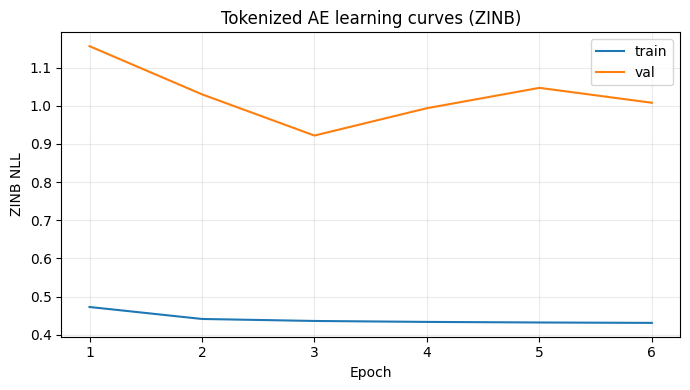

In [127]:
# Train deterministic tokenized autoencoder (ZINB loss)

use_cuda_token = torch.cuda.is_available()
device_token = torch.device("cuda" if use_cuda_token else "cpu")
print(f"Token model device: {device_token}")

train_idx_tok, val_idx_tok, test_idx_tok = stratified_split_indices_by_panel(
    dataset_token,
    train_frac=0.7,
    val_frac=0.15,
    seed=42,
)

train_loader_tok = DataLoader(
    Subset(dataset_token, train_idx_tok),
    batch_size=64,
    shuffle=True,
    collate_fn=collate_gene_tokens,
)
val_loader_tok = DataLoader(
    Subset(dataset_token, val_idx_tok),
    batch_size=64,
    shuffle=False,
    collate_fn=collate_gene_tokens,
)
test_loader_tok = DataLoader(
    Subset(dataset_token, test_idx_tok),
    batch_size=64,
    shuffle=False,
    collate_fn=collate_gene_tokens,
)

print(f"train/val/test cells: {len(train_idx_tok)} / {len(val_idx_tok)} / {len(test_idx_tok)}")
print(f"train/val/test batches: {len(train_loader_tok)} / {len(val_loader_tok)} / {len(test_loader_tok)}")

model_token_ae = GeneTokenAutoencoder(
    n_genes_vocab=len(gene2id),
    n_panels=len(panel2id),
    n_tissues=len(tissue2id),
    d_model=128,
    nhead=4,
    num_layers=3,
    latent_dim=32,
    dropout=0.1,
).to(device_token)

optimizer_tok = torch.optim.Adam(model_token_ae.parameters(), lr=1e-3)

EPOCHS_TOK = 10
PATIENCE_TOK = 3

hist_train_tok = []
hist_val_tok = []
best_val_tok = np.inf
best_state_tok = None
best_epoch_tok = 0
stale = 0

print("Starting token AE training with ZINB loss...")
epoch_bar = tqdm(
    range(1, EPOCHS_TOK + 1),
    desc="Token AE epochs",
    unit="epoch",
    leave=True,
    position=0,
    dynamic_ncols=True,
    mininterval=0.5,
    file=sys.stdout,
)
for epoch in epoch_bar:
    print(f"\n=== Epoch {epoch:02d}/{EPOCHS_TOK} ===")

    tr = run_epoch_token_ae(
        model_token_ae,
        train_loader_tok,
        optimizer_tok,
        device_token,
        train=True,
        epoch_label=f"Epoch {epoch:02d}/{EPOCHS_TOK}",
        log_every=300,
    )
    va = run_epoch_token_ae(
        model_token_ae,
        val_loader_tok,
        optimizer_tok,
        device_token,
        train=False,
        epoch_label=f"Epoch {epoch:02d}/{EPOCHS_TOK}",
        log_every=300,
    )

    hist_train_tok.append(tr)
    hist_val_tok.append(va)

    improved = va < (best_val_tok - 1e-8)
    if improved:
        best_val_tok = va
        best_epoch_tok = epoch
        best_state_tok = {k: v.detach().cpu().clone() for k, v in model_token_ae.state_dict().items()}
        stale = 0
    else:
        stale += 1

    epoch_bar.set_postfix({"train_nll": f"{tr:.5f}", "val_nll": f"{va:.5f}", "best_epoch": best_epoch_tok})
    print(f"Epoch {epoch:02d} | train={tr:.6f} | val={va:.6f}")

    if stale >= PATIENCE_TOK:
        print(f"Early stopping at epoch {epoch}; best epoch={best_epoch_tok}")
        break

epoch_bar.close()

if best_state_tok is None:
    raise RuntimeError("No checkpoint saved for token AE.")

model_token_ae.load_state_dict(best_state_tok)
print(f"Loaded best token AE checkpoint from epoch {best_epoch_tok} (val={best_val_tok:.6f})")
token_ae_ckpt_path = "C:\\Users\\ntpar\\OneDrive\\Desktop\\BEP\\model_paths\\tokenized_ae_21_03_2026.pt"
torch.save({
    "model_state_dict": model_token_ae.state_dict(),
    "best_epoch": int(best_epoch_tok),
    "best_val_zinb_nll": float(best_val_tok),
    "gene_vocab_size": int(len(gene2id)),
    "panel2id": panel2id,
    "tissue2id": tissue2id,
}, token_ae_ckpt_path)
print(f"Saved token AE checkpoint to: {token_ae_ckpt_path}")

# Quick learning curves

ep = np.arange(1, len(hist_train_tok) + 1)
plt.figure(figsize=(7, 4))
plt.plot(ep, hist_train_tok, label="train")
plt.plot(ep, hist_val_tok, label="val")
plt.xlabel("Epoch")
plt.ylabel("ZINB NLL")
plt.title("Tokenized AE learning curves (ZINB)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [130]:
# Stochastic ZINB evaluation for tokenized autoencoder
# Compares deterministic expected output vs sampled ZINB output on held-out tokens.

required = ["model_token_ae", "test_loader_tok", "device_token"]
missing = [k for k in required if k not in globals()]
if missing:
    raise ValueError(f"Missing required variables: {missing}. Run token model training/setup cells first.")

if not hasattr(model_token_ae, "forward_with_params"):
    raise ValueError("Current model_token_ae does not expose `forward_with_params`; run the updated model definition cell.")

model_token_ae.eval()

# Runtime controls for quick vs full evaluation
n_stochastic_samples = 5
max_batches = None  # set to None for full test loader
eps = 1e-8

sum_sq_det_log = 0.0
sum_sq_stoch_log = 0.0
sum_sq_det_count = 0.0
sum_sq_stoch_count = 0.0
sum_det_rate_abs = 0.0
sum_stoch_rate_abs = 0.0
n_tokens = 0
n_genes_seen = 0

with torch.no_grad():
    it = tqdm(test_loader_tok, desc="Token ZINB stochastic eval", unit="batch")
    for b_idx, batch in enumerate(it):
        if max_batches is not None and b_idx >= max_batches:
            break

        gene_ids = batch["gene_ids"].to(device_token)
        x_vals = batch["x_vals"].to(device_token)
        y_counts = batch["y_vals"].to(device_token).clamp_min(0.0)
        attn_mask = batch["attn_mask"].to(device_token)
        panel_id = batch["panel_id"].to(device_token)
        tissue_id = batch["tissue_id"].to(device_token)

        _, _, mu_logit, pi_logit, theta_unconstrained = model_token_ae.forward_with_params(
            gene_ids=gene_ids,
            x_vals=x_vals,
            attn_mask=attn_mask,
            panel_id=panel_id,
            tissue_id=tissue_id,
        )

        mu = F.softplus(mu_logit) + eps
        pi = torch.sigmoid(pi_logit)
        theta = F.softplus(theta_unconstrained) + eps

        # Deterministic expected count for ZINB
        det_counts = (1.0 - pi) * mu

        # Stochastic samples from ZINB: NB via Gamma-Poisson, then zero-inflation mask
        stoch_counts_acc = torch.zeros_like(det_counts)
        stoch_detect_acc = torch.zeros_like(det_counts)
        for _ in range(n_stochastic_samples):
            gamma_rate = theta / (mu + eps)
            gamma_dist = torch.distributions.Gamma(concentration=theta, rate=gamma_rate)
            lam = gamma_dist.sample()
            nb_sample = torch.poisson(lam)
            drop_mask = torch.bernoulli(pi).bool()
            zinb_sample = nb_sample.masked_fill(drop_mask, 0.0)

            stoch_counts_acc += zinb_sample
            stoch_detect_acc += (zinb_sample > 0).float()

        stoch_counts = stoch_counts_acc / float(n_stochastic_samples)
        stoch_detect = stoch_detect_acc / float(n_stochastic_samples)

        valid = attn_mask
        if valid.any():
            y_log = torch.log1p(y_counts)
            det_log = torch.log1p(det_counts)
            stoch_log = torch.log1p(stoch_counts)

            diff_det_log = (det_log - y_log)[valid]
            diff_stoch_log = (stoch_log - y_log)[valid]
            diff_det_count = (det_counts - y_counts)[valid]
            diff_stoch_count = (stoch_counts - y_counts)[valid]

            sum_sq_det_log += float((diff_det_log ** 2).sum().item())
            sum_sq_stoch_log += float((diff_stoch_log ** 2).sum().item())
            sum_sq_det_count += float((diff_det_count ** 2).sum().item())
            sum_sq_stoch_count += float((diff_stoch_count ** 2).sum().item())

            true_detect = (y_counts > 0).float()
            det_detect = (1.0 - (pi + (1.0 - pi) * torch.exp(theta * (torch.log(theta + eps) - torch.log(theta + mu + eps)))))[valid]
            stoch_detect_v = stoch_detect[valid]
            true_detect_v = true_detect[valid]

            sum_det_rate_abs += float((det_detect - true_detect_v).abs().sum().item())
            sum_stoch_rate_abs += float((stoch_detect_v - true_detect_v).abs().sum().item())

            n_tokens += int(valid.sum().item())

        n_genes_seen += int(gene_ids.numel())

if n_tokens == 0:
    raise RuntimeError("No valid tokens found during stochastic evaluation.")

eval_df = pd.DataFrame([
    {"metric": "mse_log1p_deterministic", "value": sum_sq_det_log / n_tokens},
    {"metric": "mse_log1p_stochastic_mean", "value": sum_sq_stoch_log / n_tokens},
    {"metric": "mse_counts_deterministic", "value": sum_sq_det_count / n_tokens},
    {"metric": "mse_counts_stochastic_mean", "value": sum_sq_stoch_count / n_tokens},
    {"metric": "mae_detection_deterministic", "value": sum_det_rate_abs / n_tokens},
    {"metric": "mae_detection_stochastic", "value": sum_stoch_rate_abs / n_tokens},
    {"metric": "n_valid_tokens", "value": float(n_tokens)},
    {"metric": "n_stochastic_samples", "value": float(n_stochastic_samples)},
    {"metric": "batches_evaluated", "value": float(max_batches if max_batches is not None else len(test_loader_tok))},
])

print("Stochastic ZINB token evaluation summary:")
display(eval_df)

Token ZINB stochastic eval: 100%|██████████| 9147/9147 [08:09<00:00, 18.68batch/s]


Token ZINB stochastic eval: 100%|██████████| 9147/9147 [08:09<00:00, 18.68batch/s]


Stochastic ZINB token evaluation summary:


,metric,value
0,mse_log1p_deterministic,5.002324e-01
1,mse_log1p_stochastic_mean,5.142842e-01
2,mse_counts_deterministic,3.893390e+01
3,mse_counts_stochastic_mean,3.899735e+01
4,mae_detection_deterministic,2.397623e-01
5,mae_detection_stochastic,2.397580e-01
6,n_valid_tokens,2.605325e+08
7,n_stochastic_samples,5.000000e+00
8,batches_evaluated,9.147000e+03


In [131]:
# Stochastic tokenizer reconstruction analysis (ZINB) for downsampled target panel -> original target panel

required = ["model_token_ae", "test_loader_tok", "device_token", "id2gene"]
missing = [k for k in required if k not in globals()]
if missing:
    raise ValueError(f"Missing variables/functions: {missing}. Run tokenizer setup/training cells first.")

if not hasattr(model_token_ae, "forward_with_params"):
    raise ValueError("Current model_token_ae does not expose `forward_with_params`; run the updated tokenizer model cell.")

model_token_ae.eval()

# Restrict evaluation to downsampled target-panel inputs vs original target-panel targets.
# Set to the desired panel key from TRAIN_PANELS / panel2id.
target_panel_name = "V1_Ovary"
available_panels = sorted(panel2id.keys()) if "panel2id" in globals() else None
if available_panels is not None and target_panel_name not in available_panels:
    raise ValueError(f"Unknown target_panel_name={target_panel_name}. Available panels: {available_panels}")

# Genes to visualize: keep user-provided names if available, else choose top by target-panel test mean.
if "plot_genes" in globals() and len(plot_genes) > 0:
    genes_for_plot = [str(g) for g in plot_genes]
elif "genes_to_plot" in globals() and len(genes_to_plot) > 0:
    genes_for_plot = [str(g) for g in genes_to_plot]
else:
    genes_for_plot = []

gene_names_vocab = np.asarray(id2gene).astype(str)
gene2id_local = {g: i for i, g in enumerate(gene_names_vocab)}

# Use one stochastic ZINB draw per token for plotting/eval to preserve realistic zero behavior.
n_samples_per_token = 1
max_batches = None  # Set an integer (e.g., 120) for faster debugging runs.
max_points_per_gene = 120000
rng = np.random.default_rng(42)
eps = 1e-8

# Collect per-gene true and sampled reconstructed counts from tokenizer test tokens.
true_by_gene = {g: [] for g in genes_for_plot}
samp_by_gene = {g: [] for g in genes_for_plot}

# If no plot genes were preselected, first pass to compute approximate means on target panel only and pick top genes.
if len(genes_for_plot) == 0:
    mean_sum = {}
    mean_n = {}
    with torch.no_grad():
        for b_idx, batch in enumerate(tqdm(test_loader_tok, desc=f"Tokenizer {target_panel_name} pre-pass", unit="batch")):
            if b_idx >= 60:
                break
            gene_ids = batch["gene_ids"].to(device_token)
            y_counts = batch["y_vals"].to(device_token).clamp_min(0.0)
            attn_mask = batch["attn_mask"].to(device_token)

            for i in range(gene_ids.shape[0]):
                if batch["panel_name"][i] != target_panel_name:
                    continue
                valid_idx = torch.where(attn_mask[i])[0]
                if valid_idx.numel() == 0:
                    continue

                ids_flat = gene_ids[i, valid_idx].detach().cpu().numpy()
                y_flat = y_counts[i, valid_idx].detach().cpu().numpy()
                for gid, yv in zip(ids_flat, y_flat):
                    gname = gene_names_vocab[int(gid)]
                    mean_sum[gname] = mean_sum.get(gname, 0.0) + float(yv)
                    mean_n[gname] = mean_n.get(gname, 0) + 1

    if len(mean_sum) == 0:
        raise RuntimeError(f"No tokens found for panel {target_panel_name} in test_loader_tok.")

    mean_items = [(g, mean_sum[g] / max(mean_n[g], 1)) for g in mean_sum]
    mean_items.sort(key=lambda x: x[1], reverse=True)
    genes_for_plot = [g for g, _ in mean_items[:6]]

    true_by_gene = {g: [] for g in genes_for_plot}
    samp_by_gene = {g: [] for g in genes_for_plot}

wanted_ids = {gene2id_local[g]: g for g in genes_for_plot if g in gene2id_local}
if len(wanted_ids) == 0:
    raise ValueError("No requested genes were found in tokenizer vocabulary.")

n_target_cells_used = 0
with torch.no_grad():
    eval_bar = tqdm(test_loader_tok, desc=f"Tokenizer stochastic gene eval ({target_panel_name})", unit="batch")
    for b_idx, batch in enumerate(eval_bar):
        if max_batches is not None and b_idx >= max_batches:
            break

        gene_ids = batch["gene_ids"].to(device_token)
        x_vals = batch["x_vals"].to(device_token)
        y_counts = batch["y_vals"].to(device_token).clamp_min(0.0)
        attn_mask = batch["attn_mask"].to(device_token)
        panel_id = batch["panel_id"].to(device_token)
        tissue_id = batch["tissue_id"].to(device_token)

        _, _, mu_logit, pi_logit, theta_unconstrained = model_token_ae.forward_with_params(
            gene_ids=gene_ids,
            x_vals=x_vals,
            attn_mask=attn_mask,
            panel_id=panel_id,
            tissue_id=tissue_id,
        )

        mu = F.softplus(mu_logit) + eps
        pi = torch.sigmoid(pi_logit)
        theta = F.softplus(theta_unconstrained) + eps

        # Single stochastic ZINB draw per token (no multi-draw averaging).
        gamma_rate = theta / (mu + eps)
        gamma_dist = torch.distributions.Gamma(concentration=theta, rate=gamma_rate)
        lam = gamma_dist.sample()
        nb_sample = torch.poisson(lam)
        drop_mask = torch.bernoulli(pi).bool()
        stoch_counts = nb_sample.masked_fill(drop_mask, 0.0)

        ids_np = gene_ids.detach().cpu().numpy()
        mask_np = attn_mask.detach().cpu().numpy()
        y_np = y_counts.detach().cpu().numpy()
        s_np = stoch_counts.detach().cpu().numpy()

        for i in range(ids_np.shape[0]):
            if batch["panel_name"][i] != target_panel_name:
                continue
            n_target_cells_used += 1

            valid_idx = np.where(mask_np[i])[0]
            if valid_idx.size == 0:
                continue
            gids = ids_np[i, valid_idx]
            yv = y_np[i, valid_idx]
            sv = s_np[i, valid_idx]

            for gid, yt, st in zip(gids, yv, sv):
                gid = int(gid)
                if gid in wanted_ids:
                    gname = wanted_ids[gid]
                    true_by_gene[gname].append(float(yt))
                    samp_by_gene[gname].append(float(st))

# Downsample collected points for plotting speed
for g in genes_for_plot:
    n_cur = len(true_by_gene[g])
    if n_cur > max_points_per_gene:
        idx = rng.choice(n_cur, size=max_points_per_gene, replace=False)
        true_arr = np.asarray(true_by_gene[g], dtype=np.float32)[idx]
        samp_arr = np.asarray(samp_by_gene[g], dtype=np.float32)[idx]
        true_by_gene[g] = true_arr.tolist()
        samp_by_gene[g] = samp_arr.tolist()

# Compute summary metrics across selected genes
a_true = []
a_samp = []
for g in genes_for_plot:
    if len(true_by_gene[g]) == 0:
        continue
    a_true.append(np.asarray(true_by_gene[g], dtype=np.float32))
    a_samp.append(np.asarray(samp_by_gene[g], dtype=np.float32))

if len(a_true) == 0:
    raise RuntimeError(f"No {target_panel_name} tokens collected for selected genes from tokenizer test loader.")

all_true = np.concatenate(a_true)
all_samp = np.concatenate(a_samp)
summary_tok_stoch = pd.DataFrame([
    {"metric": "mse_counts_selected_genes", "value": float(np.mean((all_samp - all_true) ** 2))},
    {"metric": "mse_log1p_selected_genes", "value": float(np.mean((np.log1p(all_samp) - np.log1p(all_true)) ** 2))},
    {"metric": "mae_detection_selected_genes", "value": float(np.mean(np.abs((all_samp > 0).astype(np.float32) - (all_true > 0).astype(np.float32))))},
    {"metric": "n_total_tokens_used", "value": float(all_true.size)},
    {"metric": "n_target_panel_cells_used", "value": float(n_target_cells_used)},
    {"metric": "n_stochastic_samples_per_token", "value": float(n_samples_per_token)},
])

print(
    f"Tokenizer stochastic reconstruction summary (downsampled {target_panel_name} -> original {target_panel_name}; "
    f"single-draw ZINB sampling per token):"
)
display(summary_tok_stoch)

# Plot distributions: all tokens and >0 only, analogous to earlier VAE diagnostics.
n_rows = len(genes_for_plot)
fig, axs = plt.subplots(n_rows, 2, figsize=(12, 3.1 * n_rows), squeeze=False)

rows = []
for i, g in enumerate(genes_for_plot):
    x_true = np.asarray(true_by_gene[g], dtype=np.float32)
    x_samp = np.asarray(samp_by_gene[g], dtype=np.float32)

    if x_true.size == 0 or x_samp.size == 0:
        continue

    xt_all = np.log1p(np.clip(x_true, 0.0, None))
    xs_all = np.log1p(np.clip(x_samp, 0.0, None))
    xt_pos = xt_all[x_true > 0]
    xs_pos = xs_all[x_samp > 0]

    axL = axs[i, 0]
    axL.hist(xs_all, bins=30, density=True, alpha=0.4, label=f"Tokenizer ZINB sampled draw (n={len(xs_all)})")
    axL.hist(xt_all, bins=30, density=True, alpha=0.4, label=f"Original {target_panel_name} target (n={len(xt_all)})")
    axL.set_title(f"{g} | all tokens")
    axL.legend(frameon=True)

    axR = axs[i, 1]
    if xs_pos.size > 0:
        axR.hist(xs_pos, bins=30, density=True, alpha=0.4, label=f"Tokenizer ZINB sampled draw >0 (n={len(xs_pos)})")
    if xt_pos.size > 0:
        axR.hist(xt_pos, bins=30, density=True, alpha=0.4, label=f"Original {target_panel_name} >0 (n={len(xt_pos)})")
    axR.set_title(f"{g} | >0 only")
    axR.legend(frameon=True)

    rows.append({
        "gene": g,
        "mean_sampled": float(x_samp.mean()),
        "mean_target": float(x_true.mean()),
        "detect_pct_sampled": float(100.0 * (x_samp > 0).mean()),
        "detect_pct_target": float(100.0 * (x_true > 0).mean()),
    })

fig.suptitle(f"Tokenizer per-gene distributions: log1p (stochastic ZINB single draw, {target_panel_name})", y=1.002)
plt.tight_layout()
plt.show()

print("Per-gene summary (sampled tokenizer draw vs target):")
display(pd.DataFrame(rows))

Tokenizer stochastic gene eval (V1_Ovary):   0%|          | 0/9147 [00:00<?, ?batch/s]

Tokenizer stochastic gene eval (V1_Ovary):   0%|          | 0/9147 [00:00<?, ?batch/s]

Tokenizer stochastic gene eval (V1_Ovary):   3%|▎         | 290/9147 [00:10<05:28, 26.97batch/s]


Tokenizer stochastic gene eval (V1_Ovary):   0%|          | 0/9147 [00:00<?, ?batch/s]

Tokenizer stochastic gene eval (V1_Ovary):   3%|▎         | 290/9147 [00:10<05:28, 26.97batch/s]


KeyboardInterrupt: 

In [132]:
# Split + DataLoaders + training/eval helper functions


def stratified_split_indices_by_panel(dataset, train_frac=0.7, val_frac=0.15, seed=42):
    """
    Prefer sample-group split (if available) to avoid leakage.
    Fallback to panel-stratified split if sample groups are not usable.
    """
    if train_frac <= 0 or val_frac <= 0 or (train_frac + val_frac) >= 1:
        raise ValueError("Use train_frac > 0, val_frac > 0, and train_frac + val_frac < 1.")

    rng = np.random.default_rng(seed)

    # 1) Try sample-group split first (split key only, never used as model input).
    sample_groups = np.array([r.get("sample_group", "") for r in dataset.rows], dtype=object)
    has_sample_groups = np.all(sample_groups != "")
    if has_sample_groups:
        unique_groups = np.unique(sample_groups)
        if unique_groups.size >= 3:
            group_indices = {g: np.where(sample_groups == g)[0] for g in unique_groups}
            groups = np.array(list(group_indices.keys()), dtype=object)
            rng.shuffle(groups)

            n_total = len(dataset.rows)
            target_train = train_frac * n_total
            target_val = val_frac * n_total
            counts = {"train": 0, "val": 0, "test": 0}
            assign = {}

            for g in groups:
                g_size = int(group_indices[g].size)
                train_deficit = target_train - counts["train"]
                val_deficit = target_val - counts["val"]

                if train_deficit >= val_deficit and train_deficit > 0:
                    split_name = "train"
                elif val_deficit > 0:
                    split_name = "val"
                else:
                    split_name = "test"

                assign[g] = split_name
                counts[split_name] += g_size

            train_idx, val_idx, test_idx = [], [], []
            for g, split_name in assign.items():
                idx = group_indices[g].tolist()
                if split_name == "train":
                    train_idx.extend(idx)
                elif split_name == "val":
                    val_idx.extend(idx)
                else:
                    test_idx.extend(idx)

            if min(len(train_idx), len(val_idx), len(test_idx)) > 0:
                rng.shuffle(train_idx)
                rng.shuffle(val_idx)
                rng.shuffle(test_idx)
                print(f"Split mode: sample-group ({unique_groups.size} groups)")
                return np.array(train_idx), np.array(val_idx), np.array(test_idx)

    # 2) Fallback: panel-stratified split
    panel_ids = np.array([r["panel_id"] for r in dataset.rows], dtype=np.int64)
    train_idx, val_idx, test_idx = [], [], []
    for pid in np.unique(panel_ids):
        idx = np.where(panel_ids == pid)[0]
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(train_frac * n)
        n_val = int(val_frac * n)
        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)
    print("Split mode: panel-stratified fallback")
    return np.array(train_idx), np.array(val_idx), np.array(test_idx)


def run_epoch_token_ae(model, loader, optimizer, device, train=True, epoch_label="", log_every=200):
    model.train() if train else model.eval()

    loss_sum = 0.0
    n_batches = 0
    stage = "train" if train else "val"
    total_batches = len(loader)
    t0 = time.time()

    print(f"{epoch_label} [{stage}] starting | batches={total_batches}")

    # Keep a simple, single-line bar to avoid nested tqdm rendering issues in VS Code.
    iter_loader = tqdm(
        loader,
        desc=f"{epoch_label} [{stage}]",
        unit="batch",
        leave=True,
        position=0,
        dynamic_ncols=True,
        mininterval=0.5,
        file=sys.stdout,
    )

    for batch in iter_loader:
        batch_t0 = time.time()
        gene_ids = batch["gene_ids"].to(device)
        x_vals = batch["x_vals"].to(device)
        y_vals = batch["y_vals"].to(device)
        attn_mask = batch["attn_mask"].to(device)
        panel_id = batch["panel_id"].to(device)
        tissue_id = batch["tissue_id"].to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            _, _, mu_logit, pi_logit, theta_unconstrained = model.forward_with_params(
                gene_ids=gene_ids,
                x_vals=x_vals,
                attn_mask=attn_mask,
                panel_id=panel_id,
                tissue_id=tissue_id,
            )
            loss = token_zinb_loss(mu_logit, pi_logit, theta_unconstrained, y_vals, attn_mask)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        loss_sum += float(loss.item())
        n_batches += 1

        if n_batches == 1:
            print(f"{epoch_label} [{stage}] first batch done in {time.time() - batch_t0:.1f}s")

        if n_batches % log_every == 0 or n_batches == total_batches:
            avg_loss = loss_sum / n_batches
            elapsed = time.time() - t0
            print(
                f"{epoch_label} [{stage}] {n_batches}/{total_batches} "
                f"avg_zinb_nll={avg_loss:.5f} elapsed={elapsed/60:.1f}m"
            )
            iter_loader.set_postfix({"zinb_nll": f"{avg_loss:.5f}"})

    return loss_sum / max(n_batches, 1)


def collect_eval_rows(model, loader, device):
    model.eval()
    rows = []

    with torch.no_grad():
        for batch in tqdm(
            loader,
            desc="Token AE eval",
            unit="batch",
            leave=True,
            position=0,
            dynamic_ncols=True,
            mininterval=0.5,
            file=sys.stdout,
        ):
            gene_ids = batch["gene_ids"].to(device)
            x_vals = batch["x_vals"].to(device)
            y_vals = batch["y_vals"].to(device)
            attn_mask = batch["attn_mask"].to(device)
            shared_mask = batch["shared_mask"].to(device)
            panel_id = batch["panel_id"].to(device)
            tissue_id = batch["tissue_id"].to(device)

            recon_log1p, _, mu_logit, pi_logit, theta_unconstrained = model.forward_with_params(
                gene_ids=gene_ids,
                x_vals=x_vals,
                attn_mask=attn_mask,
                panel_id=panel_id,
                tissue_id=tissue_id,
            )

            diff2 = (recon_log1p - y_vals) ** 2
            zinb_nll_tok = token_zinb_loss(mu_logit, pi_logit, theta_unconstrained, y_vals, attn_mask)

            for i in range(recon_log1p.shape[0]):
                valid = attn_mask[i]
                shared = valid & shared_mask[i]
                specific = valid & (~shared_mask[i])

                row = {
                    "panel_name": batch["panel_name"][i],
                    "tissue_name": batch["tissue_name"][i],
                    "mse_all": float(diff2[i][valid].mean().item()) if valid.any() else np.nan,
                    "mse_shared": float(diff2[i][shared].mean().item()) if shared.any() else np.nan,
                    "mse_specific": float(diff2[i][specific].mean().item()) if specific.any() else np.nan,
                    "zinb_nll_batch": float(zinb_nll_tok.item()),
                    "n_tokens": int(valid.sum().item()),
                    "n_shared_tokens": int(shared.sum().item()),
                    "n_specific_tokens": int(specific.sum().item()),
                }
                rows.append(row)

    return pd.DataFrame(rows)

In [133]:
# Evaluate tokenized AE: pooled, panel-wise, tissue-wise, same-vs-cross tissue, shared-vs-specific

# Aggregate train tissue profile in latent space
model_token_ae.eval()
train_latents = []
train_tissues = []

with torch.no_grad():
    for batch in train_loader_tok:
        z = model_token_ae.encode(
            gene_ids=batch["gene_ids"].to(device_token),
            x_vals=batch["x_vals"].to(device_token),
            attn_mask=batch["attn_mask"].to(device_token),
            panel_id=batch["panel_id"].to(device_token),
            tissue_id=batch["tissue_id"].to(device_token),
        )
        train_latents.append(z.cpu().numpy())
        train_tissues.extend(batch["tissue_name"])

train_latents = np.concatenate(train_latents, axis=0)
train_tissues = np.array(train_tissues, dtype=object)
train_centroids = {
    t: train_latents[train_tissues == t].mean(axis=0)
    for t in sorted(set(train_tissues.tolist()))
}

# Test-set per-cell metrics
df_test = collect_eval_rows(model_token_ae, test_loader_tok, device_token)
if df_test.empty:
    raise RuntimeError("Token AE test evaluation produced no rows.")

print("Pooled MSE:")
pooled = pd.DataFrame([
    {
        "split": "test",
        "mse_all": float(df_test["mse_all"].mean()),
        "mse_shared": float(df_test["mse_shared"].dropna().mean()),
        "mse_specific": float(df_test["mse_specific"].dropna().mean()),
    }
])
display(pooled)

print("Per-panel MSE:")
per_panel = (
    df_test.groupby("panel_name", as_index=False)
    .agg(
        mse_all=("mse_all", "mean"),
        mse_shared=("mse_shared", "mean"),
        mse_specific=("mse_specific", "mean"),
        n_cells=("mse_all", "size"),
    )
    .sort_values("mse_all")
)
display(per_panel)

print("Per-tissue MSE:")
per_tissue = (
    df_test.groupby("tissue_name", as_index=False)
    .agg(
        mse_all=("mse_all", "mean"),
        mse_shared=("mse_shared", "mean"),
        mse_specific=("mse_specific", "mean"),
        n_cells=("mse_all", "size"),
    )
    .sort_values("mse_all")
)
display(per_tissue)

# Same-tissue vs cross-tissue transfer proxy
# For each test cell latent z, assign nearest train tissue centroid and compare with true tissue.
same_cross_rows = []
with torch.no_grad():
    for batch in test_loader_tok:
        z = model_token_ae.encode(
            gene_ids=batch["gene_ids"].to(device_token),
            x_vals=batch["x_vals"].to(device_token),
            attn_mask=batch["attn_mask"].to(device_token),
            panel_id=batch["panel_id"].to(device_token),
            tissue_id=batch["tissue_id"].to(device_token),
        ).cpu().numpy()

        recon, _ = model_token_ae(
            gene_ids=batch["gene_ids"].to(device_token),
            x_vals=batch["x_vals"].to(device_token),
            attn_mask=batch["attn_mask"].to(device_token),
            panel_id=batch["panel_id"].to(device_token),
            tissue_id=batch["tissue_id"].to(device_token),
        )
        diff2 = (recon - batch["y_vals"].to(device_token)) ** 2

        for i in range(z.shape[0]):
            dists = {t: np.sum((z[i] - c) ** 2) for t, c in train_centroids.items()}
            nearest_tissue = min(dists, key=dists.get)
            true_tissue = batch["tissue_name"][i]
            same_tissue = (nearest_tissue == true_tissue)

            valid = batch["attn_mask"][i].to(device_token)
            mse_i = float(diff2[i][valid].mean().item())
            same_cross_rows.append({"same_tissue": same_tissue, "mse_all": mse_i})

same_cross_df = pd.DataFrame(same_cross_rows)
transfer_summary = (
    same_cross_df.groupby("same_tissue", as_index=False)
    .agg(mse_all=("mse_all", "mean"), n_cells=("mse_all", "size"))
)
transfer_summary["group"] = transfer_summary["same_tissue"].map({True: "same_tissue", False: "cross_tissue"})
transfer_summary = transfer_summary[["group", "mse_all", "n_cells"]].sort_values("group")

print("Same-tissue vs cross-tissue transfer proxy:")
display(transfer_summary)

# Compact scoreboard
scoreboard_token = pd.concat(
    [
        pooled.assign(scope="pooled").rename(columns={"split": "name"}),
        per_panel.assign(scope="panel").rename(columns={"panel_name": "name"}),
        per_tissue.assign(scope="tissue").rename(columns={"tissue_name": "name"}),
    ],
    ignore_index=True,
)
print("Tokenized AE scoreboard:")
display(scoreboard_token)

KeyboardInterrupt: 

Reconstruction mode: stochastic ZINB sample; fraction exact zeros=87.58%
Common genes (V1 vs reconstructed 5K): 196
Genes plotted: ['MUC1', 'EPCAM', 'CLDN5', 'ADAMTS1']
Per-gene summary (mean counts + detection %):
   gene  mean_first  mean_second  detect_pct_first  detect_pct_second
   MUC1      6.0952       2.6999           44.2745            31.8129
  EPCAM      5.8802       2.9152           47.2010            34.9693
  CLDN5      0.0911       0.1004            6.2963             6.8747
ADAMTS1      0.5927       1.3296           18.2951            25.8829


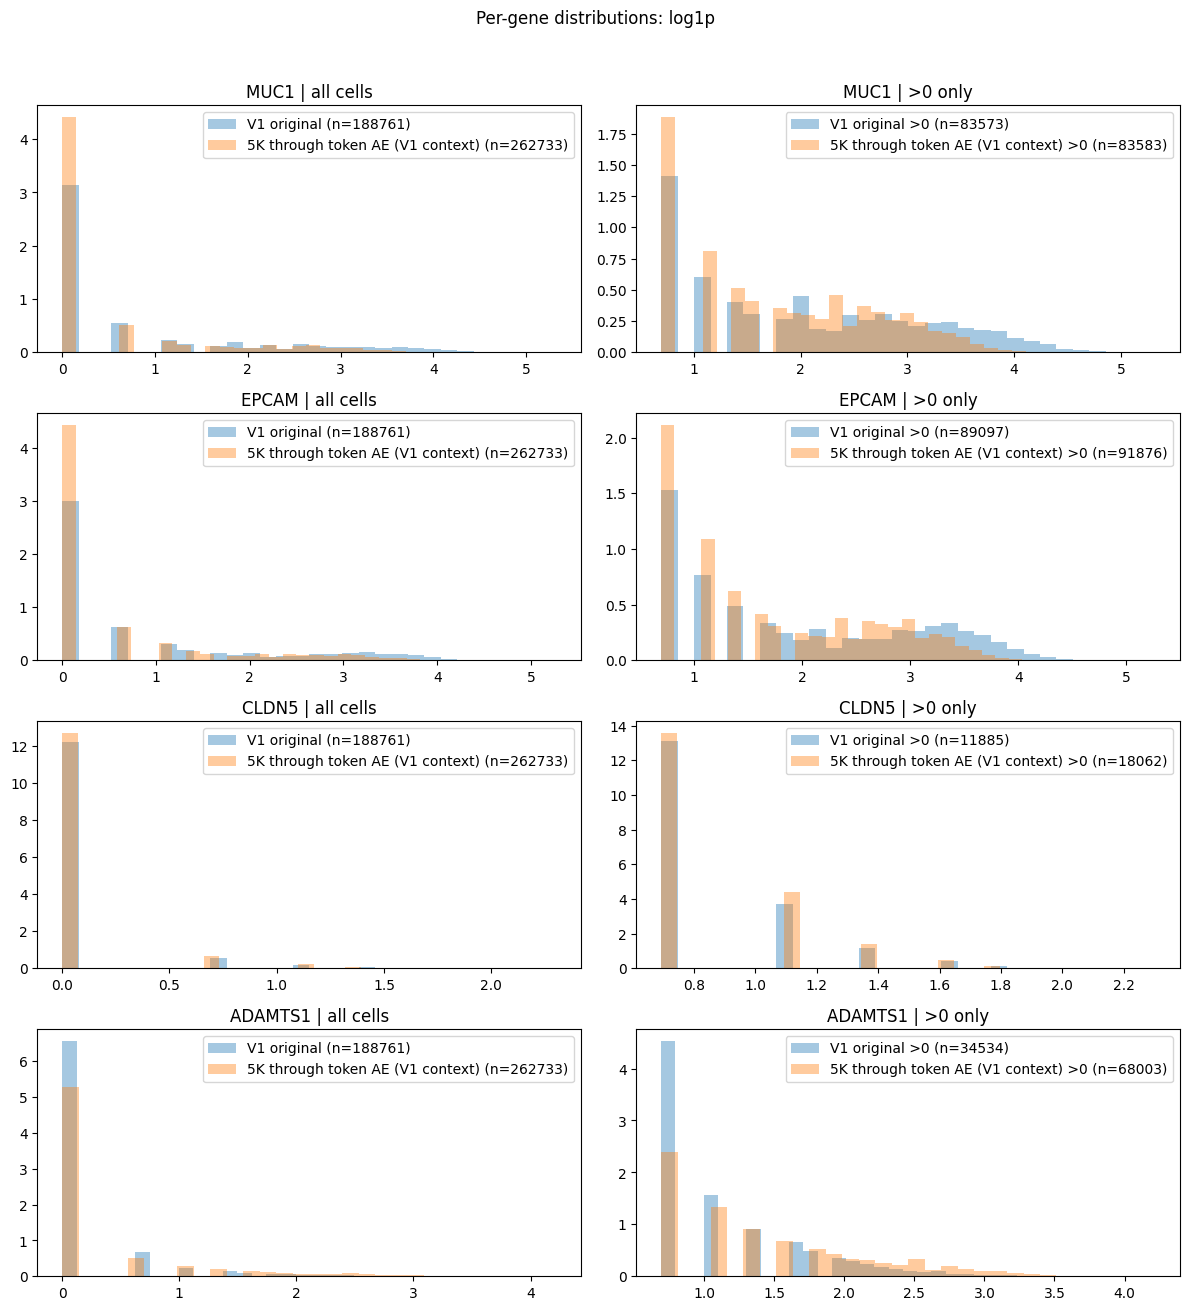

In [140]:
# Compare original V1 (lung) vs reconstructed 5K through token AE

required = [
    "model_token_ae", "device_token", "gene2id", "panel2id", "tissue2id",
    "PANEL_TO_TISSUE", "adatas", "plot_gene_hist_grid"
]
missing = [k for k in required if k not in globals()]
if missing:
    raise ValueError(f"Missing required variables: {missing}. Run the token AE setup/training cells first.")


def reconstruct_panel_with_token_ae(adata_panel, context_panel_name="V1", batch_size=64, restrict_genes=None):
    """
    Reconstruct a panel through the trained token AE.
    Uses context panel/tissue IDs only for conditioning embeddings.
    Optionally reconstructs only a subset of genes to reduce memory use.
    """
    if context_panel_name not in panel2id:
        raise ValueError(f"context_panel_name='{context_panel_name}' not found in panel2id: {list(panel2id.keys())}")

    context_tissue_name = PANEL_TO_TISSUE.get(context_panel_name)
    if context_tissue_name is None or context_tissue_name not in tissue2id:
        context_tissue_name = list(tissue2id.keys())[0]

    panel_genes = pd.Index(adata_panel.var_names.astype(str))
    vocab_genes = pd.Index(gene2id.keys())
    keep_genes = panel_genes.intersection(vocab_genes)
    if restrict_genes is not None:
        keep_genes = keep_genes.intersection(pd.Index(restrict_genes).astype(str))
    if len(keep_genes) == 0:
        raise ValueError("No genes from this panel are present in token model vocabulary after filtering.")

    X_view = adata_panel[:, keep_genes].X
    n_cells = adata_panel.n_obs
    n_genes_keep = len(keep_genes)

    gene_ids_np = np.array([gene2id[g] for g in keep_genes], dtype=np.int64)
    panel_id_val = int(panel2id[context_panel_name])
    tissue_id_val = int(tissue2id[context_tissue_name])

    model_token_ae.eval()
    recon_counts = np.empty((n_cells, n_genes_keep), dtype=np.float32)
    eps = 1e-8
    use_zinb_sampling = hasattr(model_token_ae, "forward_with_params")
    zero_count = 0

    with torch.no_grad():
        for s in range(0, n_cells, batch_size):
            e = min(s + batch_size, n_cells)
            xb_raw = X_view[s:e]
            if sp.issparse(xb_raw):
                xb_np = xb_raw.toarray().astype(np.float32, copy=False)
            else:
                xb_np = np.asarray(xb_raw, dtype=np.float32)

            np.clip(xb_np, 0.0, None, out=xb_np)
            xb_log = np.log1p(xb_np).astype(np.float32, copy=False)

            xb = torch.from_numpy(xb_log).to(device_token)
            b = xb.shape[0]
            l = xb.shape[1]

            gene_ids = torch.from_numpy(np.broadcast_to(gene_ids_np, (b, l))).to(device_token)
            attn_mask = torch.ones((b, l), dtype=torch.bool, device=device_token)
            panel_id = torch.full((b,), panel_id_val, dtype=torch.long, device=device_token)
            tissue_id = torch.full((b,), tissue_id_val, dtype=torch.long, device=device_token)

            if use_zinb_sampling:
                _, _, mu_logit, pi_logit, theta_unconstrained = model_token_ae.forward_with_params(
                    gene_ids=gene_ids,
                    x_vals=xb,
                    attn_mask=attn_mask,
                    panel_id=panel_id,
                    tissue_id=tissue_id,
                )
                mu = torch.nn.functional.softplus(mu_logit) + eps
                pi = torch.sigmoid(pi_logit)
                theta = torch.nn.functional.softplus(theta_unconstrained) + eps

                gamma_rate = theta / (mu + eps)
                gamma_dist = torch.distributions.Gamma(concentration=theta, rate=gamma_rate)
                lam = gamma_dist.sample()
                nb_sample = torch.poisson(lam)
                drop_mask = torch.bernoulli(pi).bool()
                recon_counts_batch = nb_sample.masked_fill(drop_mask, 0.0).cpu().numpy().astype(np.float32, copy=False)
            else:
                recon_log, _ = model_token_ae(
                    gene_ids=gene_ids,
                    x_vals=xb,
                    attn_mask=attn_mask,
                    panel_id=panel_id,
                    tissue_id=tissue_id,
                )
                recon_counts_batch = np.expm1(recon_log.cpu().numpy())
                recon_counts_batch = np.clip(recon_counts_batch, 0.0, None).astype(np.float32, copy=False)

            recon_counts[s:e] = recon_counts_batch
            zero_count += int((recon_counts_batch == 0.0).sum())

    frac_zero = zero_count / float(recon_counts.size)
    mode_label = "stochastic ZINB sample" if use_zinb_sampling else "deterministic decode"
    print(f"Reconstruction mode: {mode_label}; fraction exact zeros={100.0 * frac_zero:.2f}%")

    adata_recon = type(adata_panel)(
        X=recon_counts,
        obs=adata_panel.obs.copy(),
        var=pd.DataFrame(index=keep_genes.copy()),
    )
    return adata_recon


# Set source/target panels for cross-panel evaluation.
source_panel_name = "5K"
target_panel_name = "V1"
context_panel_name = "V1"

if source_panel_name not in adatas:
    raise ValueError(f"Source panel '{source_panel_name}' not found in adatas. Available: {sorted(adatas.keys())}")
if target_panel_name not in adatas:
    raise ValueError(f"Target panel '{target_panel_name}' not found in adatas. Available: {sorted(adatas.keys())}")

adata_src = adatas[source_panel_name]
adata_tgt = adatas[target_panel_name]

# Reconstruct only genes relevant to target-panel comparison to reduce memory pressure.
requested_genes = pd.Index(adata_tgt.var_names.astype(str)).intersection(pd.Index(gene2id.keys()))
if len(requested_genes) == 0:
    raise ValueError("No overlap between target-panel genes and token vocabulary.")

adata_src_recon = reconstruct_panel_with_token_ae(
    adata_panel=adata_src,
    context_panel_name=context_panel_name,
    batch_size=64,
    restrict_genes=requested_genes,
)

# Align genes for plotting against original target panel.
common_genes = pd.Index(adata_tgt.var_names.astype(str)).intersection(pd.Index(adata_src_recon.var_names.astype(str)))
if len(common_genes) == 0:
    raise ValueError(f"No common genes between original {target_panel_name} and reconstructed {source_panel_name} panel.")

adata_tgt_common = adata_tgt[:, common_genes].copy()
adata_src_recon_common = adata_src_recon[:, common_genes].copy()

# Use requested genes if available; otherwise pick top genes by target-panel mean expression.
if "plot_genes" in globals() and len(plot_genes) > 0:
    genes_for_plot = [g for g in plot_genes if g in common_genes]
else:
    genes_for_plot = []

if len(genes_for_plot) == 0:
    x_tgt = _to_dense_float32(adata_tgt_common.X)
    mean_tgt = x_tgt.mean(axis=0)
    top_idx = np.argsort(-mean_tgt)[:6]
    genes_for_plot = adata_tgt_common.var_names[top_idx].astype(str).tolist()

print(f"Common genes ({target_panel_name} vs reconstructed {source_panel_name}): {len(common_genes)}")
print(f"Genes plotted: {genes_for_plot}")

plot_gene_hist_grid(
    adata_tgt_common,
    adata_src_recon_common,
    genes_for_plot,
    bins=30,
    density=True,
    first_label=f"{target_panel_name} original",
    second_label=f"{source_panel_name} through token AE ({context_panel_name} context)",
)


Per-gene summary (mean counts + detection %):
   gene  mean_first  mean_second  detect_pct_first  detect_pct_second
   MUC1      0.7094       6.0952           18.5485            44.2745
  EPCAM      1.4371       5.8802           24.0819            47.2010
  CLDN5      0.2131       0.0911           10.4376             6.2963
ADAMTS1      0.6847       0.5927           18.9942            18.2951


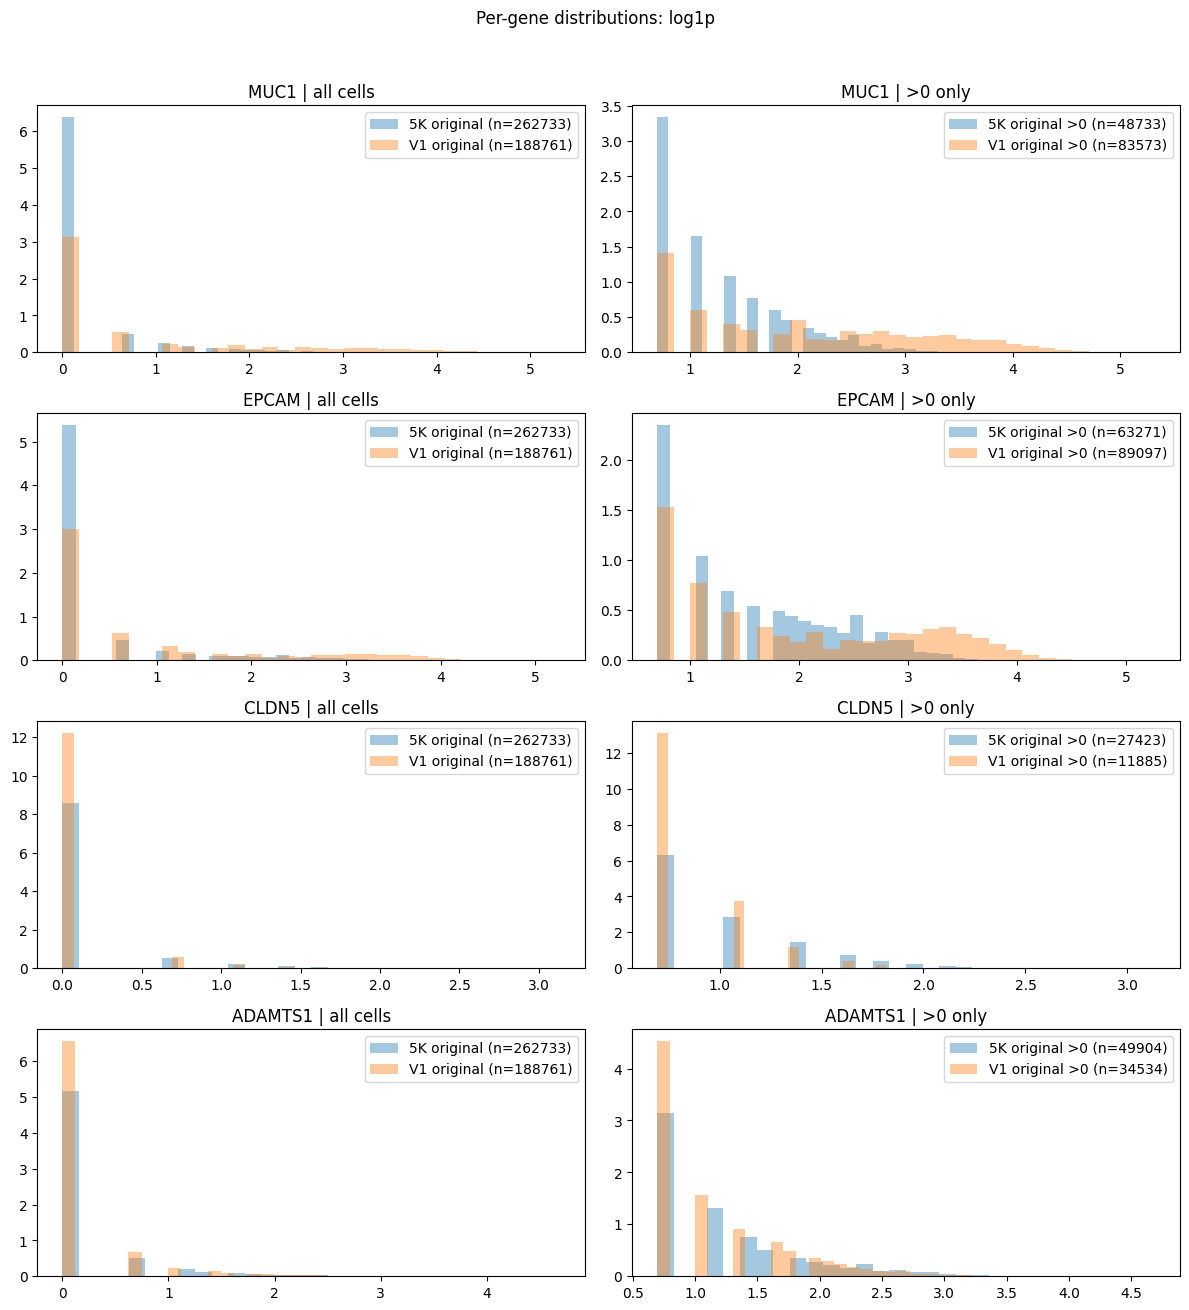

In [137]:
plot_gene_hist_grid(
    adatas['5K'],
    adatas['V1'],
    genes_for_plot,
    bins=30,
    density=True,
    first_label=f"5K original",
    second_label=f"V1 original",
)

In [ ]:
# Reuse transformer/token-AE reconstruction already built above:
# - adata_tgt_common: V1 on common genes
# - adata_src_recon_common: reconstructed 5K through transformer AE on same genes
required = ["adata_tgt_common", "adata_src_recon_common", "plot_exact_scatter_with_fit"]
missing = [k for k in required if k not in globals()]
if missing:
    raise ValueError(
        f"Missing required variables: {missing}. Run Cell 80 first (the transformer reconstruction cell)."
    )

common_genes_all = pd.Index(adata_tgt_common.var_names.astype(str)).intersection(
    pd.Index(adata_src_recon_common.var_names.astype(str))
)
if len(common_genes_all) == 0:
    raise ValueError("No common genes between adata_tgt_common and adata_src_recon_common.")

av = adata_tgt_common[:, common_genes_all]
ar = adata_src_recon_common[:, common_genes_all]

xv = _to_dense_float32(av.X) if "_to_dense_float32" in globals() else np.asarray(av.X, dtype=np.float32)
xr = _to_dense_float32(ar.X) if "_to_dense_float32" in globals() else np.asarray(ar.X, dtype=np.float32)

# Gene-level summaries
mean_v1 = xv.mean(axis=0)
mean_recon = xr.mean(axis=0)
det_v1 = (xv > 0).mean(axis=0)
det_recon = (xr > 0).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_exact_scatter_with_fit(
    x=mean_v1,
    y=mean_recon,
    title="Gene mean: reconstructed 5K (transformer AE) vs V1",
    x_label="V1 gene mean",
    y_label="Reconstructed 5K gene mean",
    color="#E68613",
    ax=axes[0],
)
plot_exact_scatter_with_fit(
    x=det_v1,
    y=det_recon,
    title="Detection: reconstructed 5K (transformer AE) vs V1",
    x_label="V1 detection rate",
    y_label="Reconstructed 5K detection rate",
    color="#E68613",
    ax=axes[1],
)

fig.suptitle(f"V1 vs reconstructed 5K through transformer AE (n_genes={len(common_genes_all)})", y=1.02)
plt.tight_layout()
plt.show()